# Transformer-LSTM Credit Rating Baseline

Notebook su dung **Transformer-LSTM thuan** de du bao credit rating theo row-level protocol.

## Contract chinh
- Doc input tu Kaggle/local split `train.csv`, `val.csv`, `test.csv`.
- Giu row-level `row_id` de doi chieu voi `test.csv` va cac artifact downstream.
- Kien truc chi gom Transformer temporal block, LSTM mot chieu, entity embeddings va classification head.
- Khong them bien the kien truc phu hoac huan luyen nhieu thanh vien trong notebook nay.
- Trinh bay xAI theo 3 lop: global SHAP, local "Why this class?", va LIME local consistency tren feature tai chinh.
- Xuat `tlstm_val_predictions.csv` va `tlstm_test_predictions.csv` theo contract DMF/DCS: `row_id`, true/pred label, confidence, va `prob_*`.
- Luu metrics, probability va explainability artifacts vao `/kaggle/working/credit_rating_artifacts` hoac fallback local.


# Transformer-LSTM Credit Rating

Notebook nay giu workflow Transformer-LSTM thuan co the chay tren Kaggle va local.

- Nguon du lieu mac dinh: `/kaggle/input/credit-rating-dataset/test/{train,val,test}.csv` tren Kaggle, fallback `data/processed/test/` khi chay local.
- Dau ra mac dinh: `/kaggle/working/credit_rating_artifacts` tren Kaggle, fallback `artifacts/TLSTM/` khi chay local.
- Protocol danh gia chinh: row-level `test.csv`, khong tron train/val/test trong qua trinh fit scaler, encoder, sampler, hoac threshold calibration.


In [1]:
# ── Shared two-tier loss, calibration, and probability metrics ──────────────
# Inlined from src/models/losses.py for standalone execution (e.g. Kaggle).
# The benchmark protocol uses plain multiclass negative log-likelihood (NLL).
# The ordinal ablation adds a normalized squared CDF distance (EMD) without
# changing the model output shape or using CORAL/CORN.

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Iterable

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.optimize import minimize_scalar
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize

BENCHMARK_PROTOCOL = "benchmark_ce"
ORDINAL_PROTOCOL = "ordinal_ce_emd"
SUPPORTED_PROTOCOLS = (BENCHMARK_PROTOCOL, ORDINAL_PROTOCOL)
DEFAULT_ORDINAL_LAMBDA = 0.10
DEFAULT_LABEL_ORDER = ("Distressed", "HY", "IG")
_EPS = 1e-12

# Papermill-injectable parameters.
LOSS_PROTOCOL = str(globals().get("LOSS_PROTOCOL", "benchmark_ce")).strip().lower()
ORDINAL_LAMBDA = float(globals().get("ORDINAL_LAMBDA", 0.10))
TARGET_ORDERED_LABELS = ["Distressed", "HY", "IG"]


def normalize_protocol(protocol: str) -> str:
    """Validate and normalize a two-tier loss protocol name."""
    normalized = str(protocol).strip().lower()
    if normalized not in SUPPORTED_PROTOCOLS:
        raise ValueError(
            f"Unsupported loss protocol {protocol!r}; expected one of "
            f"{SUPPORTED_PROTOCOLS}."
        )
    return normalized


def _normalize_probabilities(probabilities: Any) -> np.ndarray:
    probs = np.asarray(probabilities, dtype=np.float64)
    if probs.ndim != 2 or probs.shape[1] < 2:
        raise ValueError("probabilities must have shape (n_samples, n_classes>=2)")
    if not np.isfinite(probs).all():
        raise ValueError("probabilities contain NaN or infinite values")
    probs = np.clip(probs, _EPS, None)
    row_sums = probs.sum(axis=1, keepdims=True)
    if np.any(row_sums <= 0.0):
        raise ValueError("each probability row must have a positive sum")
    return probs / row_sums


def _validate_targets(targets: Any, n_samples: int, n_classes: int) -> np.ndarray:
    y_true = np.asarray(targets, dtype=np.int64).reshape(-1)
    if len(y_true) != n_samples:
        raise ValueError("targets length does not match probabilities")
    if np.any((y_true < 0) | (y_true >= n_classes)):
        raise ValueError("targets contain class ids outside the probability columns")
    return y_true


def numpy_nll(probabilities: Any, targets: Any) -> float:
    """Mean multiclass negative log-likelihood from probabilities."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    return float(-np.log(probs[np.arange(len(y_true)), y_true]).mean())


def numpy_cdf_emd2(probabilities: Any, targets: Any) -> float:
    """Normalized squared CDF distance for ordered multiclass probabilities."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    target_one_hot = np.eye(probs.shape[1], dtype=np.float64)[y_true]
    predicted_cdf = np.cumsum(probs, axis=1)[:, :-1]
    target_cdf = np.cumsum(target_one_hot, axis=1)[:, :-1]
    return float(np.square(predicted_cdf - target_cdf).mean())


def numpy_objective(
    probabilities: Any,
    targets: Any,
    *,
    protocol: str = BENCHMARK_PROTOCOL,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
) -> float:
    """Evaluate the selected two-tier objective from class probabilities."""
    protocol = normalize_protocol(protocol)
    nll = numpy_nll(probabilities, targets)
    if protocol == BENCHMARK_PROTOCOL:
        return nll
    return nll + float(ordinal_lambda) * numpy_cdf_emd2(probabilities, targets)


def benchmark_ce(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Plain multiclass CE used by the primary benchmark."""
    return F.cross_entropy(logits.float(), targets.long(), label_smoothing=0.0)


def cdf_emd2(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Differentiable normalized squared CDF distance from logits."""
    logits = logits.float()
    targets = targets.long()
    probabilities = torch.softmax(logits, dim=1)
    target_one_hot = F.one_hot(
        targets,
        num_classes=probabilities.shape[1],
    ).to(dtype=probabilities.dtype)
    predicted_cdf = probabilities.cumsum(dim=1)[:, :-1]
    target_cdf = target_one_hot.cumsum(dim=1)[:, :-1]
    return (predicted_cdf - target_cdf).square().mean()


def ordinal_ce_emd(
    logits: torch.Tensor,
    targets: torch.Tensor,
    *,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
) -> torch.Tensor:
    """CE plus normalized squared CDF-EMD for the ordinal ablation."""
    return benchmark_ce(logits, targets) + float(ordinal_lambda) * cdf_emd2(
        logits,
        targets,
    )


class TwoTierClassificationLoss(nn.Module):
    """Single loss API shared by all neural notebook baselines."""

    def __init__(
        self,
        protocol: str = BENCHMARK_PROTOCOL,
        ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
    ) -> None:
        super().__init__()
        self.protocol = normalize_protocol(protocol)
        self.ordinal_lambda = float(ordinal_lambda)
        if self.ordinal_lambda < 0.0:
            raise ValueError("ordinal_lambda must be non-negative")

    def monitor_loss(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:
        """Always return comparable plain NLL for curves and reports."""
        return benchmark_ce(logits, targets)

    def loss_parts(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
        **_: Any,
    ) -> dict[str, torch.Tensor]:
        nll = benchmark_ce(logits, targets)
        emd = cdf_emd2(logits, targets)
        objective = (
            nll
            if self.protocol == BENCHMARK_PROTOCOL
            else nll + self.ordinal_lambda * emd
        )
        return {
            "objective": objective,
            "nll": nll,
            "cdf_emd2": emd,
            # Compatibility aliases for existing notebook training loops.
            "ce_loss": nll,
            "aux_loss": objective - nll,
        }

    def forward(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
        **_: Any,
    ) -> torch.Tensor:
        return self.loss_parts(logits, targets)["objective"]


def build_loss(
    protocol: str = BENCHMARK_PROTOCOL,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
) -> TwoTierClassificationLoss:
    """Factory used by notebook import and fallback paths."""
    return TwoTierClassificationLoss(
        protocol=protocol,
        ordinal_lambda=ordinal_lambda,
    )


def apply_temperature(probabilities: Any, temperature: float) -> np.ndarray:
    """Apply scalar temperature scaling to probabilities via log-probabilities."""
    probs = _normalize_probabilities(probabilities)
    temperature = float(temperature)
    if not np.isfinite(temperature) or temperature <= 0.0:
        raise ValueError("temperature must be finite and positive")
    scaled_logits = np.log(probs) / temperature
    scaled_logits -= scaled_logits.max(axis=1, keepdims=True)
    scaled = np.exp(scaled_logits)
    return scaled / scaled.sum(axis=1, keepdims=True)


def fit_temperature(
    probabilities: Any,
    targets: Any,
    *,
    bounds: tuple[float, float] = (0.05, 10.0),
) -> float:
    """Fit one temperature on validation probabilities by minimizing NLL."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    lower, upper = map(float, bounds)
    if not 0.0 < lower < upper:
        raise ValueError("temperature bounds must satisfy 0 < lower < upper")
    result = minimize_scalar(
        lambda value: numpy_nll(apply_temperature(probs, value), y_true),
        bounds=(lower, upper),
        method="bounded",
        options={"xatol": 1e-6},
    )
    if not result.success or not np.isfinite(result.x):
        return 1.0
    return float(np.clip(result.x, lower, upper))


@dataclass(frozen=True)
class TemperatureCalibrationResult:
    """Cross-fitted validation and final test calibration output."""

    validation_probabilities: np.ndarray
    test_probabilities: np.ndarray
    temperature: float
    fold_temperatures: tuple[float, ...]
    n_splits: int


def cross_fit_temperature_scaling(
    validation_probabilities: Any,
    validation_targets: Any,
    test_probabilities: Any,
    *,
    max_splits: int = 5,
    seed: int = 42,
) -> TemperatureCalibrationResult:
    """Cross-fit validation calibration and fit one final validation temperature."""
    val_probs = _normalize_probabilities(validation_probabilities)
    test_probs = _normalize_probabilities(test_probabilities)
    if val_probs.shape[1] != test_probs.shape[1]:
        raise ValueError("validation and test probabilities need equal class counts")
    y_val = _validate_targets(validation_targets, len(val_probs), val_probs.shape[1])

    class_counts = np.bincount(y_val, minlength=val_probs.shape[1])
    positive_counts = class_counts[class_counts > 0]
    n_splits = min(int(max_splits), int(positive_counts.min())) if len(positive_counts) else 0
    calibrated_val = np.empty_like(val_probs)
    fold_temperatures: list[float] = []

    if n_splits >= 2:
        splitter = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=int(seed),
        )
        for fit_idx, holdout_idx in splitter.split(val_probs, y_val):
            temperature = fit_temperature(val_probs[fit_idx], y_val[fit_idx])
            calibrated_val[holdout_idx] = apply_temperature(
                val_probs[holdout_idx],
                temperature,
            )
            fold_temperatures.append(temperature)
    else:
        n_splits = 1
        temperature = fit_temperature(val_probs, y_val)
        calibrated_val[:] = apply_temperature(val_probs, temperature)
        fold_temperatures.append(temperature)

    final_temperature = fit_temperature(val_probs, y_val)
    calibrated_test = apply_temperature(test_probs, final_temperature)
    return TemperatureCalibrationResult(
        validation_probabilities=calibrated_val,
        test_probabilities=calibrated_test,
        temperature=final_temperature,
        fold_temperatures=tuple(fold_temperatures),
        n_splits=n_splits,
    )


def multiclass_brier_score(probabilities: Any, targets: Any) -> float:
    """Mean multiclass Brier score."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    target_one_hot = np.eye(probs.shape[1], dtype=np.float64)[y_true]
    return float(np.square(probs - target_one_hot).sum(axis=1).mean())


def expected_calibration_error(
    probabilities: Any,
    targets: Any,
    *,
    n_bins: int = 15,
) -> float:
    """Top-label expected calibration error."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    predictions = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correctness = predictions == y_true
    edges = np.linspace(0.0, 1.0, int(n_bins) + 1)
    ece = 0.0
    for index in range(int(n_bins)):
        lower, upper = edges[index], edges[index + 1]
        mask = (
            (confidence >= lower) & (confidence < upper)
            if index < int(n_bins) - 1
            else (confidence >= lower) & (confidence <= upper)
        )
        if mask.any():
            ece += float(mask.mean()) * abs(
                float(correctness[mask].mean()) - float(confidence[mask].mean())
            )
    return float(ece)


def probability_report(
    targets: Any,
    probabilities: Any,
    *,
    protocol: str = BENCHMARK_PROTOCOL,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
    last_y: Any | None = None,
) -> dict[str, float | str]:
    """Return the common benchmark/ablation metric contract."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    y_pred = probs.argmax(axis=1)
    nll = numpy_nll(probs, y_true)
    emd = numpy_cdf_emd2(probs, y_true)
    normalized_protocol = normalize_protocol(protocol)
    objective = (
        nll
        if normalized_protocol == BENCHMARK_PROTOCOL
        else nll + float(ordinal_lambda) * emd
    )
    y_bin = label_binarize(y_true, classes=np.arange(probs.shape[1]))
    try:
        auc = float(
            roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
        )
    except ValueError:
        auc = float("nan")
    report: dict[str, float | str] = {
        "Protocol": normalized_protocol,
        "NLL": nll,
        "Objective": objective,
        "CDF_EMD2": emd,
        "Brier": multiclass_brier_score(probs, y_true),
        "ECE": expected_calibration_error(probs, y_true),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Macro_F1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "Weighted_F1": float(
            f1_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "QWK": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
        "Ordinal_MAE": float(np.abs(y_true - y_pred).mean()),
        "AUC_ROC_OVR_Macro": auc,
        "AUC": auc,
    }
    if last_y is None:
        report["ChgAcc"] = float("nan")
    else:
        previous = np.asarray(last_y, dtype=np.int64).reshape(-1)
        if len(previous) != len(y_true):
            raise ValueError("last_y length does not match targets")
        change_mask = previous != y_true
        report["ChgAcc"] = (
            float(accuracy_score(y_true[change_mask], y_pred[change_mask]))
            if change_mask.any()
            else float("nan")
        )
    return report


def reliability_weights_from_nll(
    validation_targets: Any,
    model_probabilities: Iterable[Any],
) -> np.ndarray:
    """Normalize exp(-validation NLL) reliability weights across models."""
    losses = np.asarray(
        [numpy_nll(probabilities, validation_targets) for probabilities in model_probabilities],
        dtype=np.float64,
    )
    raw = np.exp(-(losses - losses.min()))
    return raw / raw.sum()


# ── Protocol validation ─────────────────────────────────────────────────────
TWO_TIER_LOSS_SOURCE = "inline (losses.py)"
if LOSS_PROTOCOL not in {BENCHMARK_PROTOCOL, ORDINAL_PROTOCOL}:
    raise ValueError(f"LOSS_PROTOCOL must be {BENCHMARK_PROTOCOL!r} or {ORDINAL_PROTOCOL!r}")
print(f"Two-tier loss source={TWO_TIER_LOSS_SOURCE} | protocol={LOSS_PROTOCOL} | ordinal_lambda={ORDINAL_LAMBDA:.2f}")


Two-tier loss source=inline (losses.py) | protocol=benchmark_ce | ordinal_lambda=0.10


## Table of Contents

1. Environment & Paths (Cell 2)
2. Imports, Seed, Device Setup (Cell 3)
3. Load Dataset (Cell 4)
4. Exploratory Data Analysis (Cell 5)
5. Windowing & DataLoader (Cell 6)
6. Model Definition (Cell 7)
7. Training Loop (Cell 8)
8. Evaluation (Cell 9)
9. Visualization (Cell 10)
10. Captum GradientSHAP + LIME xAI Interpretation (Cell 11)
11. DMF/DCS Export Contract
12. Summary


## 1. Environment and Dependency Setup

Khối này thiết lập môi trường chạy (Kaggle/local), import thư viện, random seed  và  cấu hình thiết bị.


In [2]:
import os
import platform
import sys
from pathlib import Path


def detect_kaggle_runtime() -> bool:
    """Detect Kaggle robustly; Windows may contain a /kaggle-like path locally."""
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE", "").strip():
        return True
    return Path("/kaggle/input").exists() and Path("/kaggle/working").exists()


IN_KAGGLE = detect_kaggle_runtime()


def find_project_root(start: Path) -> Path:
    """Find repository root containing data/ and src/ when running locally."""
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "src").exists():
            return p
    return start


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = Path("/kaggle/working") if IN_KAGGLE else find_project_root(CURRENT_DIR)
WORKING_DIR = PROJECT_ROOT
ARTIFACT_DIR = WORKING_DIR / "credit_rating_artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", platform.python_version())
print("Running on Kaggle:", IN_KAGGLE)
print("Current directory:", CURRENT_DIR)
print("Project root:", PROJECT_ROOT)
print("Artifact directory:", ARTIFACT_DIR.resolve())

Python: 3.12.12
Running on Kaggle: True
Current directory: /kaggle/working
Project root: /kaggle/working
Artifact directory: /kaggle/working/credit_rating_artifacts


In [3]:
import random
import math
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import LabelEncoder, label_binarize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def probe_cuda_runtime_for_lstm():
    """Check whether CUDA kernels required by LSTM are actually runnable."""
    if not torch.cuda.is_available():
        return False, "torch.cuda.is_available() == False"

    try:
        # Trigger CUDA context + basic matmul kernel.
        probe_a = torch.randn(2, 2, device="cuda")
        probe_b = torch.randn(2, 2, device="cuda")
        _ = probe_a @ probe_b

        # Trigger cuDNN/cuBLAS path used by nn.LSTM.
        probe_lstm = nn.LSTM(input_size=4, hidden_size=4, batch_first=True).to("cuda")
        probe_x = torch.randn(2, 3, 4, device="cuda")
        with torch.no_grad():
            _ = probe_lstm(probe_x)

        torch.cuda.synchronize()
        del probe_a, probe_b, probe_lstm, probe_x
        return True, "CUDA runtime probe passed"
    except Exception as e:
        return False, f"{type(e).__name__}: {e}"


CUDA_RUNTIME_OK, CUDA_RUNTIME_NOTE = probe_cuda_runtime_for_lstm()
if not CUDA_RUNTIME_OK and torch.cuda.is_available():
    warnings.warn(
        "CUDA is visible but not compatible with current PyTorch/CUDA kernels. "
        f"Falling back to CPU. Details: {CUDA_RUNTIME_NOTE}"
    )

device = torch.device("cuda" if CUDA_RUNTIME_OK else "cpu")
USE_CUDA = device.type == "cuda"
if USE_CUDA:
    torch.cuda.manual_seed_all(SEED)

# Training reproducibility knobs for more stable runs across executions.
DETERMINISTIC_TRAINING = True
if USE_CUDA:
    if DETERMINISTIC_TRAINING:
        os.environ["PYTHONHASHSEED"] = str(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

print("Using device:", device)
print("Deterministic training:", DETERMINISTIC_TRAINING)
print("CUDA runtime probe:", CUDA_RUNTIME_NOTE)

Using device: cpu
Deterministic training: True
CUDA runtime probe: torch.cuda.is_available() == False


## 2. Data Loading and Basic Inspection

Tải dữ liệu nguồn, kiểm tra cấu trúc bảng  và  xác nhận schema đầu vào trước khi huấn luyện.


In [4]:
def resolve_split_path(default_path, local_fallbacks=None):
    """Resolve Kaggle path first, then local paths relative to PROJECT_ROOT."""
    candidates = [Path(default_path)]
    if local_fallbacks:
        for p in local_fallbacks:
            p_obj = Path(p)
            if p_obj.is_absolute():
                candidates.append(p_obj)
            else:
                candidates.append(PROJECT_ROOT / p_obj)
                candidates.append(p_obj)

    seen = set()
    ordered_candidates = []
    for c in candidates:
        c_norm = str(c.resolve()) if c.exists() else str(c)
        if c_norm not in seen:
            seen.add(c_norm)
            ordered_candidates.append(c)

    for p in ordered_candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Cannot find data file. Tried: {[str(c) for c in ordered_candidates]}")


TRAIN_PATH = resolve_split_path(
    "/kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv",
    local_fallbacks=[
        "data/processed/test/train.csv",
        "data/processed/test/train.csv",
    ],
)
VAL_PATH = resolve_split_path(
    "/kaggle/input/datasets/tailength/corporate-credit-rating/val.csv",
    local_fallbacks=[
        "data/processed/test/val.csv",
        "data/processed/test/val.csv",
        "archive/ctgan/splits/val.csv",
        "data/processed/ctgan/splits/val.csv",
    ],
)
TEST_PATH = resolve_split_path(
    "/kaggle/input/datasets/tailength/corporate-credit-rating/test.csv",
    local_fallbacks=[
        "data/processed/test/test.csv",
        "data/processed/test/test.csv",
        "archive/ctgan/splits/test.csv",
        "data/processed/ctgan/splits/test.csv",
    ],
)

# AGENT_FIX [P1]: Disable ticker disjoint enforcement.
# TimeGAN uses walk-forward date split — same ticker in train (old) and val/test (recent) is valid.
# Removing shared tickers drops most of val/test and makes evaluation non-representative.
ENFORCE_TICKER_DISJOINT = False

train_df = pd.read_csv(TRAIN_PATH, encoding="utf-8")
val_df = pd.read_csv(VAL_PATH, encoding="utf-8")
test_df = pd.read_csv(TEST_PATH, encoding="utf-8")


def ticker_set(frame):
    return set(frame["ticker"].astype(str).unique())


train_tickers_raw = ticker_set(train_df)
val_tickers_raw = ticker_set(val_df)
test_tickers_raw = ticker_set(test_df)

print("Ticker overlaps before optional disjoint filter:")
print(f"train-val overlap:  {len(train_tickers_raw & val_tickers_raw)}")
print(f"train-test overlap: {len(train_tickers_raw & test_tickers_raw)}")
print(f"val-test overlap:   {len(val_tickers_raw & test_tickers_raw)}")

# AGENT_FIX [P1]: Block disabled — see reason above.
if ENFORCE_TICKER_DISJOINT:
    val_before = len(val_df)
    test_before = len(test_df)

    val_df = val_df[~val_df["ticker"].astype(str).isin(train_tickers_raw)].copy()
    val_tickers_after = ticker_set(val_df)
    blocked_for_test = train_tickers_raw | val_tickers_after
    test_df = test_df[~test_df["ticker"].astype(str).isin(blocked_for_test)].copy()

    print("\nDisjoint ticker filtering enabled:")
    print(f"Removed from val:  {val_before - len(val_df)} rows")
    print(f"Removed from test: {test_before - len(test_df)} rows")

    if len(val_df) == 0 or len(test_df) == 0:
        raise ValueError(
            "ENFORCE_TICKER_DISJOINT removed all rows from val/test. "
            "Please regenerate split files with ticker-disjoint partitioning."
        )

train_df["__split__"] = "train"
val_df["__split__"] = "val"
test_df["__split__"] = "test"

df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("Train path:", TRAIN_PATH)
print("Val path:  ", VAL_PATH)
print("Test path: ", TEST_PATH)
print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)
print("Combined shape:", df.shape)
display(df.head())
df.info()

Ticker overlaps before optional disjoint filter:
train-val overlap:  460
train-test overlap: 600
val-test overlap:   390
Train path: /kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv
Val path:   /kaggle/input/datasets/tailength/corporate-credit-rating/val.csv
Test path:  /kaggle/input/datasets/tailength/corporate-credit-rating/test.csv
Train shape: (8742, 22)
Val shape:   (862, 21)
Test shape:  (1723, 21)
Combined shape: (11327, 22)


,ticker,rating_date,current_ratio,debt_equity_ratio,gross_profit_margin,operating_profit_margin,ebit_margin,pretax_profit_margin,net_profit_margin,asset_turnover,...,operating_cashflow_ps,free_cashflow_ps,company_name,rating_agency,sector,source,rating_detail,delta_days,is_synthetic,__split__
0,OSK,2012-12-04,-0.075955,-0.260758,-1.257378,-0.505375,-0.494015,-0.376597,-0.296252,1.406306,...,-1.167514,-0.516209,Oshkosh Corp.,6,2,2,1,-1.650297,0.0,train
1,CAH,2013-09-19,-0.495858,-0.151576,-1.560204,-0.785422,-0.773869,-0.588122,-0.499648,3.215694,...,0.650549,0.431642,"CARDINAL HEALTH, INC",1,4,2,2,0.334240,0.0,train
2,TGT,2015-03-13,-0.568149,0.046207,-0.570250,-0.398193,-0.386907,-0.289089,-0.711255,1.554636,...,-1.761512,-1.085259,Target Corp.,6,4,2,2,-0.121022,0.0,train
3,SYN_0_0000022,2015-09-10,0.480082,-0.079835,-0.009914,-0.674185,-0.482279,-0.633062,-0.764249,-0.123016,...,0.566054,0.303673,__SYNTHETIC__,4,6,2,0,0.309492,1.0,train
4,HAL,2015-11-03,0.766043,-0.294408,-1.076740,0.239227,0.250073,0.340246,0.310171,0.495727,...,-0.477793,-0.342592,Halliburton Co.,6,5,2,2,-1.287654,0.0,train


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11327 entries, 0 to 11326
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ticker                   11327 non-null  object 
 1   rating_date              11327 non-null  object 
 2   current_ratio            11327 non-null  float64
 3   debt_equity_ratio        11327 non-null  float64
 4   gross_profit_margin      11327 non-null  float64
 5   operating_profit_margin  11327 non-null  float64
 6   ebit_margin              11327 non-null  float64
 7   pretax_profit_margin     11327 non-null  float64
 8   net_profit_margin        11327 non-null  float64
 9   asset_turnover           11327 non-null  float64
 10  roe                      11327 non-null  float64
 11  roa                      11327 non-null  float64
 12  operating_cashflow_ps    11327 non-null  float64
 13  free_cashflow_ps         11327 non-null  float64
 14  company_name          

In [5]:
# Optional validation: feature alignment between generated data metadata and model input.
def validate_feature_alignment_with_metadata():
    import json as _json
    from pathlib import Path as _Path

    if "FINANCIAL_FEATURES" not in globals() or "train_df" not in globals():
        print("[INFO] Skip feature alignment check because FINANCIAL_FEATURES/train_df is not ready.")
        return

    metadata_candidates = [
        _Path("/kaggle/input/datasets/tailength/metadata/preprocessing_metadata.json"),
        PROJECT_ROOT / "models/timegan/preprocessing_metadata.json",
        PROJECT_ROOT / "data/external/timegan_3groups_output/models/timegan/preprocessing_metadata.json",
    ]
    prep_meta_path = next((p for p in metadata_candidates if p.exists()), None)

    if prep_meta_path is not None:
        with prep_meta_path.open("r", encoding="utf-8") as f:
            prep_meta = _json.load(f)
        tg_features = set(prep_meta.get("numeric_features", []))
        missing_from_meta = sorted(set(FINANCIAL_FEATURES) - tg_features)
        if missing_from_meta:
            print(f"[WARN] Features missing from TimeGAN metadata: {missing_from_meta}")
        else:
            print(f"[OK] {len(FINANCIAL_FEATURES)} financial features match TimeGAN metadata.")
    else:
        print("[INFO] preprocessing_metadata.json not found; skip metadata alignment.")

    missing_cols = [c for c in FINANCIAL_FEATURES if c not in train_df.columns]
    if missing_cols:
        raise ValueError(f"Missing financial features in train_df: {missing_cols}")

    nan_pct = train_df[FINANCIAL_FEATURES].isna().mean()
    high_nan = nan_pct[nan_pct > 0.10]
    if not high_nan.empty:
        print(f"[WARN] Features with >10% NaN in train_df: {high_nan.to_dict()}")
    print(f"[OK] {len(FINANCIAL_FEATURES)} financial features are present in train_df.")

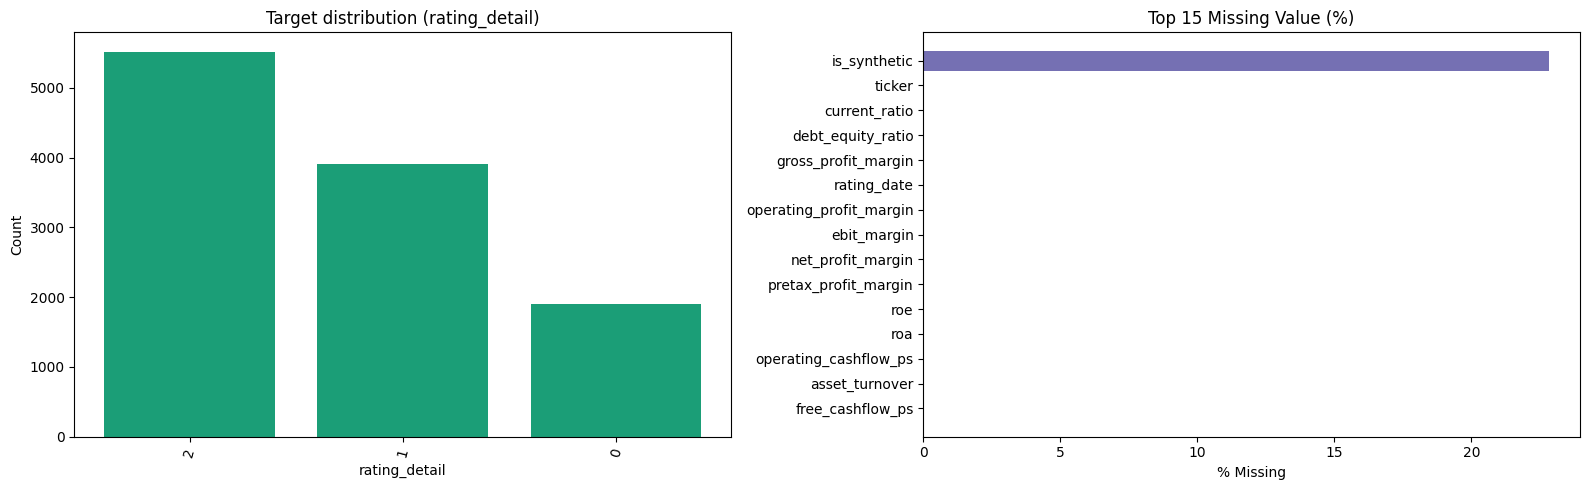

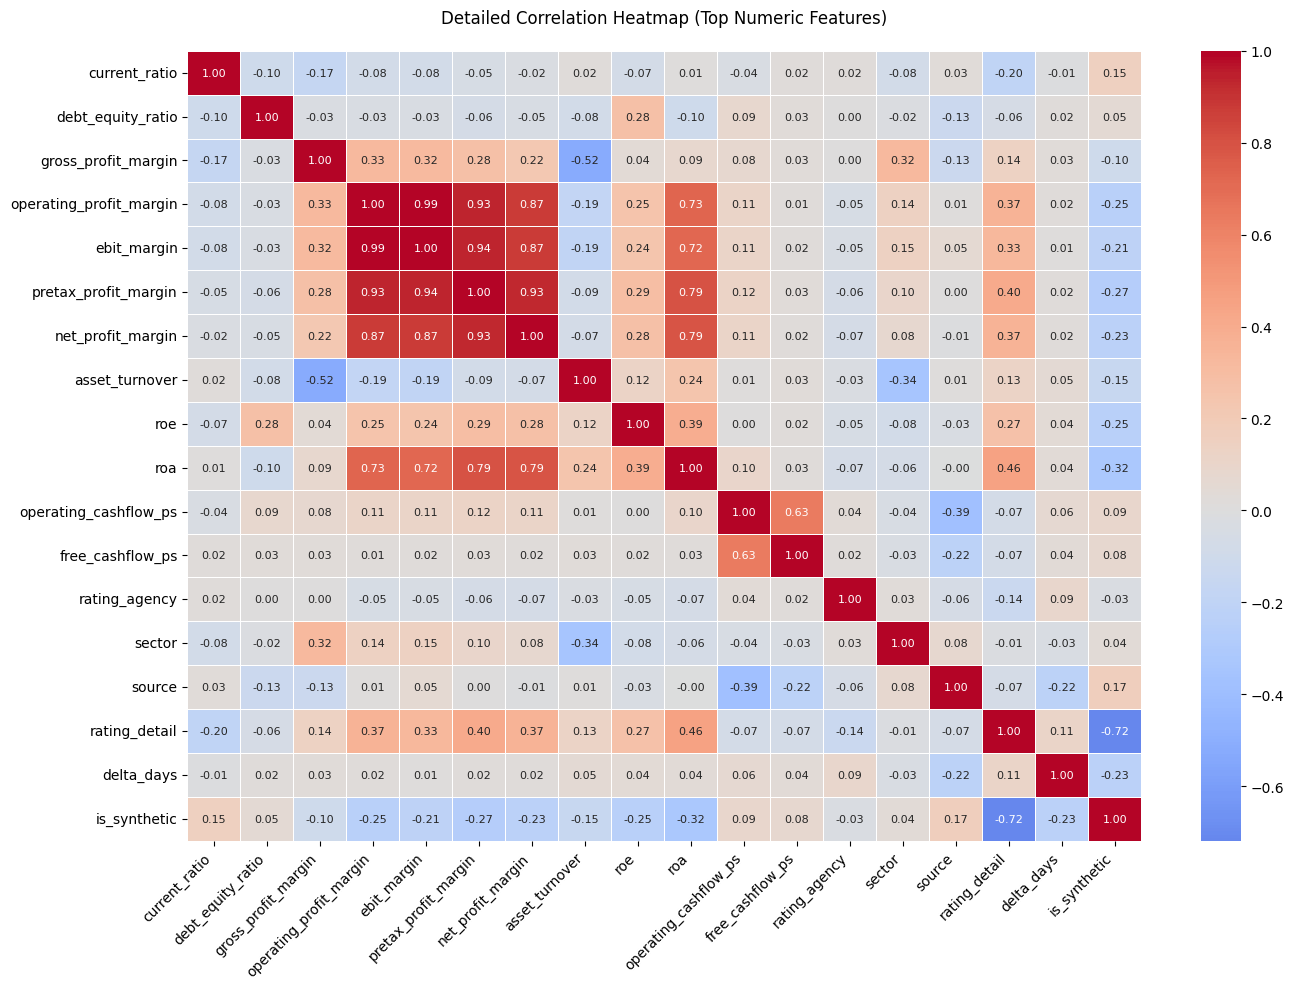

EDA plots saved successfully.


In [6]:
# Quick EDA: label distribution and missing-value ratio.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

target_counts = df["rating_detail"].value_counts().sort_values(ascending=False)
axes[0].bar(target_counts.index.astype(str), target_counts.values, color="#1b9e77")
axes[0].set_title("Target distribution (rating_detail)")
axes[0].set_xlabel("rating_detail")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=75)

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
top_missing = missing_pct.head(15)
axes[1].barh(top_missing.index[::-1], top_missing.values[::-1], color="#7570b3")
axes[1].set_title("Top 15 Missing Value (%)")
axes[1].set_xlabel("% Missing")

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "eda_bars.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlation heatmap for up to 20 numeric columns, excluding binary target if present.
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_corr = [c for c in num_cols_all if c not in ["binary_rating"]][:20]
if len(num_cols_corr) >= 2:
    corr = df[num_cols_corr].corr()
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        annot_kws={"size": 8},
    )
    plt.title("Detailed Correlation Heatmap (Top Numeric Features)", pad=20)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "eda_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("[INFO] Not enough numeric columns for correlation heatmap.")

print("EDA plots saved successfully.")

## 3. Target Validation and Feature Preprocessing

Xác thực biến mục tiêu, chuẩn hóa cột đặc trưng  và  chuẩn bị dữ liệu nhất quán giữa train/val/test.


In [7]:
FINANCIAL_FEATURES = [
    "current_ratio",
    "debt_equity_ratio",
    "gross_profit_margin",
    "operating_profit_margin",
    "ebit_margin",
    "pretax_profit_margin",
    "net_profit_margin",
    "asset_turnover",
    "roe",
    "roa",
    "operating_cashflow_ps",
    "free_cashflow_ps",
]

SECTOR_COL = "sector"
SECTOR_UNKNOWN = "UNKNOWN"
TICKER_COL = "ticker"
COMPANY_COL = "company_name"
TARGET_COL = "rating_detail"

# If labels are strings, keep this risk order when available.
TARGET_ORDERED_LABELS = ["Distressed", "HY", "IG"]

before_rows = len(df)
df = df.dropna(subset=[TARGET_COL]).copy().reset_index(drop=True)
df["row_id"] = np.arange(len(df), dtype=int)

target_as_num = pd.to_numeric(df[TARGET_COL], errors="coerce")
if target_as_num.notna().all():
    df[TARGET_COL] = target_as_num.astype(int)
    observed_classes_raw = sorted(df[TARGET_COL].unique().tolist())
    raw_to_id = {int(raw): idx for idx, raw in enumerate(observed_classes_raw)}
    id_to_raw = {idx: int(raw) for raw, idx in raw_to_id.items()}
    df[TARGET_COL] = df[TARGET_COL].map(raw_to_id).astype(int)
else:
    target_as_str = df[TARGET_COL].astype(str).str.strip()
    observed_str = sorted(target_as_str.unique().tolist())
    if set(observed_str).issubset(set(TARGET_ORDERED_LABELS)):
        ordered_present = [c for c in TARGET_ORDERED_LABELS if c in observed_str]
    else:
        ordered_present = observed_str
    raw_to_id = {raw: idx for idx, raw in enumerate(ordered_present)}
    id_to_raw = {idx: raw for raw, idx in raw_to_id.items()}
    df[TARGET_COL] = target_as_str.map(raw_to_id).astype(int)

EXPECTED_CLASSES = sorted(df[TARGET_COL].unique().tolist())
if EXPECTED_CLASSES != list(range(len(EXPECTED_CLASSES))):
    raise ValueError(f"Label IDs must be contiguous from 0. Got: {EXPECTED_CLASSES}")

n_classes = len(EXPECTED_CLASSES)
TARGET_MIN, TARGET_MAX = 0, n_classes - 1


class _StaticLabelEncoder:
    def __init__(self, classes):
        self.classes_ = np.array(classes, dtype=object)


le = _StaticLabelEncoder(classes=[id_to_raw[i] for i in range(n_classes)])

df["rating_date"] = pd.to_datetime(df["rating_date"], format="mixed")
df[TICKER_COL] = df[TICKER_COL].fillna("UNKNOWN_TICKER").astype(str).str.strip()
df[COMPANY_COL] = df[COMPANY_COL].fillna("UNKNOWN_COMPANY").astype(str).str.strip()

if SECTOR_COL not in df.columns:
    df[SECTOR_COL] = SECTOR_UNKNOWN
df[SECTOR_COL] = df[SECTOR_COL].fillna(SECTOR_UNKNOWN).astype(str).str.strip()
df.loc[df[SECTOR_COL] == "", SECTOR_COL] = SECTOR_UNKNOWN

split_series = df["__split__"].astype(str).str.lower()
train_mask_raw = split_series == "train"
has_train_rows = bool(train_mask_raw.any())
stats_ref = df.loc[train_mask_raw].copy() if has_train_rows else df.copy()

sector_encoder = LabelEncoder()
sector_encoder.fit(stats_ref[SECTOR_COL])
SECTOR_CLASSES = sector_encoder.classes_.tolist()
_UNKNOWN_SECTOR_ID = len(SECTOR_CLASSES)


def _encode_from_classes(val, classes, encoder, unknown_id):
    return int(encoder.transform([val])[0]) if val in classes else int(unknown_id)


df["sector_id"] = df[SECTOR_COL].apply(
    lambda val: _encode_from_classes(val, sector_encoder.classes_, sector_encoder, _UNKNOWN_SECTOR_ID)
)
n_sectors = len(SECTOR_CLASSES) + 1

ticker_encoder = LabelEncoder()
ticker_encoder.fit(stats_ref[TICKER_COL])
TICKER_CLASSES = ticker_encoder.classes_.tolist()
_UNKNOWN_TICKER_ID = len(TICKER_CLASSES)
df["ticker_id"] = df[TICKER_COL].apply(
    lambda val: _encode_from_classes(val, ticker_encoder.classes_, ticker_encoder, _UNKNOWN_TICKER_ID)
)
n_tickers = len(TICKER_CLASSES) + 1

company_encoder = LabelEncoder()
company_encoder.fit(stats_ref[COMPANY_COL])
COMPANY_CLASSES = company_encoder.classes_.tolist()
_UNKNOWN_COMPANY_ID = len(COMPANY_CLASSES)
df["company_id"] = df[COMPANY_COL].apply(
    lambda val: _encode_from_classes(val, company_encoder.classes_, company_encoder, _UNKNOWN_COMPANY_ID)
)
n_companies = len(COMPANY_CLASSES) + 1

print(f"[P1 Fix 4 OK] Sector encoder fit on train only: {len(SECTOR_CLASSES)} known + 1 unknown")
val_unknown = (df.loc[df["__split__"] == "val", "sector_id"] == _UNKNOWN_SECTOR_ID).sum()
test_unknown = (df.loc[df["__split__"] == "test", "sector_id"] == _UNKNOWN_SECTOR_ID).sum()
print(f"  Unknown sectors: val={val_unknown}, test={test_unknown}")
print(f"[P3] Entity encoders: tickers={len(TICKER_CLASSES)} + 1 unknown, companies={len(COMPANY_CLASSES)} + 1 unknown")

for col in FINANCIAL_FEATURES:
    med = stats_ref[col].median() if stats_ref[col].notna().any() else df[col].median()
    if pd.isna(med):
        med = 0.0
    if df[col].isna().any():
        df[col] = df[col].fillna(float(med))

for col in FINANCIAL_FEATURES:
    lower = stats_ref[col].quantile(0.01)
    upper = stats_ref[col].quantile(0.99)
    if pd.isna(lower) or pd.isna(upper):
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
    if pd.isna(lower) or pd.isna(upper):
        continue
    df[col] = df[col].clip(float(lower), float(upper))

print(f"Rows kept after target cleanup: {len(df)} / {before_rows}")
print(f"Number of classes (observed): {n_classes}")
print(f"Label range (model IDs): {TARGET_MIN}..{TARGET_MAX}")
print("Observed label IDs:", sorted(df[TARGET_COL].unique().tolist()))
print("Raw-to-ID mapping:", raw_to_id)
print("Decoder classes (ID -> raw):", le.classes_.tolist())
print(f"Sectors encoded: {n_sectors}")
print(f"Tickers encoded: {n_tickers}")
print(f"Companies encoded: {n_companies}")
print(f"Leakage guard reference split: {'train' if has_train_rows else 'all_data_fallback'}")
print("Sample sectors:", SECTOR_CLASSES[:10])
print(f"\nData after preprocessing: {df.shape}")

_TEMPORAL_FEATURES = ["delta_days"]
_available_temporal = [f for f in _TEMPORAL_FEATURES if f in df.columns]
if _available_temporal:
    FINANCIAL_FEATURES = FINANCIAL_FEATURES + _available_temporal
    print(f"[P1 Fix 6 OK] Added temporal features: {_available_temporal}")
else:
    print("[P1 Fix 6 INFO] delta_days not in data, skipping.")

if "validate_feature_alignment_with_metadata" in globals():
    validate_feature_alignment_with_metadata()

[P1 Fix 4 OK] Sector encoder fit on train only: 12 known + 1 unknown
  Unknown sectors: val=0, test=0
[P3] Entity encoders: tickers=1143 + 1 unknown, companies=1515 + 1 unknown
Rows kept after target cleanup: 11327 / 11327
Number of classes (observed): 3
Label range (model IDs): 0..2
Observed label IDs: [0, 1, 2]
Raw-to-ID mapping: {0: 0, 1: 1, 2: 2}
Decoder classes (ID -> raw): [0, 1, 2]
Sectors encoded: 13
Tickers encoded: 1144
Companies encoded: 1516
Leakage guard reference split: train
Sample sectors: ['0', '1', '10', '11', '2', '3', '4', '5', '6', '7']

Data after preprocessing: (11327, 26)
[P1 Fix 6 OK] Added temporal features: ['delta_days']
[OK] 13 financial features match TimeGAN metadata.
[OK] 13 financial features are present in train_df.


In [8]:
# AGENT_FIX [P1] Validation — sector encoder only from train
train_sectors_set = set(df.loc[df["__split__"] == "train", SECTOR_COL].unique())
for cls in sector_encoder.classes_:
    assert cls in train_sectors_set, f"[P1 FAIL] Sector {cls!r} not in train — leakage!"
print(f"[P1 Fix 4 Validation OK] All {len(sector_encoder.classes_)} sector classes from train")

[P1 Fix 4 Validation OK] All 12 sector classes from train


## 4. Panel Time-Series Construction

Chuyển dữ liệu về dạng panel theo ticker  và  timeline để tạo đầu vào chuỗi thời gian ổn định.


In [9]:
df_sorted = df.sort_values(["ticker", "rating_date", "row_id"]).reset_index(drop=True)

panel_df = df_sorted[
    [
        "row_id",
        "ticker",
        "company_name",
        "rating_date",
        "rating_detail",
        "sector_id",
        "ticker_id",
        "company_id",
        "__split__",
    ]
    + FINANCIAL_FEATURES
].copy()
panel_df = panel_df.rename(columns={"ticker": "unique_id", "rating_date": "ds", "rating_detail": "y"})

ticker_counts = panel_df.groupby("unique_id").size().reset_index(name="count")
print("Ticker count statistics:")
print(ticker_counts["count"].describe())
print()

MIN_HISTORY = 1
valid_tickers = ticker_counts[ticker_counts["count"] >= MIN_HISTORY]["unique_id"].tolist()
panel_df = panel_df[panel_df["unique_id"].isin(valid_tickers)].reset_index(drop=True)
row_level_reference = panel_df[["row_id", "unique_id", "company_name", "ds", "y", "__split__"]].copy()

print(f"Tickers with >= {MIN_HISTORY} data points: {len(valid_tickers)}")
print(f"Panel DataFrame shape: {panel_df.shape}")
print(f"Unique tickers: {panel_df['unique_id'].nunique()}")
print(f"Unique companies: {panel_df['company_name'].nunique()}")
print(f"Date range: {panel_df['ds'].min()} to {panel_df['ds'].max()}")
print(f"Unique sectors (encoded): {panel_df['sector_id'].nunique()}")
print("Split distribution:")
print(panel_df["__split__"].value_counts())
display(panel_df.head(10))

Ticker count statistics:
count    1187.000000
mean        9.542544
std         7.369128
min         1.000000
25%         4.000000
50%         9.000000
75%        11.000000
max        43.000000
Name: count, dtype: float64

Tickers with >= 1 data points: 1187
Panel DataFrame shape: (11327, 22)
Unique tickers: 1187
Unique companies: 1615
Date range: 2005-08-16 00:00:00 to 2016-12-27 00:00:00
Unique sectors (encoded): 12
Split distribution:
__split__
train    8742
test     1723
val       862
Name: count, dtype: int64


,row_id,unique_id,company_name,ds,y,sector_id,ticker_id,company_id,__split__,current_ratio,...,operating_profit_margin,ebit_margin,pretax_profit_margin,net_profit_margin,asset_turnover,roe,roa,operating_cashflow_ps,free_cashflow_ps,delta_days
0,8800,AA,Alcoa Corporation,2015-10-14,1,0,1143,1515,val,-0.690769,...,-0.905683,-0.977472,-0.952038,-1.141099,-0.127150,-0.528122,-1.616468,1.432948,0.688766,0.182969
1,9644,AAL,"American Airlines Group, Inc.",2013-11-12,1,3,0,92,test,-0.731203,...,-0.471311,-1.445823,-1.233950,-1.075691,-0.228894,1.275889,-1.469018,1.314448,-2.811663,0.182969
2,5572,AAL,"American Airlines Group, Inc.",2015-06-30,1,3,0,92,train,-0.922569,...,2.071499,2.081079,2.114203,2.082064,-1.415610,3.059869,0.315088,1.343857,-1.121070,1.390993
3,9440,AAP,"Advance Auto Parts, Inc.",2012-06-15,2,6,1,58,val,-0.716343,...,-0.080014,-0.068947,0.071325,-0.015327,1.460299,0.788620,0.965990,1.090507,0.465315,0.182969
4,10419,AAP,"ADVANCE AUTO PARTS, INC.",2013-05-29,2,6,1,12,test,-0.463556,...,-0.092279,-0.081204,0.057542,-0.026650,0.997811,0.445128,0.599158,-1.246011,-0.650242,1.351956
5,1101,AAP,"ADVANCE AUTO PARTS, INC.",2013-09-25,2,6,1,12,train,-0.463556,...,-0.092279,-0.081204,0.057542,-0.026650,0.997811,0.445128,0.599158,-1.246011,-0.650242,0.475718
6,8183,AAP,"ADVANCE AUTO PARTS, INC.",2013-11-13,2,6,1,12,train,-0.463556,...,-0.092279,-0.081204,0.057542,-0.026650,0.997811,0.445128,0.599158,-1.246011,-0.650242,-0.242841
7,9930,AAP,"Advance Auto Parts, Inc.",2013-11-25,2,6,1,58,test,-0.463556,...,-0.092279,-0.081204,0.057542,-0.026650,0.997811,0.445128,0.599158,-1.246011,-0.650242,-1.348479
8,9153,AAP,"ADVANCE AUTO PARTS, INC.",2014-02-21,2,6,1,12,val,-0.228162,...,-0.121636,-0.110541,0.029770,-0.043387,0.730520,0.298944,0.386745,-1.368146,-0.347717,0.230426
9,3063,AAP,"ADVANCE AUTO PARTS, INC.",2014-06-18,2,6,1,12,train,-0.228162,...,-0.121636,-0.110541,0.029770,-0.043387,0.730520,0.298944,0.386745,-1.368146,-0.347717,0.461923


## 5. Sliding Windows, Split, and DataLoaders

Tạo mẫu cửa sổ thời gian, chia train/val/test theo nguyên tắc chống leakage  và  build DataLoader.


In [10]:
# Row-level temporal context builder: one sequence per row, ending at the current row.
HORIZON = 1
WINDOW_PADDING_MODE = "edge"
INPUT_SIZE_SEARCH_ENABLED = True
INPUT_SIZE_DEFAULT = 8  # Aligned sequence length to 8 quarters (2 years)
INPUT_SIZE_MIN = 1
INPUT_SIZE_MAX = 12
ENABLE_SYNTH_QC = True
ENABLE_WEIGHTED_SAMPLER = False  # Fixed by the shared benchmark protocol.
SAMPLER_WEIGHT_POWER = 0.20  # Giam drift phan phoi train/val de curve gan LSTM baseline hon.

INPUT_SIZE = int(np.clip(INPUT_SIZE_DEFAULT, INPUT_SIZE_MIN, INPUT_SIZE_MAX))
input_size_reason = "fixed_row_level_current_step"
INPUT_SIZE_SEARCH_REPORT = pd.DataFrame(
    [
        {
            "input_size": int(INPUT_SIZE),
            "train_windows": int((panel_df["__split__"] == "train").sum()),
            "val_windows": int((panel_df["__split__"] == "val").sum()),
            "test_windows": int((panel_df["__split__"] == "test").sum()),
            "total_windows": int(len(panel_df)),
            "padded_windows_total": int(0),
            "score": 1.0,
        }
    ]
)

print(f"INPUT_SIZE selected: {INPUT_SIZE} ({input_size_reason})")
print(f"HORIZON (forecast): {HORIZON}")
print(f"Window padding mode: {WINDOW_PADDING_MODE}")
print(INPUT_SIZE_SEARCH_REPORT.to_string(index=False))

panel_df_filtered = panel_df.sort_values(["unique_id", "ds", "row_id"]).reset_index(drop=True)
print(f"Panel shape for row-level sequence generation: {panel_df_filtered.shape}")

DELTA_FEATURES = []
for col in FINANCIAL_FEATURES:
    dcol = f"{col}_delta"
    panel_df_filtered[dcol] = panel_df_filtered.groupby("unique_id")[col].diff().fillna(0.0)
    DELTA_FEATURES.append(dcol)

MODEL_FEATURES = FINANCIAL_FEATURES + DELTA_FEATURES
train_mask_clip = panel_df_filtered["__split__"] == "train"
for col in MODEL_FEATURES:
    col_vals = panel_df_filtered.loc[train_mask_clip, col].dropna()
    if col_vals.empty:
        continue
    lo = col_vals.quantile(0.001)
    hi = col_vals.quantile(0.999)
    if not (np.isfinite(lo) and np.isfinite(hi)) or lo >= hi:
        continue
    panel_df_filtered[col] = panel_df_filtered[col].clip(float(lo), float(hi))

print("[P0 Fix 1 OK] RobustScaler removed. Using StandardScaled values from TimeGAN.")
print(
    f"  MODEL_FEATURES mean (train): {panel_df_filtered.loc[train_mask_clip, MODEL_FEATURES].mean().round(3).to_dict()}"
)
print(
    f"  MODEL_FEATURES std  (train): {panel_df_filtered.loc[train_mask_clip, MODEL_FEATURES].std().round(3).to_dict()}"
)

SEQ_X_IDX = 0
SEQ_LAST_Y_IDX = 1
SEQ_SECTOR_IDX = 2
SEQ_TICKER_IDX = 3
SEQ_COMPANY_IDX = 4
SEQ_TARGET_IDX = 5
SEQ_ROW_ID_IDX = 6


class CreditRatingDataset(Dataset):
    """Row-level dataset with temporal context ending at the current row."""

    def __init__(self, sequences, augment=False, noise_std=0.0, feature_dropout_prob=0.0):
        self.sequences = sequences
        self.augment = augment
        self.noise_std = float(noise_std)
        self.feature_dropout_prob = float(feature_dropout_prob)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        X, last_y, sector_id, ticker_id, company_id, y_target, row_id = self.sequences[idx]
        X = np.asarray(X, dtype=np.float32).copy()

        if self.augment:
            if self.noise_std > 0:
                X += np.random.normal(0.0, self.noise_std, size=X.shape).astype(np.float32)
            if self.feature_dropout_prob > 0:
                drop_mask = np.random.rand(X.shape[1]) < self.feature_dropout_prob
                if drop_mask.any():
                    X[:, drop_mask] = 0.0

        return (
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(last_y, dtype=torch.long),
            torch.tensor(sector_id, dtype=torch.long),
            torch.tensor(ticker_id, dtype=torch.long),
            torch.tensor(company_id, dtype=torch.long),
            torch.tensor(y_target, dtype=torch.long),
            torch.tensor(row_id, dtype=torch.long),
        )


def build_context_window(values, target_idx, input_size, mode="edge"):
    start_idx = max(0, target_idx - input_size + 1)
    X_raw = values[start_idx : target_idx + 1]
    if X_raw.shape[0] >= input_size:
        return X_raw[-input_size:]

    pad_len = input_size - X_raw.shape[0]
    if mode == "zero":
        pad_block = np.zeros((pad_len, X_raw.shape[1]), dtype=X_raw.dtype)
    else:
        pad_block = np.repeat(X_raw[[0]], pad_len, axis=0)
    return np.concatenate([pad_block, X_raw], axis=0)


feature_cols = MODEL_FEATURES
n_channels = len(feature_cols)

train_seqs = []
val_seqs = []
test_seqs = []
test_seq_tickers = []
test_seq_row_ids = []
train_seq_is_synth = []
train_seq_is_change = []
has_synth_col = "is_synthetic" in panel_df_filtered.columns
padded_window_count = 0

for uid, grp in panel_df_filtered.groupby("unique_id"):
    grp = grp.sort_values(["ds", "row_id"], kind="mergesort").reset_index(drop=True)
    values = grp[feature_cols].values
    n = len(values)
    if n == 0:
        continue

    for target_idx in range(n):
        X = build_context_window(values, target_idx=target_idx, input_size=INPUT_SIZE, mode=WINDOW_PADDING_MODE)
        if X is None or X.shape[0] != INPUT_SIZE:
            continue

        if target_idx < INPUT_SIZE - 1:
            padded_window_count += 1

        last_y_idx = max(0, target_idx - 1)
        sample = (
            X,
            int(grp["y"].iloc[last_y_idx]),
            int(grp["sector_id"].iloc[target_idx]),
            int(grp["ticker_id"].iloc[target_idx]),
            int(grp["company_id"].iloc[target_idx]),
            int(grp["y"].iloc[target_idx]),
            int(grp["row_id"].iloc[target_idx]),
        )
        split_label = str(grp["__split__"].iloc[target_idx]).lower()

        if split_label == "test":
            test_seqs.append(sample)
            test_seq_tickers.append(uid)
            test_seq_row_ids.append(int(grp["row_id"].iloc[target_idx]))
        elif split_label == "val":
            val_seqs.append(sample)
        else:
            train_seqs.append(sample)
            train_seq_is_change.append(int(grp["y"].iloc[target_idx] != grp["y"].iloc[last_y_idx]))
            if has_synth_col:
                train_seq_is_synth.append(int(grp["is_synthetic"].iloc[target_idx]))
            else:
                train_seq_is_synth.append(0)

if len(train_seqs) == 0 or len(val_seqs) == 0 or len(test_seqs) == 0:
    raise ValueError(
        f"Empty split sequences found: train={len(train_seqs)}, val={len(val_seqs)}, test={len(test_seqs)}."
    )

test_seq_tickers = np.array(test_seq_tickers, dtype=object)
test_seq_row_ids = np.array(test_seq_row_ids, dtype=int)
train_seq_is_synth = np.array(train_seq_is_synth, dtype=int)
train_seq_is_change = np.array(train_seq_is_change, dtype=int)

SYNTH_MAX_ABS_FEATURE = 6.0
SYNTH_MAX_RATIO = 0.45
train_seqs_before_synth_qc = len(train_seqs)
if ENABLE_SYNTH_QC and has_synth_col and len(train_seqs) > 0:
    seq_max_abs = np.array([float(np.max(np.abs(s[SEQ_X_IDX]))) for s in train_seqs], dtype=np.float32)
    keep_mask = np.ones(len(train_seqs), dtype=bool)
    synth_mask = train_seq_is_synth == 1
    keep_mask[synth_mask & (seq_max_abs > SYNTH_MAX_ABS_FEATURE)] = False

    kept_synth_idx = np.where(keep_mask & synth_mask)[0]
    kept_real_idx = np.where(keep_mask & (~synth_mask))[0]
    max_synth_keep = int(len(kept_real_idx) * SYNTH_MAX_RATIO / max(1e-9, 1.0 - SYNTH_MAX_RATIO))
    if len(kept_synth_idx) > max_synth_keep > 0:
        rng_seq = np.random.default_rng(SEED)
        drop_idx = rng_seq.choice(
            kept_synth_idx,
            size=len(kept_synth_idx) - max_synth_keep,
            replace=False,
        )
        keep_mask[drop_idx] = False

    if not keep_mask.all():
        train_seqs = [s for s, k in zip(train_seqs, keep_mask) if k]
        train_seq_is_synth = train_seq_is_synth[keep_mask]
        train_seq_is_change = train_seq_is_change[keep_mask]
train_seqs_after_synth_qc = len(train_seqs)

TRAIN_WINDOW_NOISE_STD = 0.0
TRAIN_FEATURE_DROPOUT = 0.0

train_ds = CreditRatingDataset(
    train_seqs, augment=True, noise_std=TRAIN_WINDOW_NOISE_STD, feature_dropout_prob=TRAIN_FEATURE_DROPOUT
)
train_eval_ds = CreditRatingDataset(train_seqs, augment=False)
val_ds = CreditRatingDataset(val_seqs, augment=False)
test_ds = CreditRatingDataset(test_seqs, augment=False)

train_labels = np.array([s[SEQ_TARGET_IDX] for s in train_seqs], dtype=int)
class_freq_raw = np.bincount(train_labels, minlength=n_classes).astype(float)
non_zero_freq = class_freq_raw[class_freq_raw > 0]
imbalance_ratio = float(class_freq_raw.max() / non_zero_freq.min()) if len(non_zero_freq) > 0 else 1.0
synthetic_ratio_train = float(train_seq_is_synth.mean()) if len(train_seq_is_synth) > 0 else 0.0
transition_ratio_train = float(train_seq_is_change.mean()) if len(train_seq_is_change) > 0 else 0.0

weighted_sampler = None

BATCH_SIZE = 64
NUM_WORKERS = 4 if IN_KAGGLE else 0
PIN_MEMORY = device.type == "cuda"

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=(weighted_sampler is None),
    sampler=weighted_sampler,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"\nChannels: {n_channels}")
print(f"Base features: {len(FINANCIAL_FEATURES)} | Delta features: {len(DELTA_FEATURES)}")
print(f"Train samples: {len(train_ds)}")
print(f"Val samples:   {len(val_ds)}")
print(f"Test samples:  {len(test_ds)}")
print(f"Test ticker refs: {len(test_seq_tickers)} | row ids: {len(test_seq_row_ids)}")
print(f"Padded row-level windows: {padded_window_count}")
print(
    f"Synth QC enabled: {ENABLE_SYNTH_QC} | removed windows: {train_seqs_before_synth_qc - train_seqs_after_synth_qc}"
)
print(f"Train synthetic ratio (rows): {synthetic_ratio_train:.3f}")
print(f"Train transition ratio (y_t != y_t-1): {transition_ratio_train:.3f}")
print(f"Train class freq min/max: {class_freq_raw.min():.0f}/{class_freq_raw.max():.0f}")
print(f"Imbalance ratio (max/min non-zero): {imbalance_ratio:.2f}")
print(f"Weighted sampler enabled: {weighted_sampler is not None}")
print(f"Sampler weight power: {SAMPLER_WEIGHT_POWER}")
print(f"Train window noise std: {TRAIN_WINDOW_NOISE_STD}")
print(f"Train feature dropout prob: {TRAIN_FEATURE_DROPOUT}")

sample_X, sample_last_y, sample_sector_id, sample_ticker_id, sample_company_id, sample_y, sample_row_id = train_ds[0]
print(f"\nSample X shape: {sample_X.shape}  (T, C)")
print(f"Sample last_y: {sample_last_y}")
print(f"Sample sector_id: {sample_sector_id}")
print(f"Sample ticker_id: {sample_ticker_id}")
print(f"Sample company_id: {sample_company_id}")
print(f"Sample y: {sample_y} | row_id: {sample_row_id}")


INPUT_SIZE selected: 8 (fixed_row_level_current_step)
HORIZON (forecast): 1
Window padding mode: edge
 input_size  train_windows  val_windows  test_windows  total_windows  padded_windows_total  score
          8           8742          862          1723          11327                     0    1.0
Panel shape for row-level sequence generation: (11327, 22)
[P0 Fix 1 OK] RobustScaler removed. Using StandardScaled values from TimeGAN.
  MODEL_FEATURES mean (train): {'current_ratio': 0.086, 'debt_equity_ratio': 0.024, 'gross_profit_margin': -0.059, 'operating_profit_margin': -0.137, 'ebit_margin': -0.113, 'pretax_profit_margin': -0.15, 'net_profit_margin': -0.125, 'asset_turnover': -0.089, 'roe': -0.15, 'roa': -0.186, 'operating_cashflow_ps': 0.053, 'free_cashflow_ps': 0.042, 'delta_days': -0.183, 'current_ratio_delta': -0.001, 'debt_equity_ratio_delta': 0.012, 'gross_profit_margin_delta': -0.001, 'operating_profit_margin_delta': -0.013, 'ebit_margin_delta': -0.012, 'pretax_profit_margin_de

In [11]:
# AGENT_FIX [P0] Validation — mean ~0, std ~1 (StandardScaled)
train_stats = panel_df_filtered.loc[panel_df_filtered["__split__"] == "train", MODEL_FEATURES]
mean_abs = train_stats.mean().abs().max()
std_range = (train_stats.std() - 1).abs().max()
assert mean_abs < 1.5, f"[P0 FAIL] Mean too large ({mean_abs:.3f}), suspect double scaling"
assert std_range < 1.5, f"[P0 FAIL] Std far from 1 ({std_range:.3f}), suspect bad scaling"
print(f"[P0 Validation OK] max|mean|={mean_abs:.3f}, max|std-1|={std_range:.3f}")

[P0 Validation OK] max|mean|=0.186, max|std-1|=0.820


In [12]:
# AGENT_FIX [P0] Validation — INPUT_SIZE and sequence counts
assert INPUT_SIZE >= 1, f"[P0 FAIL] INPUT_SIZE={INPUT_SIZE} too small"
assert len(train_seqs) > 0, "[P0 FAIL] train_seqs is empty after INPUT_SIZE change"
assert len(val_seqs) > 0, "[P0 FAIL] val_seqs is empty"
assert len(test_seqs) > 0, "[P0 FAIL] test_seqs is empty"
sample_X = train_seqs[0][0]
assert sample_X.shape[0] == INPUT_SIZE, f"[P0 FAIL] Window shape wrong: {sample_X.shape[0]} != {INPUT_SIZE}"
print(f"[P0 Fix 2 OK] INPUT_SIZE={INPUT_SIZE}, train={len(train_seqs)}, val={len(val_seqs)}, test={len(test_seqs)}")

[P0 Fix 2 OK] INPUT_SIZE=8, train=8742, val=862, test=1723


In [13]:
# ============================================================
# Deterministic DataLoader Rebuild (stability/reproducibility)
# ============================================================


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

weighted_sampler = None

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=(weighted_sampler is None),
    sampler=weighted_sampler,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator if weighted_sampler is None else None,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator,
)

print("Rebuilt DataLoaders with deterministic generator and worker seeding.")
print(f"Weighted sampler enabled: {weighted_sampler is not None}")
print(f"Persistent workers: {bool(NUM_WORKERS > 0)}")

Rebuilt DataLoaders with deterministic generator and worker seeding.
Weighted sampler enabled: False
Persistent workers: True


## 6. Loss Function and Class-Imbalance Handling

Định nghĩa loss cho bài toán ordinal classification  và  xử lý mất cân bằng lớp.


In [14]:
criterion_settings = {
    'loss_name': LOSS_PROTOCOL,
    'ordinal_lambda': ORDINAL_LAMBDA,
}
criterion = build_loss(
    protocol=LOSS_PROTOCOL,
    ordinal_lambda=ORDINAL_LAMBDA,
).to(device)
print('Transformer-LSTM two-tier criterion:', criterion_settings)


Transformer-LSTM two-tier criterion: {'loss_name': 'benchmark_ce', 'ordinal_lambda': 0.1}


## 5. Model Architecture

Khai bao Transformer temporal block nhe, LSTM mot chieu, entity embeddings va head phan loai.


In [15]:
class TemporalSelfAttentionBlock(nn.Module):
    """Pre-norm Transformer block with learnable relative positional bias."""

    def __init__(self, d_model=128, n_heads=4, dropout=0.1, max_relative_position=32):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.max_relative_position = int(max_relative_position)
        self.relative_bias = nn.Parameter(torch.zeros(2 * self.max_relative_position + 1))

    def _relative_bias_matrix(self, seq_len, device, dtype):
        pos = torch.arange(seq_len, device=device)
        rel = pos[None, :] - pos[:, None]
        rel = rel.clamp(-self.max_relative_position, self.max_relative_position)
        rel = rel + self.max_relative_position
        return self.relative_bias[rel].to(dtype=dtype)

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_bias = self._relative_bias_matrix(x.size(1), x.device, x.dtype)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, attn_mask=attn_bias, need_weights=False)
        x = x + self.dropout(attn_out)
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x


class AttentivePool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh(),
            nn.Linear(dim, 1),
        )

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        ctx = (w * x).sum(dim=1)
        return ctx, w


class TransformerLSTMClassifier(nn.Module):
    """Pure Transformer-LSTM classifier for row-level credit-rating sequences."""

    def __init__(
        self,
        n_channels,
        n_classes,
        n_sectors,
        n_tickers,
        n_companies,
        hidden_size=64,
        dropout=0.25,
        d_model=64,
        n_heads=4,
        n_layers=1,
        sector_emb_dim=16,
        ticker_emb_dim=4,
        company_emb_dim=4,
        max_relative_position=8,
        pre_lstm_dropout=0.2,
    ):
        super().__init__()
        self.n_layers = int(n_layers)

        self.input_norm = nn.LayerNorm(n_channels)
        self.input_proj = nn.Sequential(
            nn.Linear(n_channels, d_model),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )
        self.blocks = nn.ModuleList(
            [
                TemporalSelfAttentionBlock(
                    d_model=d_model,
                    n_heads=n_heads,
                    dropout=dropout,
                    max_relative_position=max_relative_position,
                )
                for _ in range(self.n_layers)
            ]
        )
        self.pre_lstm_norm = nn.LayerNorm(d_model)
        self.pre_lstm_dropout = nn.Dropout(float(pre_lstm_dropout))
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_size,
            batch_first=True,
        )
        self.lstm_out_dim = hidden_size
        self.attn_pool = AttentivePool(self.lstm_out_dim)
        self.last_y_embed = nn.Embedding(n_classes, hidden_size)
        self.sector_embed = nn.Embedding(n_sectors, sector_emb_dim)
        self.ticker_embed = nn.Embedding(n_tickers, ticker_emb_dim)
        self.company_embed = nn.Embedding(n_companies, company_emb_dim)
        self.emb_dropout = nn.Dropout(dropout)

        transition_in_dim = self.lstm_out_dim + sector_emb_dim + ticker_emb_dim + company_emb_dim
        self.transition_head = nn.Sequential(
            nn.Linear(transition_in_dim, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

        head_in_dim = self.lstm_out_dim + hidden_size + sector_emb_dim + ticker_emb_dim + company_emb_dim
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(head_in_dim, hidden_size * 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.8),
            nn.Linear(hidden_size * 2, n_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, x, last_y, sector_id, ticker_id=None, company_id=None, return_aux=False):
        x_features = self.input_norm(x)
        x_embed = self.input_proj(x_features)
        for blk in self.blocks:
            x_embed = blk(x_embed)
        x_embed = self.pre_lstm_norm(x_embed)
        x_embed = self.pre_lstm_dropout(x_embed)
        lstm_out, _ = self.lstm(x_embed)
        seq_ctx, _ = self.attn_pool(lstm_out)

        batch_size = x.size(0)
        if ticker_id is None:
            ticker_id = torch.zeros(batch_size, dtype=torch.long, device=x.device)
        if company_id is None:
            company_id = torch.zeros(batch_size, dtype=torch.long, device=x.device)

        last_y_emb = self.emb_dropout(self.last_y_embed(last_y))
        sector_emb = self.emb_dropout(self.sector_embed(sector_id))
        ticker_emb = self.emb_dropout(self.ticker_embed(ticker_id))
        company_emb = self.emb_dropout(self.company_embed(company_id))
        aux_context = torch.cat([seq_ctx, sector_emb, ticker_emb, company_emb], dim=-1)
        transition_logits = self.transition_head(aux_context).squeeze(-1)

        out = torch.cat([seq_ctx, last_y_emb, sector_emb, ticker_emb, company_emb], dim=-1)
        logits = self.head(out)
        if return_aux:
            return logits, transition_logits
        return logits


MODEL_D_MODEL = 96
TRANSFORMER_HEADS = 4
TRANSFORMER_LAYERS = 2
LSTM_HIDDEN = 96
SECTOR_EMB_DIM = 16
TICKER_EMB_DIM = 16
COMPANY_EMB_DIM = 16
TLSTM_DROPOUT = 0.38
PRE_LSTM_DROPOUT = 0.2
MAX_RELATIVE_POSITION = 8

model = TransformerLSTMClassifier(
    n_channels=n_channels,
    n_classes=n_classes,
    n_sectors=n_sectors,
    n_tickers=n_tickers,
    n_companies=n_companies,
    hidden_size=LSTM_HIDDEN,
    dropout=TLSTM_DROPOUT,
    d_model=MODEL_D_MODEL,
    n_heads=TRANSFORMER_HEADS,
    n_layers=TRANSFORMER_LAYERS,
    sector_emb_dim=SECTOR_EMB_DIM,
    ticker_emb_dim=TICKER_EMB_DIM,
    company_emb_dim=COMPANY_EMB_DIM,
    max_relative_position=MAX_RELATIVE_POSITION,
    pre_lstm_dropout=PRE_LSTM_DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Pure Transformer-LSTM model created successfully!")
print(f"Projected d_model: {MODEL_D_MODEL}")
print(f"Transformer layers/heads: {TRANSFORMER_LAYERS}/{TRANSFORMER_HEADS}")
print(f"Relative position window: +/-{MAX_RELATIVE_POSITION}")
print(f"LSTM hidden size: {LSTM_HIDDEN} | direction=single")
print(f"Pre-LSTM dropout: {PRE_LSTM_DROPOUT}")
print(f"Sector embedding dim: {SECTOR_EMB_DIM}")
print(f"Ticker embedding dim: {TICKER_EMB_DIM}")
print(f"Company embedding dim: {COMPANY_EMB_DIM}")
print(f"Channels: {n_channels} (base + delta features)")
print(f"Sectors: {n_sectors} | Tickers: {n_tickers} | Companies: {n_companies}")
print(f"Model parameters: {n_params:,}")
print(model)

Pure Transformer-LSTM model created successfully!
Projected d_model: 96
Transformer layers/heads: 2/4
Relative position window: +/-8
LSTM hidden size: 96 | direction=single
Pre-LSTM dropout: 0.2
Sector embedding dim: 16
Ticker embedding dim: 16
Company embedding dim: 16
Channels: 26 (base + delta features)
Sectors: 13 | Tickers: 1144 | Companies: 1516
Model parameters: 414,379
TransformerLSTMClassifier(
  (input_norm): LayerNorm((26,), eps=1e-05, elementwise_affine=True)
  (input_proj): Sequential(
    (0): Linear(in_features=26, out_features=96, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.19, inplace=False)
  )
  (blocks): ModuleList(
    (0-1): 2 x TemporalSelfAttentionBlock(
      (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
      )
      (dropout): 

In [16]:
# ============================================================
# Cell 24: PriMO HPO via NePS (Neural Pipeline Search)
# ============================================================


import sys
import os
import json
import warnings
from pathlib import Path

import numpy as np


# NePS install/import helpers
def _get_neps_version(neps_module):
    """Return a printable NePS version without assuming __version__ exists."""
    return str(getattr(neps_module, "__version__", "unknown"))


def install_neps_kaggle():
    """Install NePS safely in Kaggle; return False when offline or blocked."""
    try:
        import neps  # type: ignore[import]

        print(f"[OK] NePS {_get_neps_version(neps)} already installed.")
        return True
    except ImportError:
        pass

    try:
        import subprocess

        result = subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "neural-pipeline-search",
                "--quiet",
                "--no-warn-script-location",
            ],
            capture_output=True,
            text=True,
            timeout=120,
        )
    except Exception as exc:
        print(f"[WARN] NePS install skipped/failed: {exc}")
        return False

    if result.returncode == 0:
        try:
            import neps  # type: ignore[import]

            print(f"[OK] NePS {_get_neps_version(neps)} installed successfully.")
            return True
        except ImportError as exc:
            print(f"[WARN] NePS installed but import failed: {exc}")
            return False

    print(f"[WARN] NePS install failed: {result.stderr[:300]}")
    return False


NEPS_INSTALLED = install_neps_kaggle()


# PriMO/HPO utilities are defined inline so this notebook is self-contained on Kaggle/local.
# Do not write or import an external HPO module here; keep the notebook as the runtime source of truth.
import copy
import csv
import json
import inspect
import math
import random
import shutil
import time
import traceback
from pathlib import Path
from typing import Any, Callable

try:
    import neps  # type: ignore[import-not-found]

    _NEPS_AVAILABLE = True
except ImportError:
    neps = None  # type: ignore[assignment]
    _NEPS_AVAILABLE = False


PRIMO_SEARCH_VERSION = "tlstm_primo_v2_monitor_aligned"

PRIMO_EXPERT_PRIOR: dict[str, Any] = {
    "hidden_size": 48,
    "d_model": 48,
    "n_heads": 4,
    "n_layers": 1,
    "dropout": 0.44,
    "pre_lstm_dropout": 0.30,
    "batch_size": 48,
    "lr": 2.0e-4,
    "max_lr": 3.0e-4,
    "weight_decay": 1.2e-3,
    "context_dropout_prob": 0.30,
    "train_input_noise_std": 0.005,
    "train_channel_dropout_prob": 0.03,
    "train_timestep_dropout_prob": 0.03,
    "loss_gap_penalty_weight": 0.35,
    "sector_emb_dim": 8,
    "ticker_emb_dim": 4,
    "company_emb_dim": 4,
    "max_relative_position": 8,
}

_HEAD_CHOICES = (1, 2, 4, 8)
_BATCH_SIZE_CHOICES = (32, 48, 64, 96, 128)
_PRIMO_CONTEXT: dict[str, Any] = {}
_TRIAL_ROWS: list[dict[str, Any]] = []


def snap_n_heads(d_model: int, n_heads: int) -> int:
    """Return the nearest valid attention-head count for d_model."""
    d_model = int(d_model)
    n_heads = int(n_heads)
    if d_model < n_heads:
        return 1
    valid = [h for h in _HEAD_CHOICES if h <= d_model and d_model % h == 0]
    if not valid:
        return 1
    return int(min(valid, key=lambda h: (abs(h - n_heads), -h)))


def snap_batch_size(batch_size: int) -> int:
    """Return the nearest Kaggle-safe batch size candidate."""
    batch_size = int(batch_size)
    return int(min(_BATCH_SIZE_CHOICES, key=lambda b: (abs(b - batch_size), b)))


def _make_neps_dimension(kind: str, **kwargs: Any) -> Any:
    """Create a NePS dimension while tolerating minor API differences."""
    if neps is None:
        raise ImportError("neps is not installed")
    cls = getattr(neps, kind)
    try:
        return cls(**kwargs)
    except TypeError:
        kwargs.pop("default", None)
        try:
            return cls(**kwargs)
        except TypeError:
            kwargs.pop("is_fidelity", None)
            return cls(**kwargs)


def build_pipeline_space() -> dict[str, Any]:
    """Create the NePS pipeline space with thesis expert priors."""
    if neps is None:
        raise ImportError("NePS is not installed; use fallback PriMO instead.")
    return {
        "hidden_size": _make_neps_dimension(
            "Integer", lower=32, upper=56, default=PRIMO_EXPERT_PRIOR["hidden_size"], log=True
        ),
        "d_model": _make_neps_dimension(
            "Integer", lower=32, upper=56, default=PRIMO_EXPERT_PRIOR["d_model"], log=True
        ),
        "n_heads": _make_neps_dimension(
            "Categorical", choices=list(_HEAD_CHOICES), default=PRIMO_EXPERT_PRIOR["n_heads"]
        ),
        "n_layers": _make_neps_dimension("Categorical", choices=[1], default=PRIMO_EXPERT_PRIOR["n_layers"]),
        "dropout": _make_neps_dimension("Float", lower=0.40, upper=0.50, default=PRIMO_EXPERT_PRIOR["dropout"]),
        "pre_lstm_dropout": _make_neps_dimension(
            "Float", lower=0.25, upper=0.45, default=PRIMO_EXPERT_PRIOR["pre_lstm_dropout"]
        ),
        "batch_size": _make_neps_dimension(
            "Categorical", choices=list(_BATCH_SIZE_CHOICES), default=PRIMO_EXPERT_PRIOR["batch_size"]
        ),
        "lr": _make_neps_dimension("Float", lower=1e-5, upper=2.5e-4, default=PRIMO_EXPERT_PRIOR["lr"], log=True),
        "max_lr": _make_neps_dimension("Float", lower=5e-5, upper=4e-4, default=PRIMO_EXPERT_PRIOR["max_lr"], log=True),
        "weight_decay": _make_neps_dimension(
            "Float", lower=8e-4, upper=3e-3, default=PRIMO_EXPERT_PRIOR["weight_decay"], log=True
        ),
        "context_dropout_prob": _make_neps_dimension(
            "Float", lower=0.25, upper=0.40, default=PRIMO_EXPERT_PRIOR["context_dropout_prob"]
        ),
        "train_input_noise_std": _make_neps_dimension(
            "Float", lower=0.002, upper=0.020, default=PRIMO_EXPERT_PRIOR["train_input_noise_std"]
        ),
        "train_channel_dropout_prob": _make_neps_dimension(
            "Float", lower=0.010, upper=0.080, default=PRIMO_EXPERT_PRIOR["train_channel_dropout_prob"]
        ),
        "train_timestep_dropout_prob": _make_neps_dimension(
            "Float", lower=0.010, upper=0.080, default=PRIMO_EXPERT_PRIOR["train_timestep_dropout_prob"]
        ),
        "loss_gap_penalty_weight": _make_neps_dimension(
            "Float", lower=0.20, upper=0.50, default=PRIMO_EXPERT_PRIOR["loss_gap_penalty_weight"]
        ),
        "sector_emb_dim": _make_neps_dimension(
            "Categorical", choices=[4, 8], default=PRIMO_EXPERT_PRIOR["sector_emb_dim"]
        ),
        "ticker_emb_dim": _make_neps_dimension(
            "Categorical", choices=[2, 4], default=PRIMO_EXPERT_PRIOR["ticker_emb_dim"]
        ),
        "company_emb_dim": _make_neps_dimension(
            "Categorical", choices=[2, 4], default=PRIMO_EXPERT_PRIOR["company_emb_dim"]
        ),
        "max_relative_position": _make_neps_dimension(
            "Integer", lower=4, upper=8, default=PRIMO_EXPERT_PRIOR["max_relative_position"]
        ),
        "epochs": _make_neps_dimension("Integer", lower=5, upper=20, default=10, is_fidelity=True),
    }


def configure_primo_context(**kwargs: Any) -> None:
    """Store notebook-owned objects used by NePS trial callbacks."""
    _PRIMO_CONTEXT.clear()
    _PRIMO_CONTEXT.update(kwargs)


def _subsample_dataset(dataset: Any, fraction: float, seed: int = 42) -> Any:
    """Sample a deterministic fraction of a torch Dataset."""
    if fraction >= 1.0:
        return dataset
    from torch.utils.data import Subset

    n = max(1, int(len(dataset) * float(fraction)))
    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), n)
    return Subset(dataset, indices)


def _unpack_batch(batch: Any, device: Any) -> tuple[Any, Any, Any, Any, Any, Any]:
    """Move the notebook dataset batch to device.

    Current Transformer-LSTM batches are:
    (X, last_y, sector_id, ticker_id, company_id, y, row_id).
    The older four-field format is kept as a fallback for exported scripts.
    """
    if len(batch) >= 7:
        x, last_y, sector_id, ticker_id, company_id, y, _row_id = batch[:7]
    elif len(batch) == 6:
        x, y, sector_id, ticker_id, company_id, last_y = batch
    elif len(batch) == 4:
        x, last_y, sector_id, y = batch
        ticker_id = company_id = None
    else:
        raise ValueError(f"Unsupported batch structure with {len(batch)} fields")

    def _move(value: Any) -> Any:
        if value is None:
            return None
        return value.to(device, non_blocking=True)

    return _move(x), _move(y), _move(sector_id), _move(ticker_id), _move(company_id), _move(last_y)


def _call_model(model: Any, x: Any, sector_id: Any, ticker_id: Any, company_id: Any, last_y: Any) -> Any:
    """Call the notebook model with its current argument order."""
    return model(x, last_y, sector_id, ticker_id, company_id)


def _monitor_loss_value(criterion_obj: Any, logits: Any, targets: Any) -> Any:
    """Use the same CE monitor loss as the final checkpoint loop."""
    if hasattr(criterion_obj, "monitor_loss"):
        return criterion_obj.monitor_loss(logits, targets)
    import torch.nn.functional as F

    return F.cross_entropy(logits.float(), targets, reduction="mean", label_smoothing=0.0)


def _append_trial_row(row: dict[str, Any]) -> None:
    _TRIAL_ROWS.append(row)
    artifact_dir = _PRIMO_CONTEXT.get("artifact_dir")
    if artifact_dir is None:
        return
    path = Path(artifact_dir) / "transformer_primo_trials.csv"
    fieldnames = [
        "trial_id",
        "epochs",
        "composite_score",
        "val_loss",
        "val_accuracy",
        "f1_weighted",
        "f1_macro",
        "qwk",
        "hidden_size",
        "d_model",
        "n_heads",
        "n_layers",
        "dropout",
        "pre_lstm_dropout",
        "batch_size",
        "lr",
        "max_lr",
        "weight_decay",
        "context_dropout_prob",
        "train_input_noise_std",
        "train_channel_dropout_prob",
        "train_timestep_dropout_prob",
        "loss_gap_penalty_weight",
        "train_loss",
        "loss_gap",
        "chgacc",
        "persistence_rate",
        "elapsed_seconds",
        "search_version",
        "train_monitor_loss",
        "train_objective_loss",
    ]
    extras = [k for k in row if k not in fieldnames]
    fieldnames.extend(extras)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(_TRIAL_ROWS)


def _write_top_configs(artifact_dir: str | Path, top_k: int = 5) -> None:
    """Save a compact top-config table sorted by the aligned PriMO score."""
    if not _TRIAL_ROWS:
        return
    rows = sorted(
        _TRIAL_ROWS, key=lambda row: float(row.get("aligned_score", row.get("composite_score", 0.0))), reverse=True
    )
    path = Path(artifact_dir) / "transformer_primo_top_configs.csv"
    fieldnames = []
    for row in rows[:top_k]:
        for key in row:
            if key not in fieldnames:
                fieldnames.append(key)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows[:top_k])



def _sanitize_eval_config(config: dict[str, Any]) -> dict[str, Any]:
    """Keep PriMO trial configs compatible with evaluate_pipeline's stable signature."""
    eval_cfg = dict(config)
    allowed_eval_keys = {
        "hidden_size",
        "d_model",
        "n_heads",
        "n_layers",
        "dropout",
        "pre_lstm_dropout",
        "batch_size",
        "lr",
        "max_lr",
        "weight_decay",
        "context_dropout_prob",
        "train_input_noise_std",
        "train_channel_dropout_prob",
        "train_timestep_dropout_prob",
        "loss_gap_penalty_weight",
        "sector_emb_dim",
        "ticker_emb_dim",
        "company_emb_dim",
        "max_relative_position",
    }
    return {k: v for k, v in eval_cfg.items() if k in allowed_eval_keys}


def _rerun_top_configs(root_directory: str | Path, top_k: int = 3, epochs: int = 40) -> None:
    """Second-stage rerun of the best proxy configs on full train fraction."""
    if not _TRIAL_ROWS or top_k <= 0:
        return
    root = Path(root_directory)
    rows = sorted(
        _TRIAL_ROWS, key=lambda row: float(row.get("aligned_score", row.get("composite_score", 0.0))), reverse=True
    )
    original_train_fraction = _PRIMO_CONTEXT.get("train_fraction", 0.50)
    _PRIMO_CONTEXT["train_fraction"] = 1.0
    try:
        for rank, row in enumerate(rows[:top_k], start=1):
            cfg = {k: row[k] for k in PRIMO_EXPERT_PRIOR if k in row}
            eval_cfg = _sanitize_eval_config(cfg)
            print(f"[PriMO-NePS] Stage-2 rerun top-{rank}/{top_k} for {epochs} epochs")
            evaluate_pipeline(
                pipeline_directory=str(root / f"stage2_top_{rank:02d}"),
                previous_pipeline_directory=None,
                epochs=int(epochs),
                **eval_cfg,
            )
    finally:
        _PRIMO_CONTEXT["train_fraction"] = original_train_fraction


def _apply_sequence_regularization(x_batch: Any, config: dict[str, Any], torch_module: Any) -> Any:
    """Mirror Cell 27 input noise/channel/timestep dropout inside HPO trials."""
    x_aug = x_batch
    noise_std = float(config.get("train_input_noise_std", 0.0))
    channel_dropout = float(config.get("train_channel_dropout_prob", 0.0))
    timestep_dropout = float(config.get("train_timestep_dropout_prob", 0.0))
    if noise_std > 0:
        x_aug = x_aug + torch_module.randn_like(x_aug) * noise_std
    if channel_dropout > 0:
        channel_mask = torch_module.rand((x_aug.shape[0], 1, x_aug.shape[2]), device=x_aug.device) < channel_dropout
        x_aug = x_aug.masked_fill(channel_mask, 0.0)
    if timestep_dropout > 0 and x_aug.shape[1] > 1:
        time_mask = torch_module.rand((x_aug.shape[0], x_aug.shape[1], 1), device=x_aug.device) < timestep_dropout
        time_mask[:, -1, :] = False
        x_aug = x_aug.masked_fill(time_mask, 0.0)
    return x_aug


def _prepare_one_cycle_resume_groups(
    optimizer: Any,
    *,
    max_lr: float,
    base_lr: float,
    final_div_factor: float,
    base_momentum: float = 0.85,
    max_momentum: float = 0.95,
) -> None:
    """Fill OneCycleLR param-group metadata when resuming old checkpoints."""
    div_factor = max(float(max_lr) / max(float(base_lr), 1e-9), 1.0)
    initial_lr = float(max_lr) / div_factor
    min_lr = initial_lr / float(final_div_factor)
    for group in optimizer.param_groups:
        group.setdefault("initial_lr", initial_lr)
        group.setdefault("max_lr", float(max_lr))
        group.setdefault("min_lr", min_lr)
        if "betas" in group or "momentum" in group:
            group.setdefault("base_momentum", float(base_momentum))
            group.setdefault("max_momentum", float(max_momentum))


def _build_one_cycle_scheduler(
    optimizer: Any,
    torch_module: Any,
    config: dict[str, Any],
    *,
    steps_per_epoch: int,
    total_epochs: int,
    start_epoch: int = 0,
) -> Any:
    """Build OneCycleLR aligned to the target fidelity and completed warm-start steps."""
    total_epochs = max(int(total_epochs), 1)
    steps_per_epoch = max(int(steps_per_epoch), 1)
    max_lr = float(config["max_lr"])
    base_lr = float(config["lr"])
    div_factor = max(max_lr / max(base_lr, 1e-9), 1.0)
    final_div_factor = 100.0
    completed_steps = min(max(int(start_epoch), 0) * steps_per_epoch, total_epochs * steps_per_epoch)
    last_epoch = completed_steps - 1 if completed_steps > 0 else -1
    if last_epoch >= 0:
        _prepare_one_cycle_resume_groups(
            optimizer,
            max_lr=max_lr,
            base_lr=base_lr,
            final_div_factor=final_div_factor,
        )
    return torch_module.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        steps_per_epoch=steps_per_epoch,
        epochs=total_epochs,
        pct_start=min(0.30, 2.0 / total_epochs),
        anneal_strategy="cos",
        div_factor=div_factor,
        final_div_factor=final_div_factor,
        last_epoch=last_epoch,
    )


def _result_from_exception(exc: BaseException, elapsed: float = 0.0) -> dict[str, Any]:
    print(f"  [Trial FAILED] {type(exc).__name__}: {exc}")
    traceback.print_exc()
    return {
        "loss": 1.0,
        "cost": float(elapsed),
        "info_dict": {
            "error": str(exc),
            "val_accuracy": 0.0,
            "composite_score": 0.0,
            "obj_1_neg_composite": 1.0,
            "obj_2_val_loss": float("inf"),
            "search_version": PRIMO_SEARCH_VERSION,
        },
    }


def evaluate_pipeline(
    pipeline_directory: str,
    previous_pipeline_directory: str | None = None,
    *,
    hidden_size: int,
    d_model: int,
    n_heads: int,
    n_layers: int,
    dropout: float,
    pre_lstm_dropout: float = 0.2,
    batch_size: int = 64,
    lr: float,
    max_lr: float,
    weight_decay: float,
    context_dropout_prob: float,
    train_input_noise_std: float,
    train_channel_dropout_prob: float,
    train_timestep_dropout_prob: float,
    loss_gap_penalty_weight: float,
    sector_emb_dim: int,
    ticker_emb_dim: int,
    company_emb_dim: int,
    max_relative_position: int,
    epochs: int,
) -> dict[str, Any]:
    """Evaluate one PriMO/NePS trial and return a NePS-compatible result."""
    t_start = time.time()
    try:
        import numpy as np
        import torch
        from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score
        from torch.utils.data import DataLoader

        required = ("train_ds", "val_ds", "model_factory", "criterion_factory", "device")
        missing = [k for k in required if k not in _PRIMO_CONTEXT]
        if missing:
            raise RuntimeError(f"PriMO context is missing keys: {missing}")

        device = _PRIMO_CONTEXT["device"]
        use_cuda = bool(getattr(device, "type", str(device)) == "cuda")
        trial_batch_size = snap_batch_size(int(batch_size or _PRIMO_CONTEXT.get("batch_size", 64)))
        train_fraction = float(_PRIMO_CONTEXT.get("train_fraction", 0.50))
        val_fraction = float(_PRIMO_CONTEXT.get("val_fraction", 1.00))
        random_state = int(_PRIMO_CONTEXT.get("random_state", 42))
        trial_id = Path(pipeline_directory).name

        n_heads = snap_n_heads(d_model, n_heads)
        config = {
            "hidden_size": int(hidden_size),
            "d_model": int(d_model),
            "n_heads": int(n_heads),
            "n_layers": int(n_layers),
            "dropout": float(dropout),
            "pre_lstm_dropout": float(pre_lstm_dropout),
            "batch_size": int(trial_batch_size),
            "lr": float(lr),
            "max_lr": max(float(max_lr), float(lr) * 1.05),
            "weight_decay": float(weight_decay),
            "context_dropout_prob": float(context_dropout_prob),
            "train_input_noise_std": float(train_input_noise_std),
            "train_channel_dropout_prob": float(train_channel_dropout_prob),
            "train_timestep_dropout_prob": float(train_timestep_dropout_prob),
            "loss_gap_penalty_weight": float(loss_gap_penalty_weight),
            "sector_emb_dim": int(sector_emb_dim),
            "ticker_emb_dim": int(ticker_emb_dim),
            "company_emb_dim": int(company_emb_dim),
            "max_relative_position": int(max_relative_position),
        }
        # Keep the HPO objective aligned with final training without inflating the
        # reported loss through excessive auxiliary regularization.
        config["dropout"] = float(np.clip(float(config["dropout"]), 0.40, 0.50))
        config["pre_lstm_dropout"] = float(np.clip(float(config.get("pre_lstm_dropout", 0.30)), 0.25, 0.45))
        config["weight_decay"] = float(np.clip(float(config["weight_decay"]), 8e-4, 3e-3))
        config["context_dropout_prob"] = float(np.clip(float(config["context_dropout_prob"]), 0.25, 0.40))

        train_frac_eff = min(train_fraction, 0.50) if int(epochs) <= 10 else train_fraction
        train_subset = _subsample_dataset(_PRIMO_CONTEXT["train_ds"], train_frac_eff, seed=random_state)
        val_subset = _subsample_dataset(_PRIMO_CONTEXT["val_ds"], val_fraction, seed=random_state)
        train_loader = DataLoader(
            train_subset,
            batch_size=trial_batch_size,
            shuffle=True,
            num_workers=0,
            pin_memory=use_cuda,
            drop_last=False,
        )
        train_eval_loader = DataLoader(
            train_subset,
            batch_size=max(trial_batch_size * 2, 1),
            shuffle=False,
            num_workers=0,
            pin_memory=use_cuda,
        )
        val_loader = DataLoader(
            val_subset,
            batch_size=max(trial_batch_size * 2, 1),
            shuffle=False,
            num_workers=0,
            pin_memory=use_cuda,
        )

        model = _PRIMO_CONTEXT["model_factory"](config)
        criterion = _PRIMO_CONTEXT["criterion_factory"](config).to(device)
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=float(config["lr"]),
            weight_decay=float(config["weight_decay"]),
            eps=1e-8,
        )

        start_epoch = 0
        resumed_train_loss: float | None = None
        total_epochs = max(int(epochs), 1)
        steps_per_epoch = max(1, len(train_loader))
        pipeline_dir = Path(pipeline_directory)
        pipeline_dir.mkdir(parents=True, exist_ok=True)
        ckpt_path = pipeline_dir / "checkpoint.pt"
        if previous_pipeline_directory is not None:
            prev_ckpt = Path(previous_pipeline_directory) / "checkpoint.pt"
            if prev_ckpt.exists():
                try:
                    state = torch.load(prev_ckpt, map_location=device)
                    model.load_state_dict(state["model"])
                    optimizer.load_state_dict(state["optimizer"])
                    start_epoch = min(max(int(state.get("epoch", 0)), 0), total_epochs)
                    if "train_loss" in state:
                        resumed_train_loss = float(state["train_loss"])
                    resume_step = start_epoch * steps_per_epoch
                    print(
                        f"  [Warm-start] Resumed from epoch {start_epoch}; "
                        f"OneCycleLR continues at step {resume_step}/{total_epochs * steps_per_epoch}"
                    )
                except Exception as exc:
                    print(f"  [Warm-start WARN] Failed to load checkpoint: {exc}")
                    start_epoch = 0
        scheduler = _build_one_cycle_scheduler(
            optimizer,
            torch,
            config,
            steps_per_epoch=steps_per_epoch,
            total_epochs=total_epochs,
            start_epoch=start_epoch,
        )

        scaler = torch.amp.GradScaler("cuda", enabled=use_cuda)
        train_losses: list[float] = []
        for _epoch in range(start_epoch, int(epochs)):
            model.train()
            for batch in train_loader:
                x, y, sector_id, ticker_id, company_id, last_y = _unpack_batch(batch, device)
                x = _apply_sequence_regularization(x, config, torch)
                context_dropout = float(config.get("context_dropout_prob", 0.0))
                if context_dropout > 0:
                    drop_mask = torch.rand(last_y.shape, device=device) < context_dropout
                    last_y = last_y.masked_fill(drop_mask, 0)
                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast("cuda", enabled=use_cuda):
                    logits = _call_model(model, x, sector_id, ticker_id, company_id, last_y)
                    loss = criterion(logits, y, epoch=_epoch + 1, train_mode=True)
                train_losses.append(float(loss.detach().cpu().item()))
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

        model.eval()
        train_monitor_losses: list[float] = []
        val_losses: list[float] = []
        all_preds: list[int] = []
        all_labels: list[int] = []
        all_last_y: list[int] = []
        with torch.no_grad():
            for batch in train_eval_loader:
                x, y, sector_id, ticker_id, company_id, last_y = _unpack_batch(batch, device)
                with torch.amp.autocast("cuda", enabled=use_cuda):
                    logits = _call_model(model, x, sector_id, ticker_id, company_id, last_y)
                    loss = _monitor_loss_value(criterion, logits, y)
                train_monitor_losses.append(float(loss.item()))
            for batch in val_loader:
                x, y, sector_id, ticker_id, company_id, last_y = _unpack_batch(batch, device)
                with torch.amp.autocast("cuda", enabled=use_cuda):
                    logits = _call_model(model, x, sector_id, ticker_id, company_id, last_y)
                    loss = _monitor_loss_value(criterion, logits, y)
                val_losses.append(float(loss.item()))
                all_preds.extend(logits.argmax(dim=-1).detach().cpu().numpy().tolist())
                all_labels.extend(y.detach().cpu().numpy().tolist())
                all_last_y.extend(last_y.detach().cpu().numpy().tolist())

        train_objective_loss = (
            float(np.mean(train_losses))
            if train_losses
            else (float(resumed_train_loss) if resumed_train_loss is not None else float("inf"))
        )
        train_loss = float(np.mean(train_monitor_losses)) if train_monitor_losses else train_objective_loss
        val_loss = float(np.mean(val_losses)) if val_losses else float("inf")
        val_acc = float(accuracy_score(all_labels, all_preds)) if all_labels else 0.0
        f1_weighted = float(f1_score(all_labels, all_preds, average="weighted", zero_division=0)) if all_labels else 0.0
        f1_macro = float(f1_score(all_labels, all_preds, average="macro", zero_division=0)) if all_labels else 0.0
        try:
            qwk = float(cohen_kappa_score(all_labels, all_preds, weights="quadratic"))
            if not np.isfinite(qwk):
                qwk = 0.0
        except Exception:
            qwk = 0.0
        labels_np = np.asarray(all_labels, dtype=int)
        preds_np = np.asarray(all_preds, dtype=int)
        last_y_np = np.asarray(all_last_y, dtype=int)
        change_mask = labels_np != last_y_np
        if change_mask.any():
            chgacc = float(np.mean(preds_np[change_mask] == labels_np[change_mask]))
        else:
            chgacc = val_acc
        persistence_rate = float(np.mean(preds_np == last_y_np)) if len(last_y_np) else 0.0
        loss_gap = (
            max(0.0, float(val_loss) - float(train_loss)) if np.isfinite(val_loss) and np.isfinite(train_loss) else 0.0
        )
        aligned_score = (
            0.30 * f1_weighted
            + 0.20 * f1_macro
            + 0.20 * qwk
            + 0.15 * chgacc
            + 0.10 * val_acc
            - float(config["loss_gap_penalty_weight"]) * loss_gap
            - 0.05 * persistence_rate
        )
        composite = aligned_score
        obj_1 = float(1.0 - aligned_score)
        obj_2 = float(val_loss)

        torch.save(
            {
                "epoch": int(epochs),
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "scheduler_name": "OneCycleLR",
                "scheduler_steps_per_epoch": int(steps_per_epoch),
                "scheduler_total_epochs": int(total_epochs),
                "train_loss": train_loss,
                "train_objective_loss": train_objective_loss,
                "val_loss": obj_2,
                "config": config,
                "obj_1": obj_1,
                "obj_2": obj_2,
            },
            ckpt_path,
        )

        elapsed = float(time.time() - t_start)
        info = {
            "obj_1_neg_composite": obj_1,
            "obj_2_val_loss": obj_2,
            "train_loss": train_loss,
            "train_monitor_loss": train_loss,
            "train_objective_loss": train_objective_loss,
            "loss_gap": loss_gap,
            "val_accuracy": val_acc,
            "f1_weighted": f1_weighted,
            "f1_macro": f1_macro,
            "qwk": qwk,
            "chgacc": chgacc,
            "persistence_rate": persistence_rate,
            "composite_score": float(composite),
            "aligned_score": float(aligned_score),
            "epochs_trained": int(epochs),
            "config": config,
            "search_version": PRIMO_SEARCH_VERSION,
        }
        _append_trial_row(
            {
                "trial_id": trial_id,
                "epochs": int(epochs),
                "composite_score": float(composite),
                "aligned_score": float(aligned_score),
                "train_loss": train_loss,
                "train_monitor_loss": train_loss,
                "train_objective_loss": train_objective_loss,
                "val_loss": obj_2,
                "loss_gap": loss_gap,
                "val_accuracy": val_acc,
                "f1_weighted": f1_weighted,
                "f1_macro": f1_macro,
                "qwk": qwk,
                "chgacc": chgacc,
                "persistence_rate": persistence_rate,
                "elapsed_seconds": elapsed,
                "search_version": PRIMO_SEARCH_VERSION,
                **config,
            }
        )
        print(
            f"[NePS] Trial {trial_id} | epochs={int(epochs):02d} | "
            f"score={aligned_score:.4f} | chgacc={chgacc:.4f} | val_loss={val_loss:.4f}"
        )
        del model, optimizer, criterion, scaler
        if use_cuda:
            torch.cuda.empty_cache()
        return {"loss": obj_1, "cost": elapsed, "info_dict": info}
    except Exception as exc:
        return _result_from_exception(exc, elapsed=time.time() - t_start)


def _extract_best_config_from_neps(root_directory: str | Path) -> dict[str, Any]:
    """Read NePS/fallback artifacts and return the config with lowest primary loss."""
    root = Path(root_directory)
    best_loss = float("inf")
    best_config: dict[str, Any] | None = None

    trials_csv = root.parent / "transformer_primo_trials.csv"
    if trials_csv.exists():
        with trials_csv.open("r", encoding="utf-8", newline="") as handle:
            for row in csv.DictReader(handle):
                try:
                    if row.get("search_version") != PRIMO_SEARCH_VERSION:
                        continue
                    score_key = "aligned_score" if row.get("aligned_score") not in (None, "") else "composite_score"
                    loss = 1.0 - float(row[score_key])
                except Exception:
                    continue
                if loss < best_loss:
                    best_loss = loss
                    best_config = {k: _coerce_config_value(k, row[k]) for k in PRIMO_EXPERT_PRIOR if k in row}

    results_dir = root / "results"
    if results_dir.exists():
        try:
            import yaml  # type: ignore[import-not-found]
        except ImportError:
            yaml = None  # type: ignore[assignment]
        if yaml is not None:
            for trial_dir in sorted(results_dir.iterdir()):
                result_file = trial_dir / "result.yaml"
                config_file = trial_dir / "config.yaml"
                if not result_file.exists() or not config_file.exists():
                    continue
                try:
                    result = yaml.safe_load(result_file.read_text(encoding="utf-8")) or {}
                    config = yaml.safe_load(config_file.read_text(encoding="utf-8")) or {}
                    info = result.get("info_dict", {}) or {}
                    if isinstance(info, dict) and info.get("search_version") != PRIMO_SEARCH_VERSION:
                        continue
                    trial_loss = result.get("loss", result.get("objective_to_minimize", [float("inf")])[0])
                    if isinstance(trial_loss, (int, float)) and float(trial_loss) < best_loss:
                        best_loss = float(trial_loss)
                        best_config = dict(config)
                except Exception:
                    continue

    if best_config is None:
        print("[WARN] No completed PriMO trials found. Returning expert prior.")
        return dict(PRIMO_EXPERT_PRIOR)

    best_config.pop("epochs", None)
    best_config["n_heads"] = snap_n_heads(int(best_config["d_model"]), int(best_config["n_heads"]))
    if "batch_size" in best_config:
        best_config["batch_size"] = snap_batch_size(int(best_config["batch_size"]))
    print(f"[NePS] Best config found: 1-composite={best_loss:.4f}, composite={1.0 - best_loss:.4f}")
    return best_config


def _coerce_config_value(key: str, value: Any) -> Any:
    prior = PRIMO_EXPERT_PRIOR[key]
    if isinstance(prior, bool):
        return str(value).lower() in {"1", "true", "yes"}
    if isinstance(prior, int):
        return int(float(value))
    if isinstance(prior, float):
        return float(value)
    return value


def _run_fallback_primo(
    pipeline_space_defaults: dict[str, Any],
    max_evaluations_total: int,
    root_directory: str | Path,
) -> dict[str, Any]:
    """Prior-guided single-process fallback when NePS is unavailable."""
    root = Path(root_directory)
    root.mkdir(parents=True, exist_ok=True)
    best_config = dict(pipeline_space_defaults)
    best_loss = float("inf")
    rng = random.Random(int(_PRIMO_CONTEXT.get("random_state", 42)))
    ranges = {
        "hidden_size": (32, 56),
        "d_model": (32, 56),
        "n_layers": (1, 1),
        "dropout": (0.40, 0.50),
        "pre_lstm_dropout": (0.25, 0.45),
        "lr": (-5, math.log10(2.5e-4)),
        "max_lr": (math.log10(5e-5), math.log10(4e-4)),
        "weight_decay": (math.log10(8e-4), math.log10(3e-3)),
        "context_dropout_prob": (0.25, 0.40),
        "train_input_noise_std": (0.002, 0.020),
        "train_channel_dropout_prob": (0.010, 0.080),
        "train_timestep_dropout_prob": (0.010, 0.080),
        "loss_gap_penalty_weight": (0.05, 0.35),
    }

    for trial_idx in range(int(max_evaluations_total)):
        print(f"  [Fallback PriMO] Trial {trial_idx + 1}/{max_evaluations_total}")
        cfg = dict(best_config) if trial_idx == 0 else _perturb_config(best_config, ranges, sigma=0.15, rng=rng)
        if not isinstance(cfg, dict):
            print(f"  [Fallback PriMO WARN] Invalid config type {type(cfg).__name__}; reverting to expert prior.")
            cfg = dict(PRIMO_EXPERT_PRIOR)
        fidelity_epochs = min(5 + trial_idx, 20)
        eval_cfg = _sanitize_eval_config(cfg)
        result = evaluate_pipeline(
            pipeline_directory=str(root / f"trial_{trial_idx:04d}"),
            previous_pipeline_directory=None,
            epochs=fidelity_epochs,
            **eval_cfg,
        )
        if float(result["loss"]) < best_loss:
            best_loss = float(result["loss"])
            best_config = dict(cfg)
            info = result.get("info_dict", {})
            print(
                f"    [New best] composite={1.0 - best_loss:.4f}, "
                f"val_loss={float(info.get('obj_2_val_loss', float('inf'))):.4f}"
            )

    best_config.pop("epochs", None)
    best_config["n_heads"] = snap_n_heads(int(best_config["d_model"]), int(best_config["n_heads"]))
    return best_config


def _perturb_config(
    config: dict[str, Any], ranges: dict[str, tuple[float, float]], sigma: float, rng: random.Random
) -> dict[str, Any]:
    """Gaussian perturbation around the current best config."""
    cfg = copy.deepcopy(config)
    for key, (lo, hi) in ranges.items():
        if key not in cfg:
            continue
        value = cfg[key]
        if key == "pre_lstm_dropout":
            cfg[key] = float(rng.uniform(lo, hi))
            continue
        if key in {"lr", "max_lr", "weight_decay"}:
            log_value = math.log10(float(value))
            perturbed = max(lo, min(hi, log_value + rng.gauss(0.0, sigma * (hi - lo))))
            cfg[key] = 10.0**perturbed
        elif isinstance(value, float):
            perturbed = float(value) + rng.gauss(0.0, sigma * (hi - lo))
            cfg[key] = float(max(lo, min(hi, perturbed)))
        elif isinstance(value, int):
            perturbed = round(float(value) + rng.gauss(0.0, sigma * (hi - lo)))
            cfg[key] = int(max(lo, min(hi, perturbed)))

    cfg["n_heads"] = snap_n_heads(int(cfg.get("d_model", 64)), int(cfg.get("n_heads", 4)))
    cfg["max_lr"] = max(float(cfg.get("max_lr", 4e-4)), float(cfg.get("lr", 2.5e-4)) * 1.05)
    if "batch_size" in cfg and rng.random() < 0.35:
        cfg["batch_size"] = int(rng.choice(_BATCH_SIZE_CHOICES))
    elif "batch_size" in cfg:
        cfg["batch_size"] = snap_batch_size(int(cfg["batch_size"]))
    return cfg


def run_primo_hpo(
    *,
    train_ds: Any,
    val_ds: Any,
    model_factory: Callable[[dict[str, Any]], Any],
    criterion_factory: Callable[[dict[str, Any]], Any],
    n_classes: int,
    n_channels: int,
    n_sectors: int,
    n_tickers: int,
    n_companies: int,
    device: Any,
    max_evaluations_total: int = 16,
    batch_size: int = 64,
    train_fraction: float = 0.50,
    val_fraction: float = 1.00,
    random_state: int = 42,
    root_directory: str | Path | None = None,
    overwrite_existing: bool = False,
    artifact_dir: str | Path | None = None,
    second_stage_top_k: int = 3,
    second_stage_epochs: int = 40,
) -> dict[str, Any]:
    """Run PriMO HPO through NePS when available, otherwise use fallback."""
    root = Path(root_directory or "/kaggle/working/credit_rating_artifacts/neps_primo")
    artifact_root = Path(artifact_dir) if artifact_dir is not None else root.parent
    if overwrite_existing and root.exists():
        shutil.rmtree(root)
    root.mkdir(parents=True, exist_ok=True)
    artifact_root.mkdir(parents=True, exist_ok=True)

    _TRIAL_ROWS.clear()
    configure_primo_context(
        train_ds=train_ds,
        val_ds=val_ds,
        model_factory=model_factory,
        criterion_factory=criterion_factory,
        n_classes=n_classes,
        n_channels=n_channels,
        n_sectors=n_sectors,
        n_tickers=n_tickers,
        n_companies=n_companies,
        device=device,
        batch_size=batch_size,
        train_fraction=train_fraction,
        val_fraction=val_fraction,
        random_state=random_state,
        artifact_dir=artifact_root,
    )

    if _NEPS_AVAILABLE:
        try:
            pipeline_space = build_pipeline_space()
            print("[NePS] Running PriMO HPO:")
            print(f"  Root dir:       {root}")
            print(f"  Total trials:   {max_evaluations_total}")
            print("  Fidelity range: epochs in [5, 20]")
            print("  Objectives:     [1-aligned_score (primary), CE monitor val_loss (secondary)]")
            run_params = set(inspect.signature(neps.run).parameters)  # type: ignore[union-attr]
            if "max_evaluations_total" not in run_params:
                raise RuntimeError(
                    "Installed NePS API does not expose max_evaluations_total; using custom fallback."
                )
            try:
                neps.run(  # type: ignore[union-attr]
                    evaluate_pipeline=evaluate_pipeline,
                    pipeline_space=pipeline_space,
                    root_directory=str(root),
                    max_evaluations_total=int(max_evaluations_total),
                    overwrite_working_directory=bool(overwrite_existing),
                    optimizer="PriMO",
                )
            except TypeError as exc:
                print(f"[NePS WARN] Installed NePS API rejected this call: {exc}")
                raise
            _rerun_top_configs(root, top_k=int(second_stage_top_k), epochs=int(second_stage_epochs))
            best_config = _extract_best_config_from_neps(root)
        except Exception as exc:
            print(f"[NePS WARN] Falling back to custom PriMO after failure: {exc}")
            best_config = _run_fallback_primo(dict(PRIMO_EXPERT_PRIOR), int(max_evaluations_total), root)
            _rerun_top_configs(root, top_k=int(second_stage_top_k), epochs=int(second_stage_epochs))
            try:
                best_config = _extract_best_config_from_neps(root)
            except Exception as extract_exc:
                print(f"[Fallback PriMO WARN] Could not parse NePS-style results; using custom best config: {extract_exc}")
    else:
        best_config = _run_fallback_primo(dict(PRIMO_EXPERT_PRIOR), int(max_evaluations_total), root)
        _rerun_top_configs(root, top_k=int(second_stage_top_k), epochs=int(second_stage_epochs))
        try:
            best_config = _extract_best_config_from_neps(root)
        except Exception as extract_exc:
            print(f"[Fallback PriMO WARN] Could not parse NePS-style results; using custom best config: {extract_exc}")

    selected_path = artifact_root / "transformer_primo_selected_config.json"
    with selected_path.open("w", encoding="utf-8") as handle:
        json.dump(best_config, handle, indent=2)
    _write_top_configs(artifact_root, top_k=5)
    print(f"[PriMO-NePS] Config saved -> {selected_path}")
    return best_config


def load_primo_best_config(artifact_dir: str | Path) -> dict[str, Any]:
    """Load the selected PriMO config saved by Cell 24."""
    config_path = Path(artifact_dir) / "transformer_primo_selected_config.json"
    if not config_path.exists():
        raise FileNotFoundError(f"Config file not found: {config_path}")
    with config_path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


_PRIMO_NEPS_AVAIL = _NEPS_AVAILABLE
print(f"[PriMO-NePS] Backend: {'NePS PriMO (GP+MOASHA)' if _PRIMO_NEPS_AVAIL else 'Custom PriMO fallback'}")

# ── Kaggle-aware NePS results directory ─────────────────────────────────
if IN_KAGGLE:
    NEPS_ROOT_DIR = Path("/kaggle/working/credit_rating_artifacts/neps_primo")
else:
    NEPS_ROOT_DIR = ARTIFACT_DIR / "neps_primo"
NEPS_ROOT_DIR.mkdir(parents=True, exist_ok=True)

# ── HPO Configuration ────────────────────────────────────────────────────
PRIMO_ENABLED = True
PRIMO_TRIALS = 20  # Total NePS evaluations budget (wall-clock budget)
PRIMO_BATCH_SIZE = PRIMO_EXPERT_PRIOR["batch_size"]  # Default mini-batch; PriMO can tune this
PRIMO_TRAIN_FRAC = 0.50  # Subsample 50% of train for speed (proxy task)
PRIMO_VAL_FRAC = 1.00  # Use 100% of validation (accurate signal)
PRIMO_SEED = SEED if "SEED" in dir() else 42
PRIMO_OVERWRITE = False  # True = restart HPO from scratch (discard cache)
PRIMO_STAGE2_TOP_K = 2  # Rerun best proxy configs on full train fraction
PRIMO_STAGE2_EPOCHS = 25  # Higher-fidelity rerun before selecting BEST_TUNED_CONFIG

print(
    f"[PriMO-NePS] Config: trials={PRIMO_TRIALS}, batch={PRIMO_BATCH_SIZE}, "
    f"train_frac={PRIMO_TRAIN_FRAC}, val_frac={PRIMO_VAL_FRAC}, "
    f"stage2_top_k={PRIMO_STAGE2_TOP_K}, stage2_epochs={PRIMO_STAGE2_EPOCHS}"
)
print(f"[PriMO-NePS] Backend: {'NePS PriMO (GP+MOASHA)' if _PRIMO_NEPS_AVAIL else 'Custom PriMO fallback'}")


# ── Model factory: builds TransformerLSTMClassifier from config dict ─────
def build_primo_model(config: dict) -> "TransformerLSTMClassifier":
    """
    Factory: create TransformerLSTMClassifier from a PriMO config dict.
    Validates n_heads/d_model compatibility before instantiation.

    Args:
        config: dict with keys hidden_size, d_model, n_heads, n_layers,
                dropout, sector_emb_dim, ticker_emb_dim, company_emb_dim,
                max_relative_position.

    Returns:
        TransformerLSTMClassifier on `device`.
    """
    d = int(config["d_model"])
    h = snap_n_heads(d, int(config["n_heads"]))
    return TransformerLSTMClassifier(
        n_channels=n_channels,
        n_classes=n_classes,
        n_sectors=n_sectors,
        n_tickers=n_tickers,
        n_companies=n_companies,
        hidden_size=int(config["hidden_size"]),
        dropout=float(config["dropout"]),
        d_model=d,
        n_heads=h,
        n_layers=int(config["n_layers"]),
        sector_emb_dim=int(config.get("sector_emb_dim", 16)),
        ticker_emb_dim=int(config.get("ticker_emb_dim", 16)),
        company_emb_dim=int(config.get("company_emb_dim", 16)),
        max_relative_position=int(config.get("max_relative_position", 8)),
        pre_lstm_dropout=float(config.get("pre_lstm_dropout", 0.2)),
    ).to(device)


def build_primo_criterion(config: dict):
    del config
    return build_loss(protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)




# ?? Run PriMO HPO ????????????????????????????????????????????????????????
if PRIMO_ENABLED:
    print("\n" + "=" * 65)
    print("[PriMO-NePS] STARTING HYPERPARAMETER OPTIMIZATION")
    print(f"  Optimizer : PriMO (Prior-guided Multi-Objective BO)")
    print(f"  Objectives: [1-aligned_score, CE monitor val_loss]  (both minimized)")
    print(f"  Fidelity  : epochs in [5, 20] with OneCycleLR-aligned trials")
    print(f"  Budget    : {PRIMO_TRIALS} total evaluations")
    print(f"  Root dir  : {NEPS_ROOT_DIR}")
    print("=" * 65 + "\n")

    BEST_TUNED_CONFIG = run_primo_hpo(
        train_ds=train_ds,
        val_ds=val_ds,
        model_factory=build_primo_model,
        n_classes=n_classes,
        n_channels=n_channels,
        n_sectors=n_sectors,
        n_tickers=n_tickers,
        n_companies=n_companies,
        device=device,
        max_evaluations_total=PRIMO_TRIALS,
        batch_size=PRIMO_BATCH_SIZE,
        train_fraction=PRIMO_TRAIN_FRAC,
        val_fraction=PRIMO_VAL_FRAC,
        random_state=PRIMO_SEED,
        root_directory=NEPS_ROOT_DIR,
        artifact_dir=ARTIFACT_DIR,
        criterion_factory=build_primo_criterion,
        overwrite_existing=PRIMO_OVERWRITE,
        second_stage_top_k=PRIMO_STAGE2_TOP_K,
        second_stage_epochs=PRIMO_STAGE2_EPOCHS,
    )

    TRANSFORMER_PRIMO_ENABLED = True

    # ── Report selected config ─────────────────────────────────────────
    print("\n[PriMO-NePS] === BEST HYPERPARAMETER CONFIG ===")
    for k, v in sorted(BEST_TUNED_CONFIG.items()):
        prior_val = PRIMO_EXPERT_PRIOR.get(k, "n/a")
        delta = ""
        if isinstance(v, float) and isinstance(prior_val, float):
            delta = f"  (prior: {prior_val:.4g}, Δ={v - prior_val:+.4g})"
        elif v != prior_val:
            delta = f"  (prior: {prior_val})"
        print(f"  {k:25s}: {v}{delta}")

    # ── Save artifacts ─────────────────────────────────────────────────
    config_path = ARTIFACT_DIR / "transformer_primo_selected_config.json"
    with config_path.open("w", encoding="utf-8") as _f:
        json.dump(BEST_TUNED_CONFIG, _f, indent=2, default=str)
    print(f"\n[PriMO-NePS] Config saved → {config_path}")

    # ── Build summary DataFrame from NePS result YAML files ───────────
    try:
        import yaml  # bundled with NePS / PyYAML
        import pandas as pd

        _results_dir = NEPS_ROOT_DIR / "results"
        _rows = []
        if _results_dir.exists():
            for _cfg_dir in sorted(_results_dir.iterdir()):
                _r_f = _cfg_dir / "result.yaml"
                _c_f = _cfg_dir / "config.yaml"
                if not (_r_f.exists() and _c_f.exists()):
                    continue
                try:
                    _r = yaml.safe_load(_r_f.read_text(encoding="utf-8"))
                    _c = yaml.safe_load(_c_f.read_text(encoding="utf-8"))
                    _row = {**_c, **{k: v for k, v in _r.items() if k != "info_dict"}}
                    _info = _r.get("info_dict", {}) or {}
                    if isinstance(_info, dict):
                        _row.update({k: v for k, v in _info.items() if k != "config"})
                    if "loss" in _r:
                        _row["obj_1_composite_neg"] = float(_r["loss"])
                        _row["composite_score"] = 1.0 - float(_r["loss"])
                    _rows.append(_row)
                except Exception:
                    continue

        if _rows:
            transformer_primo_trials = (
                pd.DataFrame(_rows).sort_values("composite_score", ascending=False).reset_index(drop=True)
            )
            _trials_path = ARTIFACT_DIR / "transformer_primo_trials.csv"
            transformer_primo_trials.to_csv(_trials_path, index=False)
            print(f"[PriMO-NePS] Trials summary saved → {_trials_path}")
            _display_cols = [
                c
                for c in [
                    "aligned_score",
                    "composite_score",
                    "obj_2_val_loss",
                    "loss_gap",
                    "train_monitor_loss",
                    "train_objective_loss",
                    "val_accuracy",
                    "f1_weighted",
                    "f1_macro",
                    "qwk",
                    "chgacc",
                    "persistence_rate",
                    "hidden_size",
                    "d_model",
                    "n_layers",
                    "dropout",
                    "batch_size",
                    "lr",
                    "max_lr",
                    "weight_decay",
                ]
                if c in transformer_primo_trials.columns
            ]
            display(transformer_primo_trials[_display_cols].head(10))
        else:
            print("[PriMO-NePS] No completed trials in results dir — check if neps.run() completed.")
    except Exception as _exc:
        print(f"[PriMO-NePS] Summary generation skipped: {_exc}")

else:
    # PriMO disabled → use expert prior as-is
    BEST_TUNED_CONFIG = dict(PRIMO_EXPERT_PRIOR)
    BEST_TUNED_CONFIG["input_size"] = 8
    TRANSFORMER_PRIMO_ENABLED = False
    print("[PriMO-NePS] Disabled. Using PRIMO_EXPERT_PRIOR as BEST_TUNED_CONFIG.")
    for k, v in BEST_TUNED_CONFIG.items():
        print(f"  {k}: {v}")



2026-06-12 06:06:44.954879: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781244405.228536      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781244405.301852      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781244405.947748      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781244405.947793      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781244405.947797      16 computation_placer.cc:177] computation placer alr

[OK] NePS unknown installed successfully.
[PriMO-NePS] Backend: NePS PriMO (GP+MOASHA)
[PriMO-NePS] Config: trials=20, batch=48, train_frac=0.5, val_frac=1.0, stage2_top_k=2, stage2_epochs=25
[PriMO-NePS] Backend: NePS PriMO (GP+MOASHA)

[PriMO-NePS] STARTING HYPERPARAMETER OPTIMIZATION
  Optimizer : PriMO (Prior-guided Multi-Objective BO)
  Objectives: [1-aligned_score, CE monitor val_loss]  (both minimized)
  Fidelity  : epochs in [5, 20] with OneCycleLR-aligned trials
  Budget    : 20 total evaluations
  Root dir  : /kaggle/working/credit_rating_artifacts/neps_primo

[NePS] Running PriMO HPO:
  Root dir:       /kaggle/working/credit_rating_artifacts/neps_primo
  Total trials:   20
  Fidelity range: epochs in [5, 20]
  Objectives:     [1-aligned_score (primary), CE monitor val_loss (secondary)]
[NePS WARN] Falling back to custom PriMO after failure: Installed NePS API does not expose max_evaluations_total; using custom fallback.
  [Fallback PriMO] Trial 1/20
[NePS] Trial trial_0000 |

In [17]:
def build_training_criterion(config, n_classes):
    del config, n_classes
    return build_loss(protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)

print('PriMO uses fixed two-tier loss; loss weights are excluded from HPO.')


PriMO uses fixed two-tier loss; loss weights are excluded from HPO.


## 8. Training Loop and Checkpointing

Huấn luyện với AMP, scheduler, early stopping  và  lưu checkpoint theo metric validation tốt nhất.


In [18]:
# ============================================================
# Training loop with full metric tracking (Kaggle-safe Transformer-LSTM + AMP)
# ============================================================
MAX_EPOCHS = 100
PATIENCE = 100
EARLY_STOP_MIN_DELTA = 2e-4
EARLY_STOP_METRIC = "val_monitor_loss"
TARGET_TEST_ACCURACY = 0.93
VAL_LOSS_PENALTY_WEIGHT = 0.25
GENERALIZATION_REGULARIZATION_ENABLED = True
MAX_DROPOUT_FOR_LOSS_FIT = 0.50
MIN_WEIGHT_DECAY_FOR_LOSS_FIT = 8e-4
MAX_WEIGHT_DECAY_FOR_LOSS_FIT = 3e-3
MAX_LR_FOR_LOSS_FIT = 2.5e-4
MAX_ONECYCLE_LR_FOR_LOSS_FIT = 4e-4
MIN_CONTEXT_DROPOUT_FOR_PERSISTENCE = 0.25
MAX_CONTEXT_DROPOUT_FOR_LOSS_FIT = 0.40
MIN_PRE_LSTM_DROPOUT = 0.25
MAX_PRE_LSTM_DROPOUT = 0.45
TRANSITION_LOSS_WEIGHT_DEFAULT = 0.0
TRAIN_INPUT_NOISE_STD = 0.005
TRAIN_CHANNEL_DROPOUT_PROB = 0.03
TRAIN_TIMESTEP_DROPOUT_PROB = 0.03
CAPACITY_GUARDRAILS_ENABLED = True
MAX_HIDDEN_SIZE_FOR_CURVE = 48
MAX_D_MODEL_FOR_CURVE = 48
MAX_TRANSFORMER_LAYERS_FOR_CURVE = 1
MAX_SECTOR_EMB_DIM_FOR_CURVE = 8
MAX_TICKER_EMB_DIM_FOR_CURVE = 4
MAX_COMPANY_EMB_DIM_FOR_CURVE = 4
MIN_DROPOUT_FOR_CURVE = 0.42
MIN_CONTEXT_DROPOUT_FOR_CURVE = 0.30

default_train_config = {
    "input_size": 8,
    "hidden_size": 48,
    "dropout": 0.44,
    "pre_lstm_dropout": 0.30,
    "batch_size": 48,
    "d_model": 48,
    "n_heads": 4,
    "n_layers": 1,
    "sector_emb_dim": 8,
    "ticker_emb_dim": 4,
    "company_emb_dim": 4,
    "max_relative_position": 8,
    "lr": 2.0e-4,
    "max_lr": 3.0e-4,
    "weight_decay": 1.2e-3,
    "context_dropout_prob": 0.30,
    "transition_loss_weight": 0.0,
    "train_input_noise_std": 0.005,
    "train_channel_dropout_prob": 0.03,
    "train_timestep_dropout_prob": 0.03,
}

train_config = dict(globals().get("BEST_TUNED_CONFIG", {}))
for k, v in default_train_config.items():
    train_config.setdefault(k, v)
USE_PRIMO_BEST_CONFIG = bool(globals().get("TRANSFORMER_PRIMO_ENABLED", False))

# Strategy C+E+F overrides are kept as fallback only. PriMO can still suggest
# a base configuration, but the anti-overfit caps below are applied to both paths.
_strategy_overrides = {
    "hidden_size": 48,
    "d_model": 48,
    "n_layers": 1,
    "dropout": 0.44,
    "pre_lstm_dropout": 0.30,
    "ticker_emb_dim": 4,
    "company_emb_dim": 4,
    "weight_decay": 1.2e-3,
    "context_dropout_prob": 0.30,
    "transition_loss_weight": 0.0,
}
if USE_PRIMO_BEST_CONFIG:
    print("[PriMO-Transformer] Using BEST_TUNED_CONFIG as base; applying anti-overfit guardrails")
else:
    train_config.update(_strategy_overrides)
    print(f"[Strategy C+E+F] Applied {len(_strategy_overrides)} config overrides over BEST_TUNED_CONFIG")

if CAPACITY_GUARDRAILS_ENABLED:
    # Fallback-only bounds used when PriMO is disabled.
    train_config["hidden_size"] = max(16, min(int(train_config.get("hidden_size", 64)), MAX_HIDDEN_SIZE_FOR_CURVE))
    train_config["d_model"] = max(16, min(int(train_config.get("d_model", 64)), MAX_D_MODEL_FOR_CURVE))
    train_config["n_layers"] = max(1, min(int(train_config.get("n_layers", 1)), MAX_TRANSFORMER_LAYERS_FOR_CURVE))
    train_config["sector_emb_dim"] = max(4, min(int(train_config.get("sector_emb_dim", 8)), MAX_SECTOR_EMB_DIM_FOR_CURVE))
    train_config["ticker_emb_dim"] = max(2, min(int(train_config.get("ticker_emb_dim", 4)), MAX_TICKER_EMB_DIM_FOR_CURVE))
    train_config["company_emb_dim"] = max(2, min(int(train_config.get("company_emb_dim", 4)), MAX_COMPANY_EMB_DIM_FOR_CURVE))
    train_config["dropout"] = max(float(train_config.get("dropout", 0.38)), MIN_DROPOUT_FOR_CURVE)
    train_config["context_dropout_prob"] = max(
        float(train_config.get("context_dropout_prob", 0.20)), MIN_CONTEXT_DROPOUT_FOR_CURVE
    )
    print(
        f"[Capacity Guardrails] hidden={train_config['hidden_size']} | d_model={train_config['d_model']} | "
        f"layers={train_config['n_layers']} | sector_emb={train_config['sector_emb_dim']} | "
        f"ticker_emb={train_config['ticker_emb_dim']} | company_emb={train_config['company_emb_dim']}"
    )

if GENERALIZATION_REGULARIZATION_ENABLED:
    train_config["dropout"] = float(
        np.clip(float(train_config.get("dropout", 0.0)), 0.05, float(MAX_DROPOUT_FOR_LOSS_FIT))
    )
    train_config["weight_decay"] = float(
        np.clip(
            float(train_config.get("weight_decay", 0.0)),
            float(MIN_WEIGHT_DECAY_FOR_LOSS_FIT),
            float(MAX_WEIGHT_DECAY_FOR_LOSS_FIT),
        )
    )
    train_config["pre_lstm_dropout"] = float(
        np.clip(
            float(train_config.get("pre_lstm_dropout", 0.2)),
            float(MIN_PRE_LSTM_DROPOUT),
            float(MAX_PRE_LSTM_DROPOUT),
        )
    )
    print("[Loss-first Regularization] Uu tien curve: giam capacity va tang regularization vua phai.")

# Loss is fixed outside PriMO; no class weights, smoothing, focal, or sampler.
for _loss_key in (
    "focal_gamma",
    "focal_weight",
    "focal_alpha",
    "ordinal_alpha",
    "label_smoothing",
    "warmup_epochs",
    "ramp_epochs",
    "class_balance_beta",
    "use_class_weights",
):
    train_config.pop(_loss_key, None)

if True:
    # Guardrails chong overfit: cap LR va tang context dropout de giam bam theo rating truoc.
    train_config["lr"] = float(np.clip(float(train_config.get("lr", 2.0e-4)), 1e-5, float(MAX_LR_FOR_LOSS_FIT)))
    train_config["max_lr"] = float(
        np.clip(float(train_config.get("max_lr", 5e-4)), train_config["lr"], float(MAX_ONECYCLE_LR_FOR_LOSS_FIT))
    )
    train_config["context_dropout_prob"] = float(
        np.clip(
            float(train_config.get("context_dropout_prob", 0.12)),
            float(MIN_CONTEXT_DROPOUT_FOR_PERSISTENCE),
            float(MAX_CONTEXT_DROPOUT_FOR_LOSS_FIT),
        )
    )
    if "snap_n_heads" in globals():
        train_config["n_heads"] = int(
            snap_n_heads(int(train_config.get("d_model", 64)), int(train_config.get("n_heads", 4)))
        )
    if int(train_config.get("n_heads", 1)) < 2 and int(train_config.get("d_model", 0)) % 2 == 0:
        train_config["n_heads"] = 2
    train_config["transition_loss_weight"] = 0.0
    print(
        f"[Overfit Guardrails] lr={train_config['lr']:.6f} | max_lr={train_config['max_lr']:.6f} | "
        f"context_dropout={train_config['context_dropout_prob']:.3f} | transition_loss={train_config['transition_loss_weight']:.3f} | "
        f"heads={train_config['n_heads']}"
    )

TRAIN_INPUT_NOISE_STD = float(train_config.get("train_input_noise_std", TRAIN_INPUT_NOISE_STD))
TRAIN_CHANNEL_DROPOUT_PROB = float(train_config.get("train_channel_dropout_prob", TRAIN_CHANNEL_DROPOUT_PROB))
TRAIN_TIMESTEP_DROPOUT_PROB = float(train_config.get("train_timestep_dropout_prob", TRAIN_TIMESTEP_DROPOUT_PROB))
TRANSITION_LOSS_WEIGHT = 0.0

if USE_PRIMO_BEST_CONFIG:
    BATCH_SIZE = int(train_config.get("batch_size", globals().get("BATCH_SIZE", 64)))
else:
    if "snap_batch_size" in globals():
        BATCH_SIZE = snap_batch_size(int(train_config.get("batch_size", globals().get("BATCH_SIZE", 64))))
    else:
        BATCH_SIZE = int(train_config.get("batch_size", globals().get("BATCH_SIZE", 64)))
    train_config["batch_size"] = int(BATCH_SIZE)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator,
)
train_eval_source = globals().get("train_eval_ds", CreditRatingDataset(train_seqs, augment=False))
train_eval_loader = DataLoader(
    train_eval_source,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator,
)
print(f"[PriMO-Transformer] Final training batch size: {BATCH_SIZE}")

MODEL_D_MODEL = int(train_config.get("d_model", 64))
TRANSFORMER_HEADS = int(train_config.get("n_heads", 4))
TRANSFORMER_LAYERS = int(train_config.get("n_layers", 2))
SECTOR_EMB_DIM = int(train_config.get("sector_emb_dim", 16))
TICKER_EMB_DIM = int(train_config.get("ticker_emb_dim", 4))
COMPANY_EMB_DIM = int(train_config.get("company_emb_dim", 4))
MAX_RELATIVE_POSITION = int(train_config.get("max_relative_position", 8))
LSTM_HIDDEN = int(train_config["hidden_size"])
TLSTM_DROPOUT = float(train_config["dropout"])
PRE_LSTM_DROPOUT = float(train_config.get("pre_lstm_dropout", 0.2))
LR = float(train_config["lr"])
MAX_LR = float(train_config["max_lr"])
WEIGHT_DECAY = float(train_config["weight_decay"])
USE_CLASS_WEIGHTS = False
CONTEXT_DROPOUT_PROB = float(train_config.get("context_dropout_prob", 0.20))

model = TransformerLSTMClassifier(
    n_channels=n_channels,
    n_classes=n_classes,
    n_sectors=n_sectors,
    n_tickers=n_tickers,
    n_companies=n_companies,
    hidden_size=LSTM_HIDDEN,
    dropout=TLSTM_DROPOUT,
    d_model=MODEL_D_MODEL,
    n_heads=TRANSFORMER_HEADS,
    n_layers=TRANSFORMER_LAYERS,
    sector_emb_dim=SECTOR_EMB_DIM,
    ticker_emb_dim=TICKER_EMB_DIM,
    company_emb_dim=COMPANY_EMB_DIM,
    max_relative_position=MAX_RELATIVE_POSITION,
    pre_lstm_dropout=PRE_LSTM_DROPOUT,
).to(device)

criterion = build_training_criterion(train_config, n_classes=n_classes).to(device)
BEST_MODEL_PATH = ARTIFACT_DIR / "transformer_best_model.pt"
BEST_META_PATH = ARTIFACT_DIR / "transformer_best_model_meta.pt"
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Final run uu tien training curve: scheduler bam truc tiep vao validation monitor loss.
SCHEDULER_NAME = "ReduceLROnPlateau"
SCHEDULER_PATIENCE = 6
SCHEDULER_FACTOR = 0.5
SCHEDULER_MIN_LR = 1e-6
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=SCHEDULER_FACTOR,
    patience=SCHEDULER_PATIENCE,
    min_lr=SCHEDULER_MIN_LR,
)
SCHEDULER_IS_PER_BATCH = False
SCHEDULER_STEPS_ON_VAL_LOSS = True
SCHEDULER_TOTAL_STEPS = 0
scheduler_steps_done = 0
print(
    f"LR Scheduler: {SCHEDULER_NAME} | factor={SCHEDULER_FACTOR} | "
    f"patience={SCHEDULER_PATIENCE} | min_lr={SCHEDULER_MIN_LR}"
)

AMP_ENABLED = device.type == "cuda"
AMP_DEVICE = "cuda" if AMP_ENABLED else "cpu"
scaler_amp = torch.amp.GradScaler(AMP_DEVICE, enabled=AMP_ENABLED)
from sklearn.metrics import cohen_kappa_score

history = {
    "train_loss": [],
    "train_eval_loss": [],
    "train_monitor_loss": [],
    "train_optim_loss": [],
    "train_objective_loss": [],
    "train_NLL": [],
    "train_Objective": [],
    "val_loss": [],
    "val_monitor_loss": [],
    "val_NLL": [],
    "val_Objective": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": [],
    "train_f1_weighted": [],
    "val_f1_weighted": [],
    "train_qwk": [],
    "val_qwk": [],
    "train_auc": [],
    "val_auc": [],
    "loss_gap": [],
    "generalization_score": [],
    "checkpoint_score": [],
    "train_chgacc": [],
    "val_chgacc": [],
    "train_persistence_rate": [],
    "val_persistence_rate": [],
    "lr": [],
}


def apply_training_regularization(x_batch):
    if not GENERALIZATION_REGULARIZATION_ENABLED:
        return x_batch
    x_aug = x_batch
    if TRAIN_INPUT_NOISE_STD > 0:
        x_aug = x_aug + torch.randn_like(x_aug) * float(TRAIN_INPUT_NOISE_STD)
    if TRAIN_CHANNEL_DROPOUT_PROB > 0:
        channel_mask = torch.rand((x_aug.shape[0], 1, x_aug.shape[2]), device=x_aug.device) < float(
            TRAIN_CHANNEL_DROPOUT_PROB
        )
        x_aug = x_aug.masked_fill(channel_mask, 0.0)
    if TRAIN_TIMESTEP_DROPOUT_PROB > 0 and x_aug.shape[1] > 1:
        time_mask = torch.rand((x_aug.shape[0], x_aug.shape[1], 1), device=x_aug.device) < float(
            TRAIN_TIMESTEP_DROPOUT_PROB
        )
        time_mask[:, -1, :] = False
        x_aug = x_aug.masked_fill(time_mask, 0.0)
    return x_aug


def compute_monitor_loss(criterion_obj, logits, targets):
    # NLL thuần dùng cho đường cong và checkpoint benchmark.
    if hasattr(criterion_obj, "monitor_loss"):
        return criterion_obj.monitor_loss(logits, targets)
    return F.cross_entropy(logits.float(), targets, reduction="mean", label_smoothing=0.0)


def compute_generalization_score(val_f1w, val_macro, val_qwk, train_loss, val_loss):
    gap = max(0.0, float(val_loss) - float(train_loss)) if np.isfinite(val_loss) and np.isfinite(train_loss) else 0.0
    val_loss_term = float(val_loss) if np.isfinite(val_loss) else 1.0
    score = (
        0.50 * float(val_f1w)
        + 0.22 * float(val_macro)
        + 0.18 * float(val_qwk)
        - float(VAL_LOSS_PENALTY_WEIGHT) * val_loss_term
    )
    return float(score), float(gap)


def compute_cls_metrics(y_true, y_pred_logits, n_cls):
    probs = torch.softmax(y_pred_logits, dim=1).cpu().numpy()
    y_pred = probs.argmax(axis=1)
    y_t = y_true.cpu().numpy().astype(int)
    acc = accuracy_score(y_t, y_pred)
    f1_macro = f1_score(y_t, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_t, y_pred, average="weighted", zero_division=0)
    try:
        qwk = cohen_kappa_score(y_t, y_pred, weights="quadratic")
        if not np.isfinite(qwk):
            qwk = 0.0
    except Exception:
        qwk = 0.0

    auc = 0.5
    if len(np.unique(y_t)) >= 2:
        try:
            if int(n_cls) == 2 and probs.shape[1] >= 2:
                auc = roc_auc_score(y_t, probs[:, 1])
            else:
                y_true_bin = label_binarize(y_t, classes=list(range(n_cls)))
                auc = roc_auc_score(y_true_bin, probs, average="weighted", multi_class="ovr")
        except ValueError:
            auc = 0.5
    return acc, f1_macro, f1_weighted, qwk, auc


def compute_persistence_metrics(y_true, y_pred_logits, last_y):
    probs = torch.softmax(y_pred_logits, dim=1).detach().cpu().numpy()
    preds = probs.argmax(axis=1).astype(int)
    labels = y_true.detach().cpu().numpy().astype(int)
    last_y_np = last_y.detach().cpu().numpy().astype(int)
    change_mask = labels != last_y_np
    if np.any(change_mask):
        chgacc = float(np.mean(preds[change_mask] == labels[change_mask]))
    else:
        chgacc = float(np.mean(preds == labels)) if len(labels) else 0.0
    persistence_rate = float(np.mean(preds == last_y_np)) if len(last_y_np) else 0.0
    return chgacc, persistence_rate


def compute_checkpoint_score(val_acc, val_f1w, val_macro, val_qwk, val_chgacc, loss_gap, val_loss):
    # Accuracy is the target metric; loss_gap is logged for diagnosis only.
    val_loss_penalty = 0.05 * float(val_loss) if np.isfinite(val_loss) else 0.05
    score = (
        0.52 * float(val_acc)
        + 0.18 * float(val_f1w)
        + 0.12 * float(val_macro)
        + 0.12 * float(val_qwk)
        + 0.06 * float(val_chgacc)
        - val_loss_penalty
    )
    return float(score)


best_metric_value = float("inf")
best_epoch = -1
patience_counter = 0
best_state = None
checkpoint_records = []

print(f"Training for max {MAX_EPOCHS} epochs (patience={PATIENCE})...")
for epoch in range(MAX_EPOCHS):
    model.train()
    epoch_loss = []

    for X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, y_batch, row_id_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=PIN_MEMORY)
        last_y_batch = last_y_batch.to(device, non_blocking=PIN_MEMORY)
        sector_batch = sector_batch.to(device, non_blocking=PIN_MEMORY)
        ticker_batch = ticker_batch.to(device, non_blocking=PIN_MEMORY)
        company_batch = company_batch.to(device, non_blocking=PIN_MEMORY)
        y_batch = y_batch.to(device, non_blocking=PIN_MEMORY)

        original_last_y_batch = last_y_batch
        transition_target = (y_batch != original_last_y_batch).float()
        context_last_y_batch = original_last_y_batch
        if CONTEXT_DROPOUT_PROB > 0:
            drop_mask = torch.rand(context_last_y_batch.shape, device=device) < CONTEXT_DROPOUT_PROB
            context_last_y_batch = context_last_y_batch.clone()
            if int(drop_mask.sum().item()) > 0:
                context_last_y_batch[drop_mask] = torch.randint(
                    0, n_classes, (int(drop_mask.sum().item()),), device=device
                )

        X_batch = apply_training_regularization(X_batch)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            model_out = model(
                X_batch,
                context_last_y_batch,
                sector_batch,
                ticker_batch,
                company_batch,
                return_aux=TRANSITION_LOSS_WEIGHT > 0,
            )
            if isinstance(model_out, tuple):
                logits, transition_logits = model_out
            else:
                logits, transition_logits = model_out, None
            cls_loss = criterion(logits, y_batch, epoch=epoch + 1, train_mode=True)
            if transition_logits is not None and TRANSITION_LOSS_WEIGHT > 0:
                transition_loss = F.binary_cross_entropy_with_logits(
                    transition_logits.float(), transition_target.float()
                )
                loss = cls_loss + float(TRANSITION_LOSS_WEIGHT) * transition_loss
            else:
                loss = cls_loss

        if not torch.isfinite(loss):
            optimizer.zero_grad(set_to_none=True)
            continue

        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scale_before_step = scaler_amp.get_scale()
        scaler_amp.step(optimizer)
        scaler_amp.update()
        optimizer_step_skipped = AMP_ENABLED and scaler_amp.get_scale() < scale_before_step
        if SCHEDULER_IS_PER_BATCH and not optimizer_step_skipped and scheduler_steps_done < SCHEDULER_TOTAL_STEPS:
            scheduler.step()
            scheduler_steps_done += 1

        epoch_loss.append(loss.item())

    if len(epoch_loss) == 0:
        print(f"Epoch {epoch + 1}: no valid train batches.")
        break

    train_optim_loss = float(np.mean(epoch_loss)) if len(epoch_loss) > 0 else float("nan")

    model.eval()
    clean_train_losses = []
    clean_train_objective_losses = []
    clean_tr_yt, clean_tr_logits, clean_tr_last_y = [], [], []
    with torch.no_grad():
        for (
            X_batch,
            last_y_batch,
            sector_batch,
            ticker_batch,
            company_batch,
            y_batch,
            row_id_batch,
        ) in train_eval_loader:
            X_batch = X_batch.to(device, non_blocking=PIN_MEMORY)
            last_y_batch = last_y_batch.to(device, non_blocking=PIN_MEMORY)
            sector_batch = sector_batch.to(device, non_blocking=PIN_MEMORY)
            ticker_batch = ticker_batch.to(device, non_blocking=PIN_MEMORY)
            company_batch = company_batch.to(device, non_blocking=PIN_MEMORY)
            y_batch = y_batch.to(device, non_blocking=PIN_MEMORY)
            with torch.amp.autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
                logits = model(X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, return_aux=False)
                if isinstance(logits, tuple):
                    logits = logits[0]
                loss = compute_monitor_loss(criterion, logits, y_batch)
                clean_objective = criterion.loss_parts(logits, y_batch)['objective']
            clean_train_losses.append(loss.item())
            clean_train_objective_losses.append(clean_objective.item())
            clean_tr_yt.append(y_batch)
            clean_tr_logits.append(logits)
            clean_tr_last_y.append(last_y_batch)

    train_eval_loss = float(np.mean(clean_train_losses)) if len(clean_train_losses) > 0 else train_optim_loss
    train_monitor_loss = train_eval_loss
    train_nll = train_monitor_loss
    train_objective_loss = float(np.mean(clean_train_objective_losses)) if clean_train_objective_losses else train_nll
    train_loss = train_nll
    if len(clean_tr_yt) == 0:
        tr_acc, tr_f1, tr_f1w, tr_qwk, tr_auc = 0.0, 0.0, 0.0, 0.0, 0.0
        tr_chgacc, tr_persistence_rate = 0.0, 0.0
    else:
        clean_tr_yt = torch.cat(clean_tr_yt)
        clean_tr_logits = torch.cat(clean_tr_logits)
        clean_tr_last_y = torch.cat(clean_tr_last_y)
        tr_acc, tr_f1, tr_f1w, tr_qwk, tr_auc = compute_cls_metrics(clean_tr_yt, clean_tr_logits, n_classes)
        tr_chgacc, tr_persistence_rate = compute_persistence_metrics(clean_tr_yt, clean_tr_logits, clean_tr_last_y)

    val_losses = []
    val_objective_losses = []
    vl_yt, vl_logits, vl_last_y = [], [], []
    with torch.no_grad():
        for X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, y_batch, row_id_batch in val_loader:
            X_batch = X_batch.to(device, non_blocking=PIN_MEMORY)
            last_y_batch = last_y_batch.to(device, non_blocking=PIN_MEMORY)
            sector_batch = sector_batch.to(device, non_blocking=PIN_MEMORY)
            ticker_batch = ticker_batch.to(device, non_blocking=PIN_MEMORY)
            company_batch = company_batch.to(device, non_blocking=PIN_MEMORY)
            y_batch = y_batch.to(device, non_blocking=PIN_MEMORY)
            with torch.amp.autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
                logits = model(X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, return_aux=False)
                if isinstance(logits, tuple):
                    logits = logits[0]
                loss = compute_monitor_loss(criterion, logits, y_batch)
                val_objective_batch = criterion.loss_parts(logits, y_batch)['objective']
            val_losses.append(loss.item())
            val_objective_losses.append(val_objective_batch.item())
            vl_yt.append(y_batch)
            vl_logits.append(logits)
            vl_last_y.append(last_y_batch)

    val_loss = float(np.mean(val_losses)) if len(val_losses) > 0 else float("nan")
    val_monitor_loss = val_loss
    val_nll = val_monitor_loss
    val_objective_loss = float(np.mean(val_objective_losses)) if val_objective_losses else val_nll
    checkpoint_value = val_nll if LOSS_PROTOCOL == BENCHMARK_PROTOCOL else val_objective_loss
    if len(vl_yt) == 0:
        vl_acc, vl_f1, vl_f1w, vl_qwk, vl_auc = 0.0, 0.0, 0.0, 0.0, 0.0
        vl_chgacc, vl_persistence_rate = 0.0, 0.0
    else:
        vl_yt = torch.cat(vl_yt)
        vl_logits = torch.cat(vl_logits)
        vl_last_y = torch.cat(vl_last_y)
        vl_acc, vl_f1, vl_f1w, vl_qwk, vl_auc = compute_cls_metrics(vl_yt, vl_logits, n_classes)
        vl_chgacc, vl_persistence_rate = compute_persistence_metrics(vl_yt, vl_logits, vl_last_y)

    if not SCHEDULER_IS_PER_BATCH:
        if SCHEDULER_STEPS_ON_VAL_LOSS:
            scheduler.step(checkpoint_value)
        else:
            scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["train_eval_loss"].append(train_eval_loss)
    history["train_monitor_loss"].append(train_monitor_loss)
    history["train_optim_loss"].append(train_optim_loss)
    history["train_objective_loss"].append(train_objective_loss)
    history["train_NLL"].append(train_nll)
    history["train_Objective"].append(train_objective_loss)
    history["val_loss"].append(val_loss)
    history["val_monitor_loss"].append(val_monitor_loss)
    history["val_NLL"].append(val_nll)
    history["val_Objective"].append(val_objective_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(vl_f1)
    history["train_f1_weighted"].append(tr_f1w)
    history["val_f1_weighted"].append(vl_f1w)
    history["train_qwk"].append(tr_qwk)
    history["val_qwk"].append(vl_qwk)
    generalization_score, loss_gap = compute_generalization_score(vl_f1w, vl_f1, vl_qwk, train_loss, val_loss)
    checkpoint_score = compute_checkpoint_score(vl_acc, vl_f1w, vl_f1, vl_qwk, vl_chgacc, loss_gap, val_loss)

    history["train_auc"].append(tr_auc)
    history["val_auc"].append(vl_auc)
    history["loss_gap"].append(loss_gap)
    history["generalization_score"].append(generalization_score)
    history["checkpoint_score"].append(checkpoint_score)
    history["train_chgacc"].append(tr_chgacc)
    history["val_chgacc"].append(vl_chgacc)
    history["train_persistence_rate"].append(tr_persistence_rate)
    history["val_persistence_rate"].append(vl_persistence_rate)
    history["lr"].append(current_lr)

    current_metric = float(checkpoint_value)
    checkpoint_allowed = np.isfinite(current_metric)
    checkpoint_records.append(
        {
            "epoch": int(epoch + 1),
            "checkpoint_allowed": bool(checkpoint_allowed),
            "checkpoint_score": float(checkpoint_score),
            "generalization_score": float(generalization_score),
            "val_acc": float(vl_acc),
            "val_f1_weighted": float(vl_f1w),
            "val_f1_macro": float(vl_f1),
            "val_qwk": float(vl_qwk),
            "val_chgacc": float(vl_chgacc),
            "val_persistence_rate": float(vl_persistence_rate),
            "train_eval_loss": float(train_eval_loss),
            "train_monitor_loss": float(train_monitor_loss),
            "train_loss": float(train_loss),
            "train_optim_loss": float(train_optim_loss),
            "train_objective_loss": float(train_objective_loss),
            "train_NLL": float(train_nll),
            "train_Objective": float(train_objective_loss),
            "val_loss": float(val_loss),
            "val_monitor_loss": float(val_monitor_loss),
            "val_NLL": float(val_nll),
            "val_Objective": float(val_objective_loss),
            "Protocol": LOSS_PROTOCOL,
            "loss_gap": float(loss_gap),
            "lr": float(current_lr),
        }
    )
    if checkpoint_allowed and current_metric < best_metric_value - EARLY_STOP_MIN_DELTA:
        best_metric_value = current_metric
        best_epoch = epoch + 1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, BEST_MODEL_PATH)
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch + 1:3d}/{MAX_EPOCHS} | "
        f"TrNLL: {train_nll:.4f} | TrObj: {train_objective_loss:.4f} | "
        f"VlNLL: {val_nll:.4f} | VlObj: {val_objective_loss:.4f} | "
        f"TrAcc: {tr_acc:.3f} | VlAcc: {vl_acc:.3f} | "
        f"TrF1w: {tr_f1w:.3f} | VlF1w: {vl_f1w:.3f} | "
        f"TrQWK: {tr_qwk:.3f} | VlQWK: {vl_qwk:.3f} | "
        f"VlChgAcc: {vl_chgacc:.3f} | VlPersist: {vl_persistence_rate:.3f} | "
        f"Gap: {loss_gap:.4f} | GenScore: {generalization_score:.4f} | "
        f"CkptScore: {checkpoint_score:.4f} | VlAUC: {vl_auc:.3f} | LR: {current_lr:.6f}"
    )

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}")
        break

if best_state is None:
    best_epoch = len(history["train_loss"]) if history.get("train_loss") else 0
    _fallback_series = "val_NLL" if LOSS_PROTOCOL == BENCHMARK_PROTOCOL else "val_Objective"
    if history.get(_fallback_series):
        best_metric_value = float(history[_fallback_series][-1])
    elif history.get("val_loss"):
        best_metric_value = float(history["val_loss"][-1])
    else:
        best_metric_value = float("nan")
    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    torch.save(best_state, BEST_MODEL_PATH)
    print("[WARN] No metric-improving checkpoint was selected; saved final model state as fallback.")
else:
    model.load_state_dict(best_state)
    model.to(device)

checkpoint_audit_path = ARTIFACT_DIR / "transformer_checkpoint_audit.csv"
if checkpoint_records:
    pd.DataFrame(checkpoint_records).to_csv(checkpoint_audit_path, index=False)
    print(f"Checkpoint audit saved to: {checkpoint_audit_path}")
else:
    checkpoint_audit_path = None

print(f"Training completed! Best {EARLY_STOP_METRIC}: {best_metric_value:.4f} at epoch {best_epoch}")
torch.save(
    {
        "best_epoch": best_epoch,
        "best_metric_name": EARLY_STOP_METRIC,
        "best_metric_value": float(best_metric_value),
        "n_classes": n_classes,
        "n_channels": n_channels,
        "n_sectors": n_sectors,
        "n_tickers": n_tickers,
        "n_companies": n_companies,
        "input_size": INPUT_SIZE,
        "model_type": "TransformerLSTMClassifier",
        "architecture_variant": "pure_transformer_lstm",
        "d_model": MODEL_D_MODEL,
        "transformer_heads": TRANSFORMER_HEADS,
        "transformer_layers": TRANSFORMER_LAYERS,
        "lstm_hidden": LSTM_HIDDEN,
        "sector_emb_dim": SECTOR_EMB_DIM,
        "ticker_emb_dim": TICKER_EMB_DIM,
        "company_emb_dim": COMPANY_EMB_DIM,
        "dropout": TLSTM_DROPOUT,
        "pre_lstm_dropout": PRE_LSTM_DROPOUT,
        "learning_rate": LR,
        "weight_decay": WEIGHT_DECAY,
        "scheduler_name": SCHEDULER_NAME,
        "scheduler_total_steps": int(SCHEDULER_TOTAL_STEPS),
        "scheduler_steps_done": int(scheduler_steps_done),
        "val_loss_penalty_weight": VAL_LOSS_PENALTY_WEIGHT,
        "loss_gap_used_for_guard": False,
        "loss_gap_measured_against": "train_monitor_loss",
        "target_test_accuracy": TARGET_TEST_ACCURACY,
        "transition_loss_weight": TRANSITION_LOSS_WEIGHT,
        "context_dropout_prob": CONTEXT_DROPOUT_PROB,
        "checkpoint_audit_path": str(checkpoint_audit_path) if checkpoint_audit_path is not None else None,
        "sampler_weight_power": SAMPLER_WEIGHT_POWER,
        "train_input_noise_std": TRAIN_INPUT_NOISE_STD,
        "train_channel_dropout_prob": TRAIN_CHANNEL_DROPOUT_PROB,
        "train_timestep_dropout_prob": TRAIN_TIMESTEP_DROPOUT_PROB,
        "label_encoder_classes": list(le.classes_),
        "sector_classes": list(SECTOR_CLASSES),
        "ticker_classes_count": int(len(TICKER_CLASSES)),
        "company_classes_count": int(len(COMPANY_CLASSES)),
        "model_features": MODEL_FEATURES,
    },
    BEST_META_PATH,
)


[PriMO-Transformer] Using BEST_TUNED_CONFIG as base; applying anti-overfit guardrails
[Capacity Guardrails] hidden=48 | d_model=41 | layers=1 | sector_emb=8 | ticker_emb=4 | company_emb=4
[Loss-first Regularization] Uu tien curve: giam capacity va tang regularization vua phai.
[Overfit Guardrails] lr=0.000056 | max_lr=0.000400 | context_dropout=0.300 | transition_loss=0.000 | heads=1
[PriMO-Transformer] Final training batch size: 32
LR Scheduler: ReduceLROnPlateau | factor=0.5 | patience=6 | min_lr=1e-06
Training for max 100 epochs (patience=100)...
Epoch   1/100 | TrNLL: 0.7096 | TrObj: 0.7096 | VlNLL: 0.7583 | VlObj: 0.7583 | TrAcc: 0.742 | VlAcc: 0.681 | TrF1w: 0.723 | VlF1w: 0.659 | TrQWK: 0.729 | VlQWK: 0.383 | VlChgAcc: 0.433 | VlPersist: 0.681 | Gap: 0.0487 | GenScore: 0.3069 | CkptScore: 0.5602 | VlAUC: 0.844 | LR: 0.000056
Epoch   2/100 | TrNLL: 0.4794 | TrObj: 0.4794 | VlNLL: 0.6096 | VlObj: 0.6096 | TrAcc: 0.801 | VlAcc: 0.739 | TrF1w: 0.794 | VlF1w: 0.726 | TrQWK: 0.790 | V

In [19]:
if "history" not in globals() or not isinstance(history, dict):
    raise RuntimeError("Khong tim thay history. Hay chay cell huan luyen truoc.")

history_df = pd.DataFrame(history)

if history_df.empty:
    raise RuntimeError("history_df trong. Hay chay cell huan luyen truoc.")

train_loss_col = "train_NLL" if LOSS_PROTOCOL == BENCHMARK_PROTOCOL else "train_Objective"
val_loss_col = "val_NLL" if LOSS_PROTOCOL == BENCHMARK_PROTOCOL else "val_Objective"
required_cols = [train_loss_col, val_loss_col, "train_acc", "val_acc"]
missing_cols = [c for c in required_cols if c not in history_df.columns]
if missing_cols:
    raise RuntimeError(f"Thieu cot trong history_df: {missing_cols}")

history_df = history_df.reset_index(drop=True)
history_df["epoch"] = history_df.index + 1
history_path = ARTIFACT_DIR / "transformer_training_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved training history to: {history_path}")
print(f"Loss curve columns: train={train_loss_col}, val={val_loss_col}")


def _best_row(df, col, mode="min"):
    if col not in df.columns:
        raise RuntimeError(f"Thieu cot {col} trong history_df.")
    idx = df[col].idxmin() if mode == "min" else df[col].idxmax()
    row = df.loc[idx]
    epoch = int(row["epoch"]) if "epoch" in df.columns else int(idx) + 1
    return epoch, float(row[col])


def _last_window_stats(df, col, n=10):
    tail = df[col].tail(min(n, len(df)))
    return float(tail.mean()), float(tail.std(ddof=0))


best_train_loss_epoch, best_train_loss = _best_row(history_df, train_loss_col, "min")
best_val_loss_epoch, best_val_loss = _best_row(history_df, val_loss_col, "min")
best_train_acc_epoch, best_train_acc = _best_row(history_df, "train_acc", "max")
best_val_acc_epoch, best_val_acc = _best_row(history_df, "val_acc", "max")
best_val_f1_epoch, best_val_f1 = _best_row(history_df, "val_f1", "max") if "val_f1" in history_df.columns else (None, float("nan"))
best_val_chgacc_epoch, best_val_chgacc = (
    _best_row(history_df, "val_chgacc", "max") if "val_chgacc" in history_df.columns else (None, float("nan"))
)
final_val_loss = float(history_df[val_loss_col].iloc[-1])
final_train_loss = float(history_df[train_loss_col].iloc[-1])
train_loss_last10_mean, train_loss_last10_std = _last_window_stats(history_df, train_loss_col)
val_loss_last10_mean, val_loss_last10_std = _last_window_stats(history_df, val_loss_col)
loss_gap_final = final_val_loss - final_train_loss
val_loss_drift = final_val_loss - best_val_loss

print("Best metrics (by epoch):")
print(f"Train Monitor Loss: {best_train_loss:.6f} @ epoch {best_train_loss_epoch}")
print(f"Val Monitor Loss:   {best_val_loss:.6f} @ epoch {best_val_loss_epoch}")
print(f"Train Acc:          {best_train_acc:.6f} @ epoch {best_train_acc_epoch}")
print(f"Val Acc:            {best_val_acc:.6f} @ epoch {best_val_acc_epoch}")
if best_val_f1_epoch is not None:
    print(f"Val F1:             {best_val_f1:.6f} @ epoch {best_val_f1_epoch}")
if best_val_chgacc_epoch is not None:
    print(f"Val ChgAcc:         {best_val_chgacc:.6f} @ epoch {best_val_chgacc_epoch}")
print(f"Final monitor loss gap (val-train): {loss_gap_final:.6f}")
print(f"Final val_monitor_loss drift from best: {val_loss_drift:.6f}")
print(f"Train monitor loss last-10 mean/std: {train_loss_last10_mean:.6f} / {train_loss_last10_std:.6f}")
print(f"Val monitor loss last-10 mean/std:   {val_loss_last10_mean:.6f} / {val_loss_last10_std:.6f}")

summary_rows = [
    {"Metric": "Train Monitor Loss", "BestValue": best_train_loss, "BestEpoch": best_train_loss_epoch},
    {"Metric": "Val Monitor Loss", "BestValue": best_val_loss, "BestEpoch": best_val_loss_epoch},
    {"Metric": "Train Accuracy", "BestValue": best_train_acc, "BestEpoch": best_train_acc_epoch},
    {"Metric": "Val Accuracy", "BestValue": best_val_acc, "BestEpoch": best_val_acc_epoch},
    {"Metric": "Final Monitor Loss Gap", "BestValue": loss_gap_final, "BestEpoch": int(history_df["epoch"].iloc[-1])},
    {"Metric": "Final ValMonitorLoss Drift", "BestValue": val_loss_drift, "BestEpoch": int(history_df["epoch"].iloc[-1])},
    {"Metric": "TrainMonitorLoss Last10 Mean", "BestValue": train_loss_last10_mean, "BestEpoch": int(history_df["epoch"].iloc[-1])},
    {"Metric": "TrainMonitorLoss Last10 Std", "BestValue": train_loss_last10_std, "BestEpoch": int(history_df["epoch"].iloc[-1])},
    {"Metric": "ValMonitorLoss Last10 Mean", "BestValue": val_loss_last10_mean, "BestEpoch": int(history_df["epoch"].iloc[-1])},
    {"Metric": "ValMonitorLoss Last10 Std", "BestValue": val_loss_last10_std, "BestEpoch": int(history_df["epoch"].iloc[-1])},
]
if best_val_f1_epoch is not None:
    summary_rows.insert(4, {"Metric": "Val Macro_F1", "BestValue": best_val_f1, "BestEpoch": best_val_f1_epoch})
if best_val_chgacc_epoch is not None:
    summary_rows.insert(5, {"Metric": "Val ChgAcc", "BestValue": best_val_chgacc, "BestEpoch": best_val_chgacc_epoch})

summary_df = pd.DataFrame(summary_rows)
summary_path = ARTIFACT_DIR / "transformer_training_summary.csv"
summary_df.to_csv(summary_path, index=False)
display(summary_df)
print("Saved:", summary_path)


Saved training history to: /kaggle/working/credit_rating_artifacts/transformer_training_history.csv
Loss curve columns: train=train_NLL, val=val_NLL
Best metrics (by epoch):
Train Monitor Loss: 0.098385 @ epoch 100
Val Monitor Loss:   0.233180 @ epoch 73
Train Acc:          0.963853 @ epoch 88
Val Acc:            0.922274 @ epoch 91
Val F1:             0.750542 @ epoch 94
Val ChgAcc:         0.507463 @ epoch 86
Final monitor loss gap (val-train): 0.137984
Final val_monitor_loss drift from best: 0.003189
Train monitor loss last-10 mean/std: 0.098804 / 0.000277
Val monitor loss last-10 mean/std:   0.236841 / 0.000316


,Metric,BestValue,BestEpoch
0,Train Monitor Loss,0.098385,100
1,Val Monitor Loss,0.233180,73
2,Train Accuracy,0.963853,88
3,Val Accuracy,0.922274,91
4,Val Macro_F1,0.750542,94
5,Val ChgAcc,0.507463,86
6,Final Monitor Loss Gap,0.137984,100
7,Final ValMonitorLoss Drift,0.003189,100
8,TrainMonitorLoss Last10 Mean,0.098804,100
9,TrainMonitorLoss Last10 Std,0.000277,100


Saved: /kaggle/working/credit_rating_artifacts/transformer_training_summary.csv


## 9.5 Minority-Class Threshold Calibration (Validation)

Hiệu chỉnh ngưỡng dự đoán cho lớp thiếu số trên tập validation để cải thiện độ cân bằng metric.


In [20]:
# ============================================================
# Calibrate minority-class promotion threshold on validation set
# ============================================================
USE_CALIBRATED_CLASS_THRESHOLD = True
TARGET_CLASS_FOR_THRESHOLD = 0

# Promote class 0 when its probability is close to the current argmax.
# This targets false negatives, unlike the old rule that only demoted low-confidence class-0 predictions.
THRESHOLD_GRID = np.concatenate(([0.0], np.arange(0.20, 0.76, 0.02)))
THRESHOLD_MARGIN_GRID = np.array([0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12], dtype=float)

# Guardrails: accept promotion only when validation quality is preserved.
THRESHOLD_MIN_ACCURACY_DELTA = -0.0025
THRESHOLD_MIN_MACRO_F1_DELTA = -0.0030
THRESHOLD_MIN_QWK_DELTA = -0.0030
THRESHOLD_MAX_RECALL_DROP = 0.0
THRESHOLD_OBJECTIVE_WEIGHTS = {
    "accuracy": 1.10,
    "f1_weighted": 0.10,
    "f1_macro": 0.35,
    "qwk": 0.15,
    "target_recall": 0.10,
}

BEST_CLASS_THRESHOLD = 0.0
BEST_CLASS_THRESHOLD_MARGIN = 0.0
BEST_CLASS_THRESHOLD_SCORE = float("-inf")
BEST_CLASS_THRESHOLD_ACCEPTED = False
CALIBRATION_PROBA_SOURCE = "single_model"


def apply_class_threshold(probs, target_class, threshold, margin=0.0):
    probs_arr = np.asarray(probs, dtype=np.float32)
    pred = probs_arr.argmax(axis=1)
    if float(threshold) <= 0.0:
        return pred

    target_class = int(target_class)
    pred = pred.copy()
    target_prob = probs_arr[:, target_class]
    base_prob = probs_arr[np.arange(len(pred)), pred]
    promote_mask = (
        (pred != target_class)
        & (target_prob >= float(threshold))
        & ((base_prob - target_prob) <= float(margin))
    )
    pred[promote_mask] = target_class
    return pred


def threshold_metrics(y_true_arr, pred_arr):
    qwk_value = float(cohen_kappa_score(y_true_arr, pred_arr, weights="quadratic"))
    if not np.isfinite(qwk_value):
        qwk_value = 0.0
    metrics = {
        "accuracy": float(accuracy_score(y_true_arr, pred_arr)),
        "f1_weighted": float(f1_score(y_true_arr, pred_arr, average="weighted", zero_division=0)),
        "f1_macro": float(f1_score(y_true_arr, pred_arr, average="macro", zero_division=0)),
        "qwk": qwk_value,
    }
    class_mask = y_true_arr == int(TARGET_CLASS_FOR_THRESHOLD)
    metrics["target_recall"] = (
        float((pred_arr[class_mask] == int(TARGET_CLASS_FOR_THRESHOLD)).mean()) if np.any(class_mask) else float("nan")
    )
    return metrics


def threshold_objective(metrics):
    total = 0.0
    for key, weight in THRESHOLD_OBJECTIVE_WEIGHTS.items():
        value = float(metrics.get(key, 0.0))
        if np.isfinite(value):
            total += float(weight) * value
    return float(total)


if USE_CALIBRATED_CLASS_THRESHOLD and n_classes >= 3 and len(val_loader) > 0:
    model.eval()
    val_probs_all, val_true_all = [], []
    with torch.no_grad():
        for X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, y_batch, row_id_batch in val_loader:
            X_batch = X_batch.to(device)
            last_y_batch = last_y_batch.to(device)
            sector_batch = sector_batch.to(device)
            ticker_batch = ticker_batch.to(device)
            company_batch = company_batch.to(device)
            logits = model(X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, return_aux=False)
            if isinstance(logits, tuple):
                logits = logits[0]
            probs = torch.softmax(logits.float(), dim=1).cpu().numpy()
            val_probs_all.append(probs)
            val_true_all.append(y_batch.cpu().numpy())
    val_probs_all = np.concatenate(val_probs_all, axis=0)
    val_true_all = np.concatenate(val_true_all, axis=0).astype(int)

    base_pred = val_probs_all.argmax(axis=1)
    base_metrics = threshold_metrics(val_true_all, base_pred)
    base_score = threshold_objective(base_metrics)
    BEST_CLASS_THRESHOLD_SCORE = base_score
    best_metrics = dict(base_metrics)
    threshold_rows = []

    for th in THRESHOLD_GRID:
        margins = [0.0] if float(th) <= 0.0 else THRESHOLD_MARGIN_GRID
        for margin in margins:
            pred_th = apply_class_threshold(val_probs_all, TARGET_CLASS_FOR_THRESHOLD, float(th), float(margin))
            metrics_th = threshold_metrics(val_true_all, pred_th)
            score_th = threshold_objective(metrics_th)
            recall_ok = np.isnan(base_metrics["target_recall"]) or metrics_th["target_recall"] >= base_metrics[
                "target_recall"
            ] + float(THRESHOLD_MAX_RECALL_DROP) - 1e-12
            acc_ok = metrics_th["accuracy"] >= base_metrics["accuracy"] + float(THRESHOLD_MIN_ACCURACY_DELTA) - 1e-12
            macro_ok = metrics_th["f1_macro"] >= base_metrics["f1_macro"] + float(THRESHOLD_MIN_MACRO_F1_DELTA) - 1e-12
            qwk_ok = metrics_th["qwk"] >= base_metrics["qwk"] + float(THRESHOLD_MIN_QWK_DELTA) - 1e-12
            accepted = bool(acc_ok and macro_ok and qwk_ok and recall_ok)
            threshold_rows.append(
                {
                    "threshold": float(th),
                    "margin": float(margin),
                    "score": float(score_th),
                    "accepted": accepted,
                    **metrics_th,
                }
            )
            if accepted and score_th > BEST_CLASS_THRESHOLD_SCORE + 1e-12:
                BEST_CLASS_THRESHOLD_SCORE = float(score_th)
                BEST_CLASS_THRESHOLD = float(th)
                BEST_CLASS_THRESHOLD_MARGIN = float(margin)
                BEST_CLASS_THRESHOLD_ACCEPTED = True
                best_metrics = dict(metrics_th)

    threshold_calibration_df = pd.DataFrame(threshold_rows)
    threshold_calibration_path = ARTIFACT_DIR / "transformer_threshold_calibration.csv"
    threshold_calibration_df.to_csv(threshold_calibration_path, index=False)

    print("Validation threshold calibration done.")
    print(f"Probability source: {CALIBRATION_PROBA_SOURCE}")
    print(f"Target class: {TARGET_CLASS_FOR_THRESHOLD}")
    print(f"Base metrics: {base_metrics}")
    print(f"Selected threshold: {BEST_CLASS_THRESHOLD:.2f}")
    print(f"Selected margin: {BEST_CLASS_THRESHOLD_MARGIN:.2f}")
    print(f"Selected metrics: {best_metrics}")
    print(f"Threshold accepted: {BEST_CLASS_THRESHOLD_ACCEPTED}")
    print(f"Calibration objective score: {BEST_CLASS_THRESHOLD_SCORE:.4f}")
    print(f"Saved threshold grid: {threshold_calibration_path}")

    if "BEST_META_PATH" in globals() and Path(BEST_META_PATH).exists():
        try:
            meta = torch.load(BEST_META_PATH, map_location="cpu")
            if isinstance(meta, dict):
                meta["minority_threshold_enabled"] = bool(BEST_CLASS_THRESHOLD_ACCEPTED)
                meta["minority_threshold_class"] = int(TARGET_CLASS_FOR_THRESHOLD)
                meta["minority_threshold_value"] = float(BEST_CLASS_THRESHOLD)
                meta["minority_threshold_margin"] = float(BEST_CLASS_THRESHOLD_MARGIN)
                meta["minority_threshold_score"] = float(BEST_CLASS_THRESHOLD_SCORE)
                meta["minority_threshold_source"] = CALIBRATION_PROBA_SOURCE
                meta["minority_threshold_guardrails"] = {
                    "min_accuracy_delta": float(THRESHOLD_MIN_ACCURACY_DELTA),
                    "min_macro_f1_delta": float(THRESHOLD_MIN_MACRO_F1_DELTA),
                    "min_qwk_delta": float(THRESHOLD_MIN_QWK_DELTA),
                    "max_recall_drop": float(THRESHOLD_MAX_RECALL_DROP),
                }
                torch.save(meta, BEST_META_PATH)
                print(f"Updated metadata with calibrated threshold: {BEST_META_PATH}")
        except Exception as e:
            print(f"Could not update metadata threshold info: {e}")
else:
    USE_CALIBRATED_CLASS_THRESHOLD = False
    print("Threshold calibration skipped (disabled or incompatible setup).")


Validation threshold calibration done.
Probability source: single_model
Target class: 0
Base metrics: {'accuracy': 0.919953596287703, 'f1_weighted': 0.9129609994059459, 'f1_macro': 0.7360824315374065, 'qwk': 0.850321236325751, 'target_recall': 0.23333333333333334}
Selected threshold: 0.20
Selected margin: 0.06
Selected metrics: {'accuracy': 0.9211136890951276, 'f1_weighted': 0.914918230304696, 'f1_macro': 0.7505419225385143, 'qwk': 0.8530754716075226, 'target_recall': 0.26666666666666666}
Threshold accepted: True
Calibration objective score: 1.5220
Saved threshold grid: /kaggle/working/credit_rating_artifacts/transformer_threshold_calibration.csv
Updated metadata with calibrated threshold: /kaggle/working/credit_rating_artifacts/transformer_best_model_meta.pt


## 10. Test Inference, Metrics, and Visual Diagnostics

Chạy suy luận trên test set, tổng hợp các metric chính  và  trực quan hóa kết quả.


In [21]:
# ============================================================
# Prediction on Test Set + Row-Level Evaluation
# ============================================================
model.eval()
test_preds = []
test_trues = []
test_probs_all = []
test_row_ids = []
test_last_y_all = []
inference_source = "single_best_checkpoint"

with torch.no_grad():
    for X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, y_batch, row_id_batch in test_loader:
        X_batch = X_batch.to(device)
        last_y_batch = last_y_batch.to(device)
        sector_batch = sector_batch.to(device)
        ticker_batch = ticker_batch.to(device)
        company_batch = company_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, return_aux=False)
        if isinstance(logits, tuple):
            logits = logits[0]

        probs = torch.softmax(logits.float(), dim=1).cpu().numpy()
        if globals().get("USE_CALIBRATED_CLASS_THRESHOLD", False) and "apply_class_threshold" in globals():
            preds = apply_class_threshold(
                probs,
                TARGET_CLASS_FOR_THRESHOLD,
                BEST_CLASS_THRESHOLD,
                globals().get("BEST_CLASS_THRESHOLD_MARGIN", 0.0),
            )
        else:
            preds = probs.argmax(axis=1)
        test_preds.extend(preds.tolist())
        test_trues.extend(y_batch.cpu().numpy().tolist())
        test_probs_all.append(probs)
        test_row_ids.extend(row_id_batch.cpu().numpy().tolist())
        test_last_y_all.extend(last_y_batch.cpu().numpy().tolist())

test_proba = np.vstack(test_probs_all).astype(np.float32)
y_true = np.array(test_trues, dtype=int)
y_pred = np.array(test_preds, dtype=int)
test_row_ids = np.array(test_row_ids, dtype=int)
test_last_y = np.array(test_last_y_all, dtype=int)
test_logits_all = None

y_test = y_true
y_pred = np.asarray(y_pred, dtype=int)

print(f"Inference source:         {inference_source}")
print(f"Test samples (row-level): {len(y_true)}")
print(f"Expected test rows:       {len(test_df)}")
print(f"Unique true classes:      {len(set(y_true))}")
print(f"Unique pred classes:      {len(set(y_pred))}")
if len(y_true) != len(test_df):
    print("[P3 WARNING] Transformer test sample count does not match test.csv row count.")

Inference source:         single_best_checkpoint
Test samples (row-level): 1723
Expected test rows:       1723
Unique true classes:      3
Unique pred classes:      3


--- TEST SET EVALUATION (ROW-LEVEL TRANSFORMER) ---
Accuracy: 0.9251
Precision (Weighted): 0.9210
Recall (Weighted):    0.9251
F1-macro:             0.7625
F1-weighted:          0.9223
QWK (Quadratic Weighted Kappa): 0.8605
AUC: 0.9806
ChgAcc: 0.3923
PersistenceRate: 0.9408
Target accuracy >= 0.93: FAIL
--------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

           0     0.5526    0.3559    0.4330        59
           1     0.8767    0.9034    0.8899       559
           2     0.9630    0.9665    0.9648      1105

    accuracy                         0.9251      1723
   macro avg     0.7975    0.7419    0.7625      1723
weighted avg     0.9210    0.9251    0.9223      1723



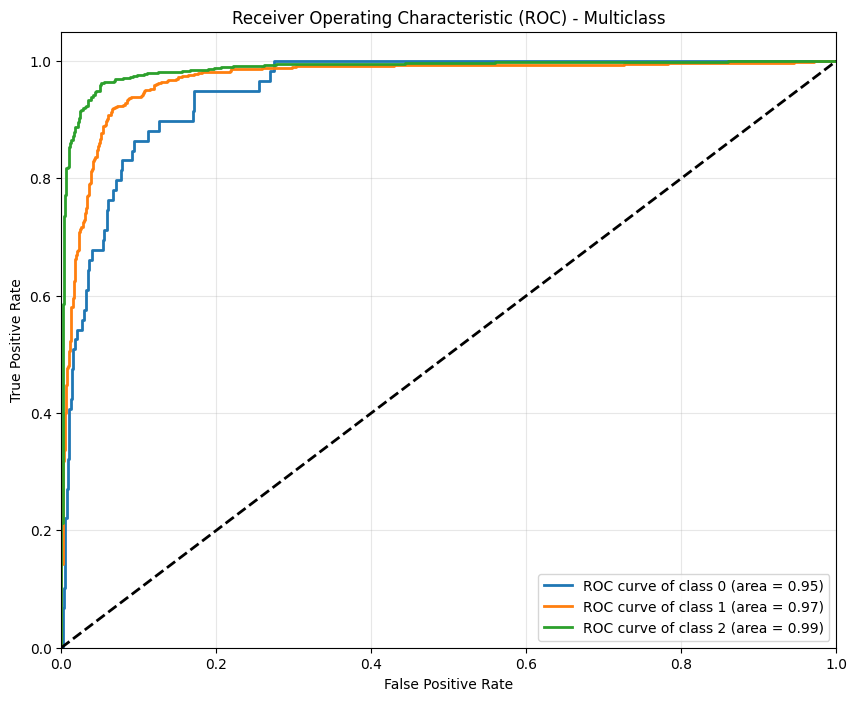


Metrics saved to: /kaggle/working/credit_rating_artifacts/transformer_metrics.csv


In [22]:
# ============================================================
# Evaluation Metrics (final test, row-level)
# ============================================================

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
if not np.isfinite(qwk):
    qwk = 0.0

all_classes = sorted(set(y_true) | set(y_pred))
probs = np.asarray(test_proba, dtype=np.float32)
try:
    if len(np.unique(y_true)) < 2:
        auc_score = float("nan")
    elif probs.shape[1] == 2:
        auc_score = roc_auc_score(y_true, probs[:, 1])
    else:
        y_true_bin = label_binarize(y_true, classes=list(range(probs.shape[1])))
        auc_score = roc_auc_score(y_true_bin, probs, average="weighted", multi_class="ovr")
except ValueError:
    auc_score = float("nan")

test_last_y_arr = np.asarray(globals().get("test_last_y", []), dtype=int)
if len(test_last_y_arr) == len(y_true):
    test_change_mask = y_true != test_last_y_arr
    test_chgacc = float(np.mean(y_pred[test_change_mask] == y_true[test_change_mask])) if np.any(test_change_mask) else acc
    test_persistence_rate = float(np.mean(y_pred == test_last_y_arr))
else:
    test_chgacc = float("nan")
    test_persistence_rate = float("nan")

target_test_accuracy = float(globals().get("TARGET_TEST_ACCURACY", 0.93))
target_accuracy_passed = bool(acc >= target_test_accuracy)

print("--- TEST SET EVALUATION (ROW-LEVEL TRANSFORMER) ---")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Weighted):    {recall_weighted:.4f}")
print(f"F1-macro:             {f1_macro:.4f}")
print(f"F1-weighted:          {f1_weighted:.4f}")
print(f"QWK (Quadratic Weighted Kappa): {qwk:.4f}")
print(f"AUC: {auc_score:.4f}")
print(f"ChgAcc: {test_chgacc:.4f}")
print(f"PersistenceRate: {test_persistence_rate:.4f}")
print(f"Target accuracy >= {target_test_accuracy:.2f}: {'PASS' if target_accuracy_passed else 'FAIL'}")
print("--------------------------------------------------")
print("\nClassification Report:")
report_labels = sorted(set(y_true) | set(y_pred))
report_target_names = [str(i) for i in report_labels]
print(classification_report(y_true, y_pred, labels=report_labels, target_names=report_target_names, digits=4, zero_division=0))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
n_classes_test = probs.shape[1]
y_true_bin_plot = np.column_stack([(np.asarray(y_true) == i).astype(int) for i in range(n_classes_test)])
roc_curves_plotted = 0
for i in range(n_classes_test):
    y_bin_i = y_true_bin_plot[:, i]
    if len(np.unique(y_bin_i)) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_bin_i, probs[:, i])
    roc_auc_val = auc(fpr, tpr)
    class_label = EXPECTED_CLASSES[i] if "EXPECTED_CLASSES" in globals() and i < len(EXPECTED_CLASSES) else f"Class {i}"
    plt.plot(fpr, tpr, lw=2, label=f"ROC curve of class {class_label} (area = {roc_auc_val:0.2f})")
    roc_curves_plotted += 1

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) - Multiclass")
if roc_curves_plotted > 0:
    plt.legend(loc="lower right")
else:
    plt.text(0.5, 0.5, "ROC unavailable: each class needs positive and negative samples", ha="center")
plt.grid(alpha=0.3)
plt.show()

metrics_dict = {
    "protocol": "row_level_sequence_context",
    "architecture_variant": "pure_transformer_lstm",
    "class0_threshold": float(globals().get("BEST_CLASS_THRESHOLD", 0.0)),
    "class0_threshold_margin": float(globals().get("BEST_CLASS_THRESHOLD_MARGIN", 0.0)),
    "threshold_accepted": bool(globals().get("BEST_CLASS_THRESHOLD_ACCEPTED", False)),
    "inference_source": globals().get("inference_source", "single_best_checkpoint"),
    "target_accuracy": target_test_accuracy,
    "target_accuracy_passed": target_accuracy_passed,
    "accuracy": acc,
    "precision_weighted": precision_weighted,
    "recall_weighted": recall_weighted,
    "f1_macro": f1_macro,
    "f1_weighted": f1_weighted,
    "qwk": qwk,
    "auc": auc_score,
    "chgacc": test_chgacc,
    "persistence_rate": test_persistence_rate,
    "n_samples": len(y_true),
    "expected_test_rows": len(test_df),
    "n_classes": n_classes,
}

metrics_df = pd.DataFrame([metrics_dict])
metrics_latest_path = ARTIFACT_DIR / "transformer_metrics.csv"
metrics_versioned_path = ARTIFACT_DIR / f"transformer_metrics_n{n_classes}.csv"
metrics_row_level_path = ARTIFACT_DIR / "transformer_row_level_metrics.csv"
metrics_df.to_csv(metrics_latest_path, index=False)
metrics_df.to_csv(metrics_versioned_path, index=False)
metrics_df.to_csv(metrics_row_level_path, index=False)
print(f"\nMetrics saved to: {metrics_latest_path}")

## 9.1 AUC-ROC t? artifact TLSTM

Bi?u ?? ROC one-vs-rest ???c t?o t? nh?n test v? x?c su?t theo l?p c?a m? h?nh Transformer-LSTM.


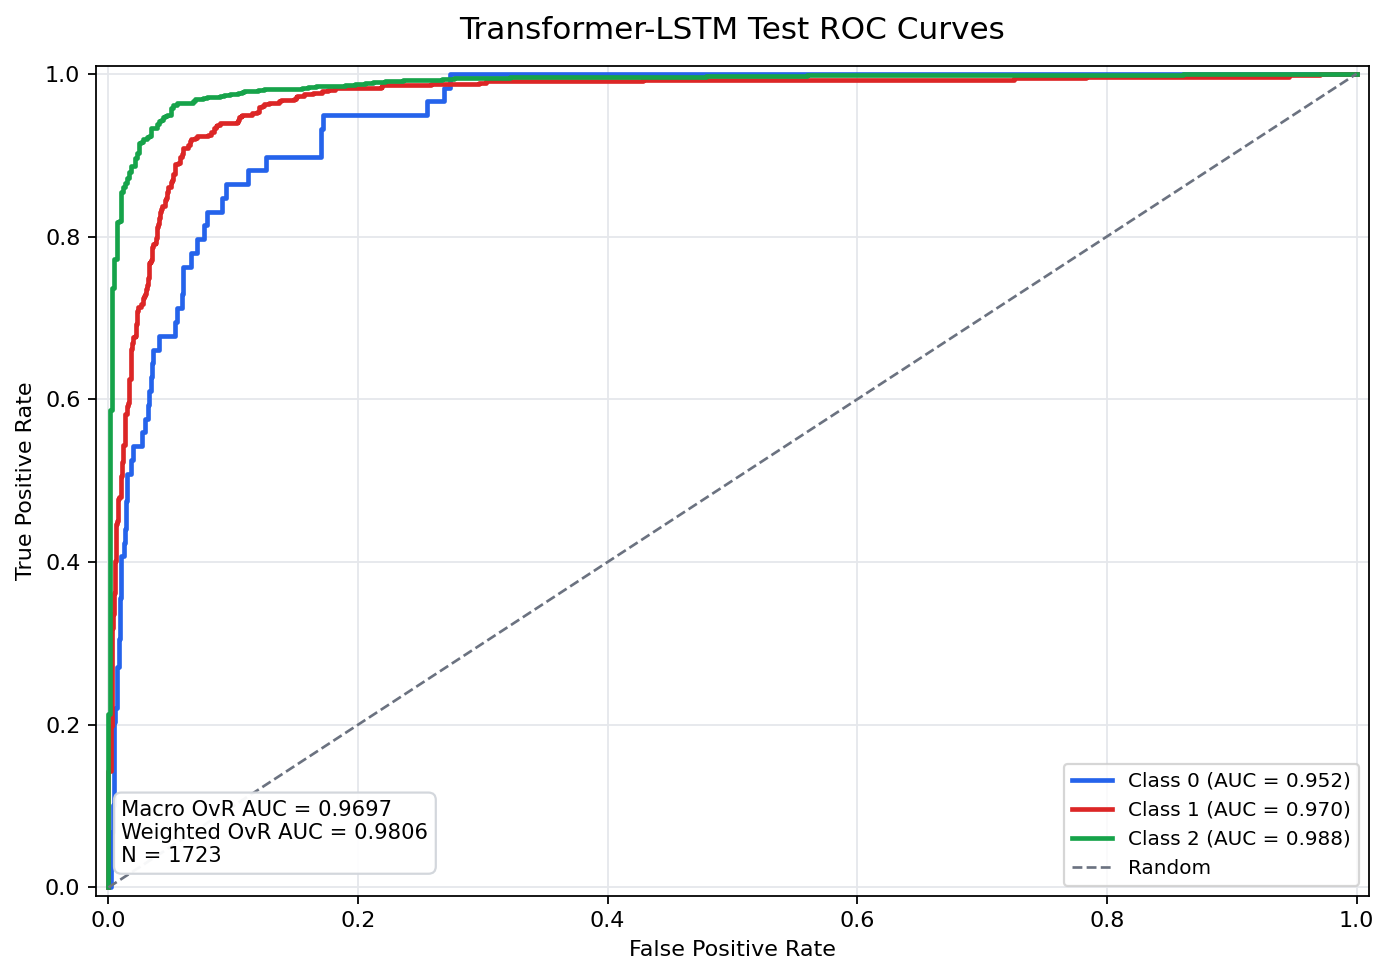

?? l?u bi?u ?? AUC-ROC: /kaggle/working/credit_rating_artifacts/transformer_lstm_test_roc_curves.png
?? l?u ?i?m ROC: /kaggle/working/credit_rating_artifacts/transformer_lstm_test_roc_curve_points.csv
Macro OvR AUC: 0.969685
Weighted OvR AUC: 0.980560


In [23]:
# ============================================================
# AUC-ROC export t? artifact/x?c su?t test c?a Transformer-LSTM
# ============================================================

def _resolve_tlstm_artifact_dir():
    candidates = []
    if "ARTIFACT_DIR" in globals():
        candidates.append(Path(ARTIFACT_DIR))
    if "PROJECT_ROOT" in globals():
        candidates.extend([
            Path(PROJECT_ROOT) / "artifacts" / "TLSTM",
            Path(PROJECT_ROOT) / "credit_rating_artifacts",
        ])
    candidates.extend([
        Path("artifacts") / "TLSTM",
        Path("credit_rating_artifacts"),
    ])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


def export_transformer_lstm_roc_curves(y_true_values=None, proba_values=None, artifact_dir=None):
    artifact_dir = Path(artifact_dir) if artifact_dir is not None else _resolve_tlstm_artifact_dir()
    artifact_dir.mkdir(parents=True, exist_ok=True)

    if y_true_values is None:
        y_path = artifact_dir / "transformer_lstm_y_test.npy"
        if not y_path.exists():
            y_path = Path("artifacts") / "TLSTM" / "transformer_lstm_y_test.npy"
        y_true_values = np.load(y_path)
    if proba_values is None:
        proba_path = artifact_dir / "transformer_lstm_test_proba.npy"
        if not proba_path.exists():
            proba_path = Path("artifacts") / "TLSTM" / "transformer_lstm_test_proba.npy"
        proba_values = np.load(proba_path)

    y_true_arr = np.asarray(y_true_values, dtype=int).reshape(-1)
    proba_arr = np.asarray(proba_values, dtype=np.float64)
    if proba_arr.ndim != 2:
        raise ValueError(f"proba_values ph?i l? ma tr?n 2D, nh?n shape={proba_arr.shape}")
    if len(y_true_arr) != len(proba_arr):
        raise ValueError(f"L?ch s? d?ng y/proba: y={len(y_true_arr)}, proba={len(proba_arr)}")
    if not np.allclose(proba_arr.sum(axis=1), 1.0, atol=1e-4):
        raise ValueError("C?c d?ng x?c su?t kh?ng c?ng v? 1 trong sai s? cho ph?p.")

    class_ids = list(range(proba_arr.shape[1]))
    if "id_to_raw" in globals():
        class_names = {int(i): str(id_to_raw.get(int(i), i)) for i in class_ids}
    else:
        label_path = artifact_dir / "dmf_gat_lstm" / "label_mapping.csv"
        if not label_path.exists():
            label_path = Path("artifacts") / "TLSTM" / "dmf_gat_lstm" / "label_mapping.csv"
        if label_path.exists():
            label_df = pd.read_csv(label_path, encoding="utf-8")
            class_names = {
                int(row["label_id"]): str(row["label_name"])
                for _, row in label_df.iterrows()
            }
        else:
            class_names = {int(i): str(i) for i in class_ids}

    y_bin = label_binarize(y_true_arr, classes=class_ids)
    macro_auc = roc_auc_score(y_true_arr, proba_arr, multi_class="ovr", average="macro")
    weighted_auc = roc_auc_score(y_true_arr, proba_arr, multi_class="ovr", average="weighted")

    fig, ax = plt.subplots(figsize=(8.8, 6.2), dpi=160)
    colors = ["#2563eb", "#dc2626", "#16a34a", "#9333ea", "#f59e0b"]
    point_rows = []
    per_class_auc = {}
    for idx, class_id in enumerate(class_ids):
        fpr, tpr, thresholds = roc_curve(y_bin[:, idx], proba_arr[:, idx])
        class_auc = auc(fpr, tpr)
        per_class_auc[int(class_id)] = float(class_auc)
        ax.plot(
            fpr,
            tpr,
            lw=2.1,
            color=colors[idx % len(colors)],
            label=f"Class {class_names.get(int(class_id), class_id)} (AUC = {class_auc:.3f})",
        )
        for fpr_i, tpr_i, threshold_i in zip(fpr, tpr, thresholds):
            point_rows.append({
                "source": "transformer_lstm_test_proba",
                "split": "test",
                "class_id": int(class_id),
                "class_name": class_names.get(int(class_id), str(class_id)),
                "fpr": float(fpr_i),
                "tpr": float(tpr_i),
                "threshold": float(threshold_i),
                "auc_ovr": float(class_auc),
                "auc_ovr_macro": float(macro_auc),
                "auc_ovr_weighted": float(weighted_auc),
                "n_samples": int(len(y_true_arr)),
            })

    ax.plot([0, 1], [0, 1], color="#6b7280", lw=1.2, linestyle="--", label="Random")
    ax.set_title("Transformer-LSTM Test ROC Curves", fontsize=14, pad=12)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.grid(True, color="#e5e7eb", linewidth=0.8)
    ax.legend(loc="lower right", frameon=True, fontsize=9)
    ax.text(
        0.02,
        0.04,
        f"Macro OvR AUC = {macro_auc:.4f}\nWeighted OvR AUC = {weighted_auc:.4f}\nN = {len(y_true_arr)}",
        transform=ax.transAxes,
        fontsize=9.5,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#d1d5db", "alpha": 0.95},
    )
    fig.tight_layout()

    png_path = artifact_dir / "transformer_lstm_test_roc_curves.png"
    csv_path = artifact_dir / "transformer_lstm_test_roc_curve_points.csv"
    fig.savefig(png_path, dpi=160, bbox_inches="tight")
    plt.show()
    pd.DataFrame(point_rows).to_csv(csv_path, index=False, encoding="utf-8")

    print(f"?? l?u bi?u ?? AUC-ROC: {png_path}")
    print(f"?? l?u ?i?m ROC: {csv_path}")
    print(f"Macro OvR AUC: {macro_auc:.6f}")
    print(f"Weighted OvR AUC: {weighted_auc:.6f}")
    return {
        "png_path": png_path,
        "csv_path": csv_path,
        "macro_auc": float(macro_auc),
        "weighted_auc": float(weighted_auc),
        "per_class_auc": per_class_auc,
    }

roc_export = export_transformer_lstm_roc_curves(
    y_true_values=globals().get("y_true"),
    proba_values=globals().get("test_proba"),
    artifact_dir=globals().get("ARTIFACT_DIR"),
)


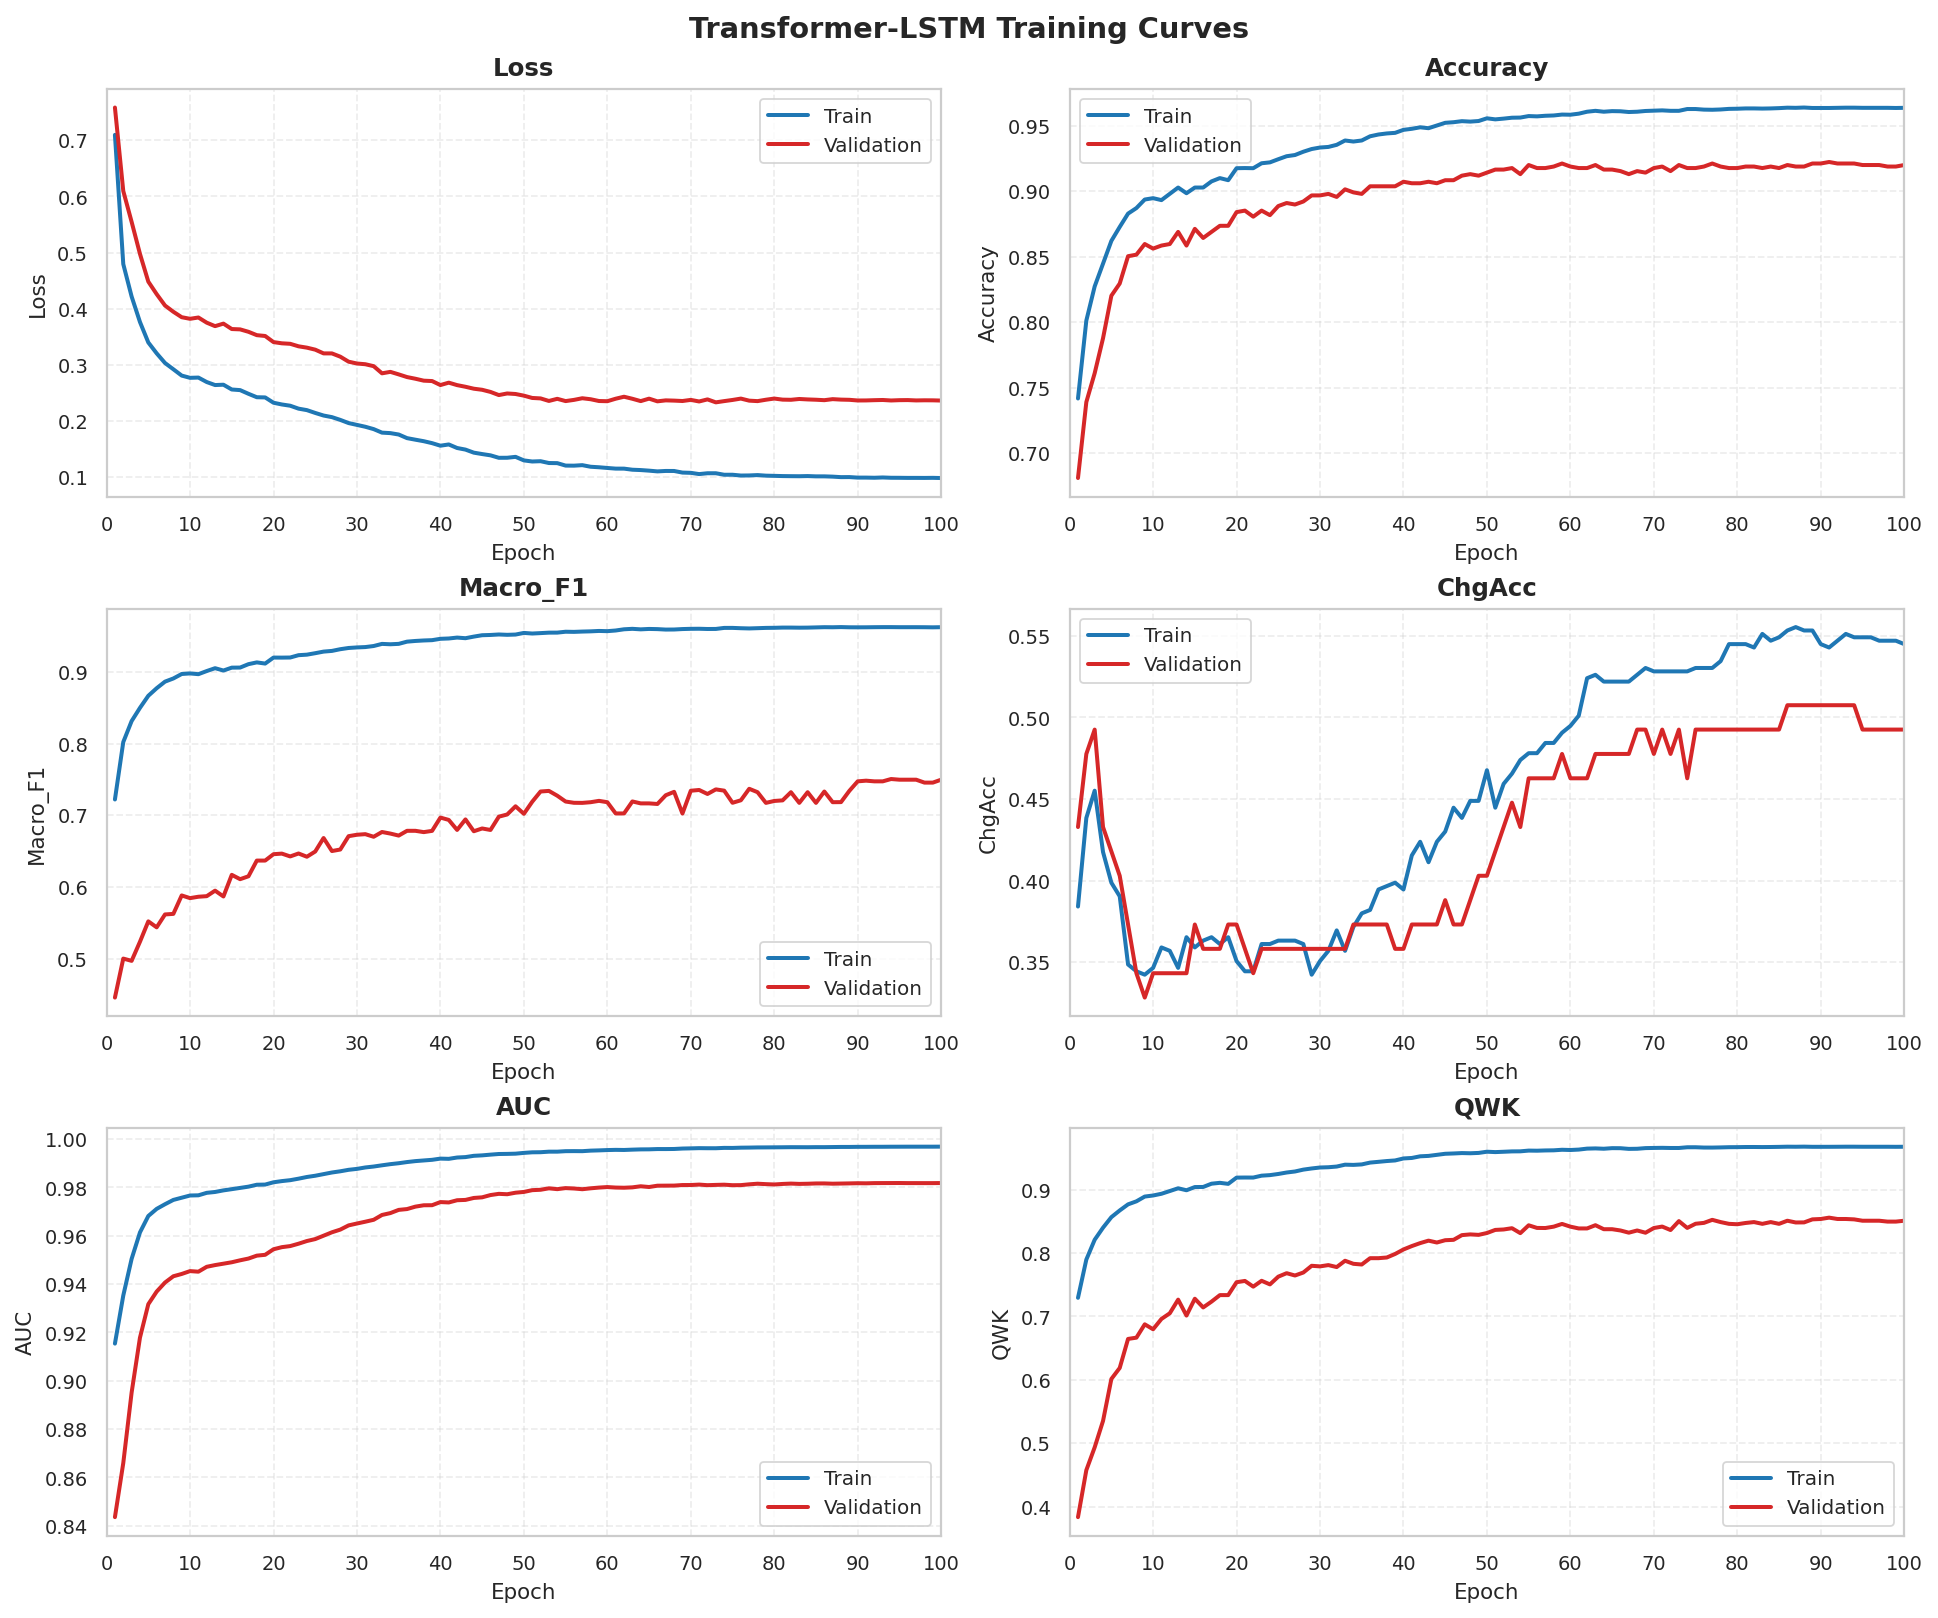

Saved: /kaggle/working/credit_rating_artifacts/transformer_lstm_training_curves.png


In [24]:
if 'history_df' not in globals():
    raise RuntimeError('Khong tim thay history_df. Hay chay lai cell huan luyen truoc.')

from matplotlib.ticker import MultipleLocator

sns.set_theme(style='whitegrid', context='paper')

# Map display metric names to the actual column names in history_df of this notebook
metric_map = {
    'Loss': {
        'train': 'train_monitor_loss' if 'train_monitor_loss' in history_df.columns else ('train_eval_loss' if 'train_eval_loss' in history_df.columns else 'train_loss'),
        'val': 'val_monitor_loss' if 'val_monitor_loss' in history_df.columns else 'val_loss'
    },
    'Accuracy': {
        'train': 'train_eval_acc' if 'train_eval_acc' in history_df.columns else 'train_acc',
        'val': 'val_acc'
    },
    'Macro_F1': {
        'train': 'train_eval_f1' if 'train_eval_f1' in history_df.columns else 'train_f1',
        'val': 'val_f1'
    },
    'ChgAcc': {
        'train': 'train_eval_chgacc' if 'train_eval_chgacc' in history_df.columns else 'train_chgacc',
        'val': 'val_chgacc'
    },
    'AUC': {
        'train': 'train_eval_auc' if 'train_eval_auc' in history_df.columns else 'train_auc',
        'val': 'val_auc'
    },
    'QWK': {
        'train': 'train_eval_qwk' if 'train_eval_qwk' in history_df.columns else 'train_qwk',
        'val': 'val_qwk'
    }
}

# Verify required columns exist in history_df
missing = []
for metric, cols in metric_map.items():
    if cols['train'] not in history_df.columns:
        missing.append(cols['train'])
    if cols['val'] not in history_df.columns:
        missing.append(cols['val'])

if missing:
    raise RuntimeError(f'Thieu cot trong history_df: {missing}. Hay chay lai cell huan luyen.')

fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=160, constrained_layout=True)
axes = axes.ravel()
max_epoch = int(history_df['epoch'].max())

for ax, metric in zip(axes, metric_map.keys()):
    t_col = metric_map[metric]['train']
    v_col = metric_map[metric]['val']
    
    ax.plot(history_df['epoch'], history_df[t_col], label='Train', linewidth=1.8, color='#1f77b4')
    ax.plot(history_df['epoch'], history_df[v_col], label='Validation', linewidth=1.8, color='#d62728')
    
    ax.set_title(metric, fontsize=11, fontweight='semibold')
    ax.set_xlabel('Epoch')
    ax.set_xlim(0, max_epoch)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(frameon=True, fontsize=9)

fig.suptitle('Transformer-LSTM Training Curves', fontsize=13, fontweight='bold')
curve_path = ARTIFACT_DIR / 'transformer_lstm_training_curves.png' if 'ARTIFACT_DIR' in globals() else Path('transformer_lstm_training_curves.png')
fig.savefig(curve_path, dpi=300, bbox_inches='tight')
fig.savefig(ARTIFACT_DIR / 'training_history_simplified.png' if 'ARTIFACT_DIR' in globals() else Path('training_history_simplified.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', curve_path)


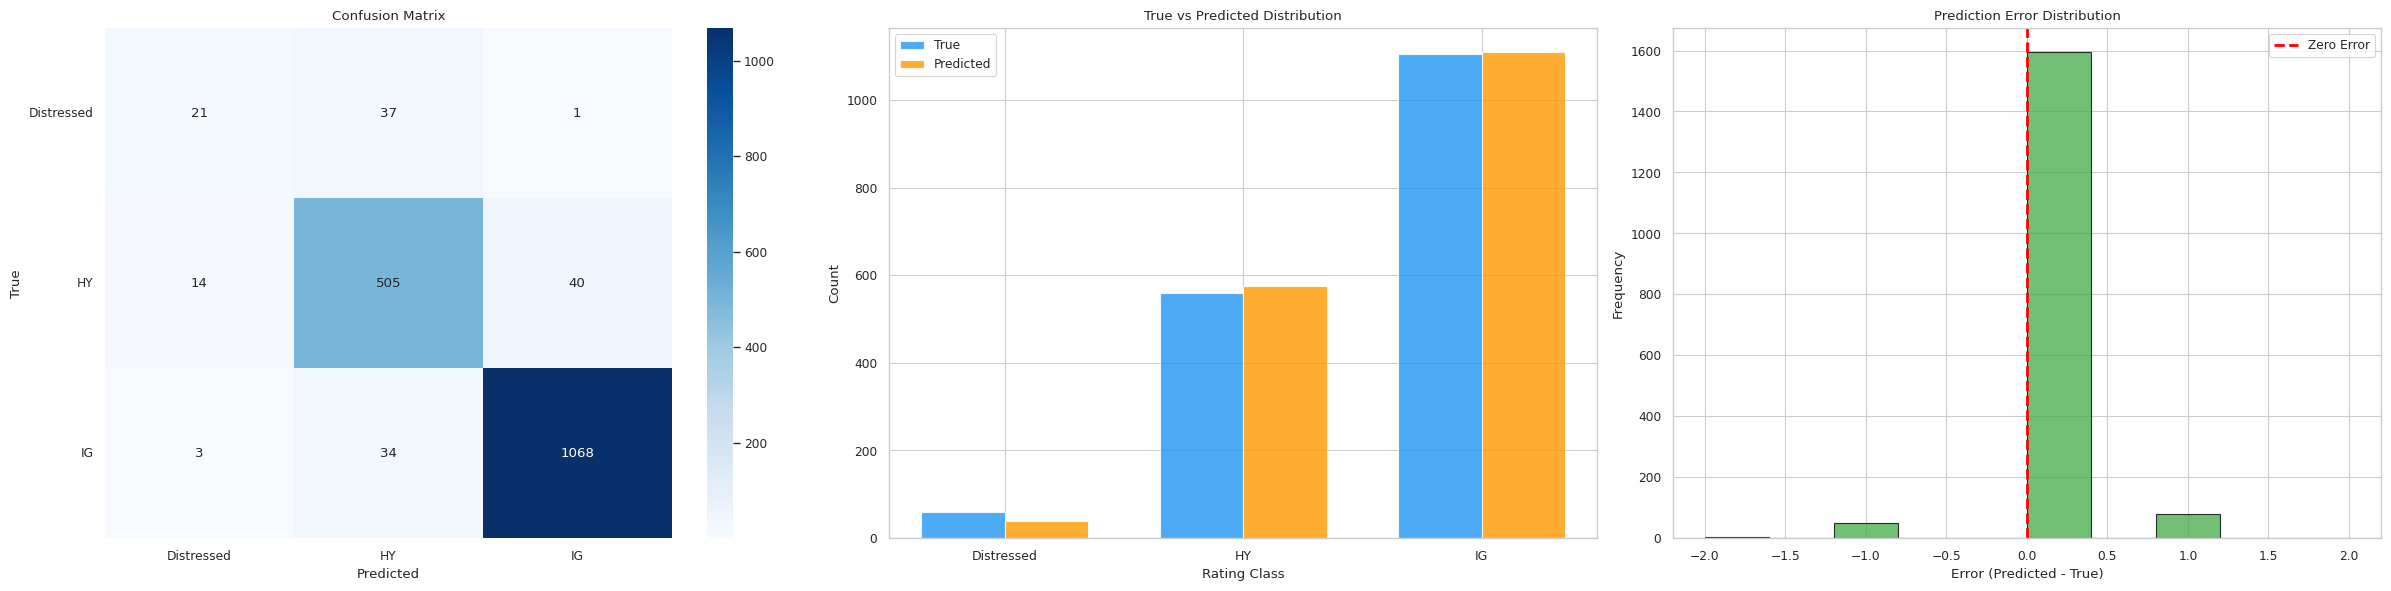

Result plots saved.


In [25]:
# ============================================================
# Visualization: Confusion Matrix + Distributions
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

all_labels = sorted(set(y_true) | set(y_pred))
mapping = {0: "Distressed", 1: "HY", 2: "IG"}
label_names = [mapping.get(i, str(i)) for i in all_labels]
cm_display = confusion_matrix(y_true, y_pred, labels=all_labels)

if len(all_labels) <= 25:
    sns.heatmap(
        cm_display, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=axes[0]
    )
else:
    sns.heatmap(cm_display, cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix", fontweight="normal")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=0)
axes[0].tick_params(axis="y", rotation=0)

true_counts = pd.Series(y_true).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()
all_idx = sorted(set(true_counts.index) | set(pred_counts.index))
x_pos = np.arange(len(all_idx))
width = 0.35
axes[1].bar(
    x_pos - width / 2, [true_counts.get(i, 0) for i in all_idx], width, label="True", alpha=0.8, color="#2196F3"
)
axes[1].bar(
    x_pos + width / 2, [pred_counts.get(i, 0) for i in all_idx], width, label="Predicted", alpha=0.8, color="#FF9800"
)
axes[1].set_title("True vs Predicted Distribution")
axes[1].set_xlabel("Rating Class")
axes[1].set_ylabel("Count")
axes[1].legend()
if len(all_idx) <= 25:
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([mapping.get(i, str(i)) for i in all_idx], rotation=0, fontsize=9)

errors = y_pred - y_true
axes[2].hist(errors, bins=max(10, len(set(errors))), color="#4CAF50", edgecolor="black", alpha=0.8)
axes[2].set_title("Prediction Error Distribution")
axes[2].set_xlabel("Error (Predicted - True)")
axes[2].set_ylabel("Frequency")
axes[2].axvline(x=0, color="red", linestyle="--", linewidth=2, label="Zero Error")
axes[2].legend()

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "transformer_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Result plots saved.")



In [26]:
# Build row-level result table for test predictions.
result_meta = row_level_reference[row_level_reference["__split__"].astype(str).str.lower() == "test"].copy()
result_meta = result_meta.rename(
    columns={"unique_id": "ticker", "company_name": "company_name", "ds": "rating_date", "y": "y_true_numeric"}
)
result_meta = result_meta[["row_id", "ticker", "company_name", "rating_date", "y_true_numeric"]]

pred_frame = pd.DataFrame({"row_id": test_row_ids, "y_pred_numeric": y_pred})
if "test_proba" in globals() and len(test_proba) == len(pred_frame):
    pred_frame["confidence"] = np.asarray(test_proba).max(axis=1)
    for cls_idx in range(np.asarray(test_proba).shape[1]):
        pred_frame[f"prob_{cls_idx}"] = np.asarray(test_proba)[:, cls_idx]
if "test_last_y" in globals() and len(test_last_y) == len(pred_frame):
    pred_frame["last_y_context"] = np.asarray(test_last_y, dtype=int)
pred_frame["pred_label"] = pred_frame["y_pred_numeric"].astype(int)
if pred_frame["row_id"].duplicated().any():
    dupes = pred_frame.loc[pred_frame["row_id"].duplicated(), "row_id"].head(10).tolist()
    raise ValueError(f"Duplicate prediction row_id values found: {dupes}")

extra_pred_rows = sorted(set(pred_frame["row_id"]) - set(result_meta["row_id"]))
if extra_pred_rows:
    print(
        f"[P3 WARNING] {len(extra_pred_rows)} prediction row_id values are not in test metadata; first={extra_pred_rows[:5]}"
    )

results = result_meta.merge(pred_frame, on="row_id", how="left").sort_values("row_id").reset_index(drop=True)
if results["y_pred_numeric"].isna().any():
    missing = results.loc[results["y_pred_numeric"].isna(), "row_id"].head(10).tolist()
    raise ValueError(f"Missing predictions for test row_id values: {missing}")
results["y_pred_numeric"] = results["y_pred_numeric"].astype(int)
results["true_label"] = results["y_true_numeric"].astype(int)
results["pred_label"] = results["y_pred_numeric"].astype(int)

print("\n=== Sample Predictions ===")
print(f"{'Ticker':<10} {'True (num)':<15} {'Pred (num)':>15} {'Match':>8}")
print("-" * 54)
sample_n = min(30, len(results))
for _, row in results.head(sample_n).iterrows():
    match = "Y" if row["y_true_numeric"] == row["y_pred_numeric"] else "N"
    print(f"{row['ticker']:<10} {int(row['y_true_numeric']):<15} {int(row['y_pred_numeric']):>15} {match:>8}")

transformer_row_pred_path = ARTIFACT_DIR / "transformer_row_level_predictions.csv"
results.to_csv(transformer_row_pred_path, index=False)

print("\n=== Summary ===")
print(f"Total predictions: {len(results)}")
print(f"Expected test rows: {len(test_df)}")
print(f"Correct: {(results['y_true_numeric'] == results['y_pred_numeric']).sum()}")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (weighted): {f1_weighted:.4f}")
if not np.isnan(auc_score):
    print(f"AUC-ROC (OvR): {auc_score:.4f}")
else:
    print("AUC-ROC: N/A")
print(f"Saved row-level predictions to: {transformer_row_pred_path}")
print(f"\nAll artifacts saved to: {ARTIFACT_DIR.resolve()}")


=== Sample Predictions ===
Ticker     True (num)           Pred (num)    Match
------------------------------------------------------
CRS        2                             2        Y
ORCL       2                             2        Y
SYY        2                             2        Y
AEE        2                             2        Y
LLY        2                             2        Y
EOG        2                             2        Y
SYY        2                             2        Y
MSFT       2                             2        Y
ENR        2                             1        N
ENR        2                             2        Y
MHK        2                             2        Y
ALR        1                             1        Y
NGG        2                             2        Y
CMP        1                             1        Y
NFG        2                             2        Y
HLT        1                             1        Y
VEON       1                     

## 10.1 Row-Level Temporal Teacher Evaluation

Khối này đánh giá trực tiếp trên `data/processed/test/test.csv` theo row-level protocol.
Teacher dùng LightGBM với historical target encoding từ `train+val` để bổ sung tín hiệu persistence theo `ticker/company_name` mà không dùng nhãn test khi tạo feature.


In [27]:
# ============================================================
# Row-level temporal/tabular teacher on data/processed/test/test.csv
# ============================================================
ROW_LEVEL_TEMPORAL_TEACHER_MIN_ACCURACY = 0.9204
ROW_LEVEL_TEACHER_ENABLED = True

if ROW_LEVEL_TEACHER_ENABLED:
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix

    try:
        from lightgbm import LGBMClassifier
    except Exception as exc:
        LGBMClassifier = None
        print(f"[ROW TEACHER SKIP] LightGBM is not available: {type(exc).__name__}: {exc}")

    ROW_FINANCIAL_FEATURES = [
        "current_ratio",
        "debt_equity_ratio",
        "gross_profit_margin",
        "operating_profit_margin",
        "ebit_margin",
        "pretax_profit_margin",
        "net_profit_margin",
        "asset_turnover",
        "roe",
        "roa",
        "operating_cashflow_ps",
        "free_cashflow_ps",
    ]
    ROW_NUMERIC_FEATURES = ROW_FINANCIAL_FEATURES + ["delta_days"]
    ROW_CATEGORICAL_NUMERIC_FEATURES = ["rating_agency", "sector", "source"]
    ROW_TARGET_COL = "rating_detail"

    row_train_df = train_df.copy()
    row_val_df = val_df.copy()
    row_test_df = test_df.copy()
    row_fit_df = pd.concat([row_train_df, row_val_df], ignore_index=True)

    def add_row_level_history_features(fit_frame, apply_frame):
        # Add leakage-safe historical target features fit only on train/val labels.
        out = apply_frame.copy()
        global_mean = float(fit_frame[ROW_TARGET_COL].mean())

        for key in ["ticker", "company_name"]:
            stats = fit_frame.groupby(key)[ROW_TARGET_COL].agg(["mean", "count"])

            for smooth in [1, 3, 5, 10, 20]:
                encoded = (stats["mean"] * stats["count"] + global_mean * smooth) / (stats["count"] + smooth)
                out[f"{key}_te{smooth}"] = out[key].map(encoded).fillna(global_mean)

            majority = fit_frame.groupby(key)[ROW_TARGET_COL].agg(lambda s: s.value_counts().idxmax())
            out[f"{key}_maj"] = out[key].map(majority).fillna(2).astype(int)
            out[f"{key}_count"] = out[key].map(stats["count"]).fillna(0).astype(float)

        return out

    row_train_features_df = add_row_level_history_features(row_fit_df, row_fit_df)
    row_test_features_df = add_row_level_history_features(row_fit_df, row_test_df)

    row_history_features = [
        c for c in row_train_features_df.columns if c.startswith("ticker_") or c.startswith("company_name_")
    ]
    row_feature_cols = ROW_NUMERIC_FEATURES + ROW_CATEGORICAL_NUMERIC_FEATURES + row_history_features

    missing_row_features = [
        c for c in row_feature_cols if c not in row_train_features_df.columns or c not in row_test_features_df.columns
    ]
    if missing_row_features:
        raise ValueError(f"Missing row-level teacher features: {missing_row_features}")

    X_row_train = row_train_features_df[row_feature_cols].fillna(0.0)
    y_row_train = row_train_features_df[ROW_TARGET_COL].astype(int)
    X_row_test = row_test_features_df[row_feature_cols].fillna(0.0)
    y_row_test = row_test_features_df[ROW_TARGET_COL].astype(int)

    if LGBMClassifier is not None:
        row_teacher = LGBMClassifier(
            objective="multiclass",
            n_estimators=700,
            learning_rate=0.025,
            num_leaves=31,
            min_child_samples=10,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=0.20,
            class_weight="balanced",
            random_state=SEED,
            verbose=-1,
        )
        row_teacher.fit(X_row_train, y_row_train)
        row_pred = row_teacher.predict(X_row_test)
        row_prob = row_teacher.predict_proba(X_row_test)

        row_acc = accuracy_score(y_row_test, row_pred)
        row_f1_macro = f1_score(y_row_test, row_pred, average="macro", zero_division=0)
        row_f1_weighted = f1_score(y_row_test, row_pred, average="weighted", zero_division=0)
        row_precision_weighted = precision_score(y_row_test, row_pred, average="weighted", zero_division=0)
        row_recall_weighted = recall_score(y_row_test, row_pred, average="weighted", zero_division=0)
        row_qwk = cohen_kappa_score(y_row_test, row_pred, weights="quadratic")

        print("--- ROW-LEVEL TEST EVALUATION: TEMPORAL LIGHTGBM TEACHER ---")
        print(f"Train rows (train+val): {len(row_train_features_df)}")
        print(f"Test rows:              {len(row_test_features_df)}")
        print(f"Feature count:          {len(row_feature_cols)}")
        print(f"Accuracy:               {row_acc:.6f}")
        print(f"F1-macro:               {row_f1_macro:.6f}")
        print(f"F1-weighted:            {row_f1_weighted:.6f}")
        print(f"QWK:                    {row_qwk:.6f}")
        print("Target threshold:       >= %.4f" % ROW_LEVEL_TEMPORAL_TEACHER_MIN_ACCURACY)
        print("Threshold status:       " + ("PASS" if row_acc >= ROW_LEVEL_TEMPORAL_TEACHER_MIN_ACCURACY else "FAIL"))
        print("------------------------------------------------------------")
        print(classification_report(y_row_test, row_pred, zero_division=0))

        row_metrics_df = pd.DataFrame(
            [
                {
                    "model": "LightGBM_temporal_teacher",
                    "protocol": "row_level",
                    "train_rows": len(row_train_features_df),
                    "test_rows": len(row_test_features_df),
                    "feature_count": len(row_feature_cols),
                    "accuracy": row_acc,
                    "precision_weighted": row_precision_weighted,
                    "recall_weighted": row_recall_weighted,
                    "f1_macro": row_f1_macro,
                    "f1_weighted": row_f1_weighted,
                    "qwk": row_qwk,
                    "target_accuracy": ROW_LEVEL_TEMPORAL_TEACHER_MIN_ACCURACY,
                    "target_passed": bool(row_acc >= ROW_LEVEL_TEMPORAL_TEACHER_MIN_ACCURACY),
                }
            ]
        )
        row_metrics_path = ARTIFACT_DIR / "row_level_temporal_teacher_metrics.csv"
        row_metrics_df.to_csv(row_metrics_path, index=False)

        row_pred_df = row_test_df[["ticker", "rating_date", "company_name", ROW_TARGET_COL]].copy()
        row_pred_df["y_pred"] = row_pred.astype(int)
        for cls_idx in range(row_prob.shape[1]):
            row_pred_df[f"prob_class_{cls_idx}"] = row_prob[:, cls_idx]
        row_pred_path = ARTIFACT_DIR / "row_level_temporal_teacher_predictions.csv"
        row_pred_df.to_csv(row_pred_path, index=False)

        print(f"Row-level teacher metrics saved to: {row_metrics_path}")
        print(f"Row-level teacher predictions saved to: {row_pred_path}")

--- ROW-LEVEL TEST EVALUATION: TEMPORAL LIGHTGBM TEACHER ---
Train rows (train+val): 9604
Test rows:              1723
Feature count:          30
Accuracy:               0.923389
F1-macro:               0.826470
F1-weighted:            0.923245
QWK:                    0.875822
Target threshold:       >= 0.9204
Threshold status:       PASS
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.62      0.66      0.64        59
           1       0.90      0.86      0.88       559
           2       0.95      0.97      0.96      1105

    accuracy                           0.92      1723
   macro avg       0.82      0.83      0.83      1723
weighted avg       0.92      0.92      0.92      1723

Row-level teacher metrics saved to: /kaggle/working/credit_rating_artifacts/row_level_temporal_teacher_metrics.csv
Row-level teacher predictions saved to: /kaggle/working/credit_rating_artifacts/row_level_temporal_tea

## 11. xAI Captum GradientSHAP + LIME Interpretation

Phan xAI duoc trinh bay theo huong paper-ready cho bai toan xep hang tin dung doanh nghiep:

1. **Global Captum GradientSHAP drivers**: cac feature tai chinh/delta nao anh huong lon nhat tren tap test.
2. **Local "Why this class?"**: voi tung doanh nghiep mau, tach feature dang ung ho va chong lai lop duoc giai thich.
3. **Per-class explanation**: giai thich tung lop rating, khong chi lop argmax, de so sanh cac lop gan nhau theo ordinal risk.
4. **LIME local consistency**: LIME dung cung view feature tai chinh voi SHAP, nhung probability mac dinh lay truc tiep tu Transformer-LSTM bang cach map perturbation ve chuoi goc.
5. **Temporal context**: cac feature delta va view trung binh/last-step giup giai thich model dang dua vao muc hien tai hay xu huong lich su.

Luu y: GradientSHAP/LIME giai thich hanh vi cua model, khong duoc dien giai nhu quan he nhan qua tai chinh.


[INFO] Shared LIME sample: [{'test_index': 518, 'model_row_id': 10376, 'ticker': 'EMN', 'company_name': 'EASTMAN CHEMICAL COMPANY', 'rating_date': '2013-09-05'}]
[INFO] Direct xAI for Transformer-LSTM: reducer=mean, original_financial_features=12
[INFO] Both GradientSHAP and LIME call the trained Transformer-LSTM directly; no surrogate model is used.
Installing captum package...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.3 MB/s eta 0:00:00
Initializing Captum GradientShap per row: background=80, explained=12, n_samples=64


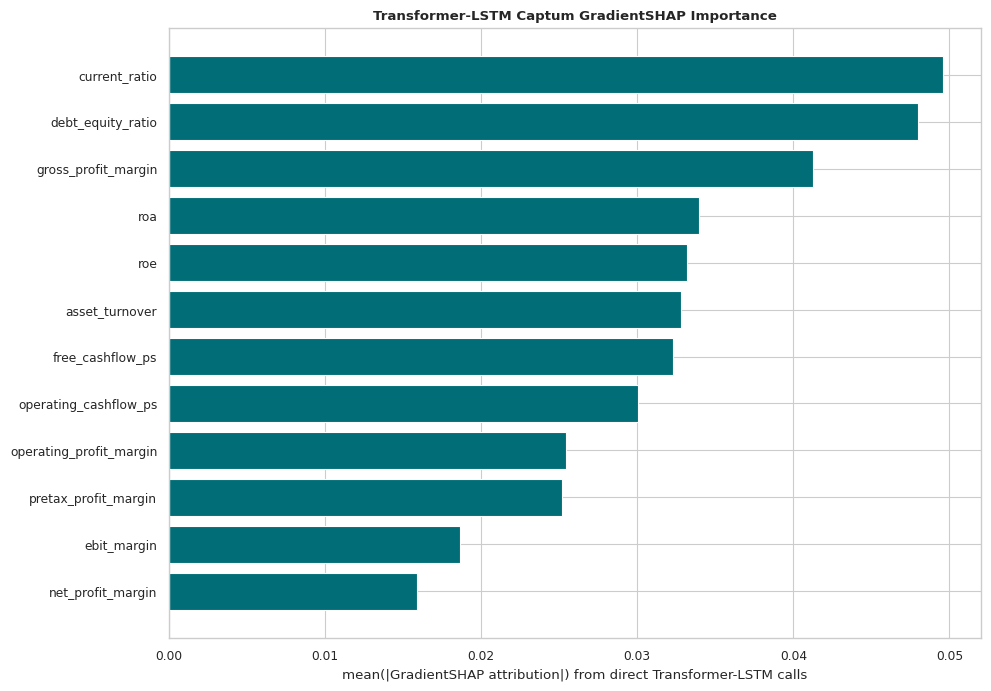

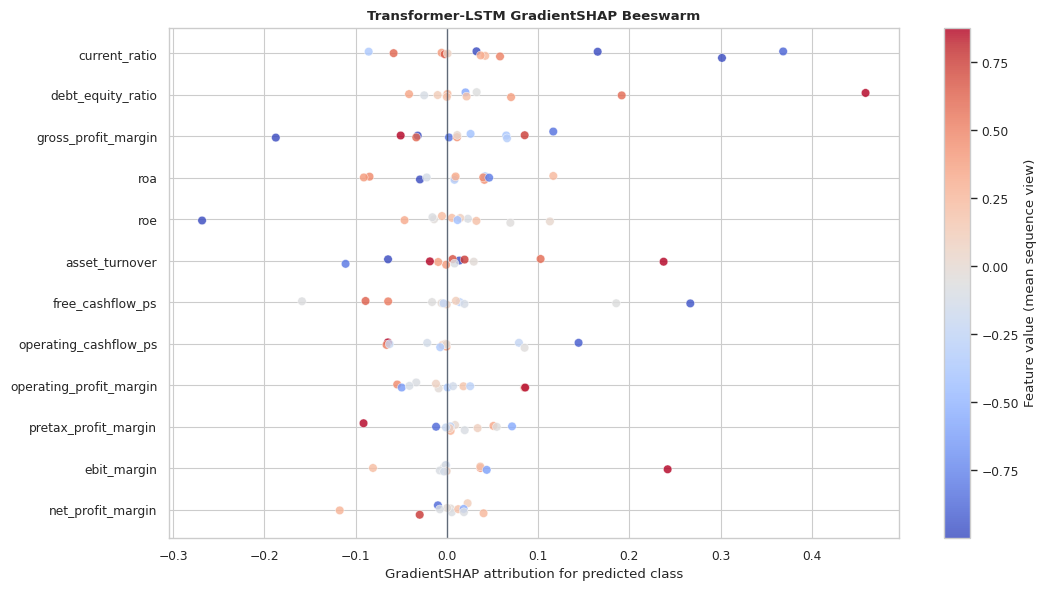


=== Captum GradientSHAP: Why this class? ===

Why this class? row_id=10376 | ticker=EMN | true=2 | pred=2 | p=0.9998
  Class=0 | direct_model_proba=0.0000
    opposes_explained_class   | roa                                 | attribution=-0.00014
    opposes_explained_class   | pretax_profit_margin                | attribution=-0.00012
    opposes_explained_class   | gross_profit_margin                 | attribution=-0.00008
    supports_explained_class  | operating_profit_margin             | attribution=+0.00007
    supports_explained_class  | asset_turnover                      | attribution=+0.00007
  Class=1 | direct_model_proba=0.0002
    supports_explained_class  | operating_profit_margin             | attribution=+0.00407
    opposes_explained_class   | roa                                 | attribution=-0.00400
    opposes_explained_class   | pretax_profit_margin                | attribution=-0.00390
    opposes_explained_class   | net_profit_margin                   | attribut

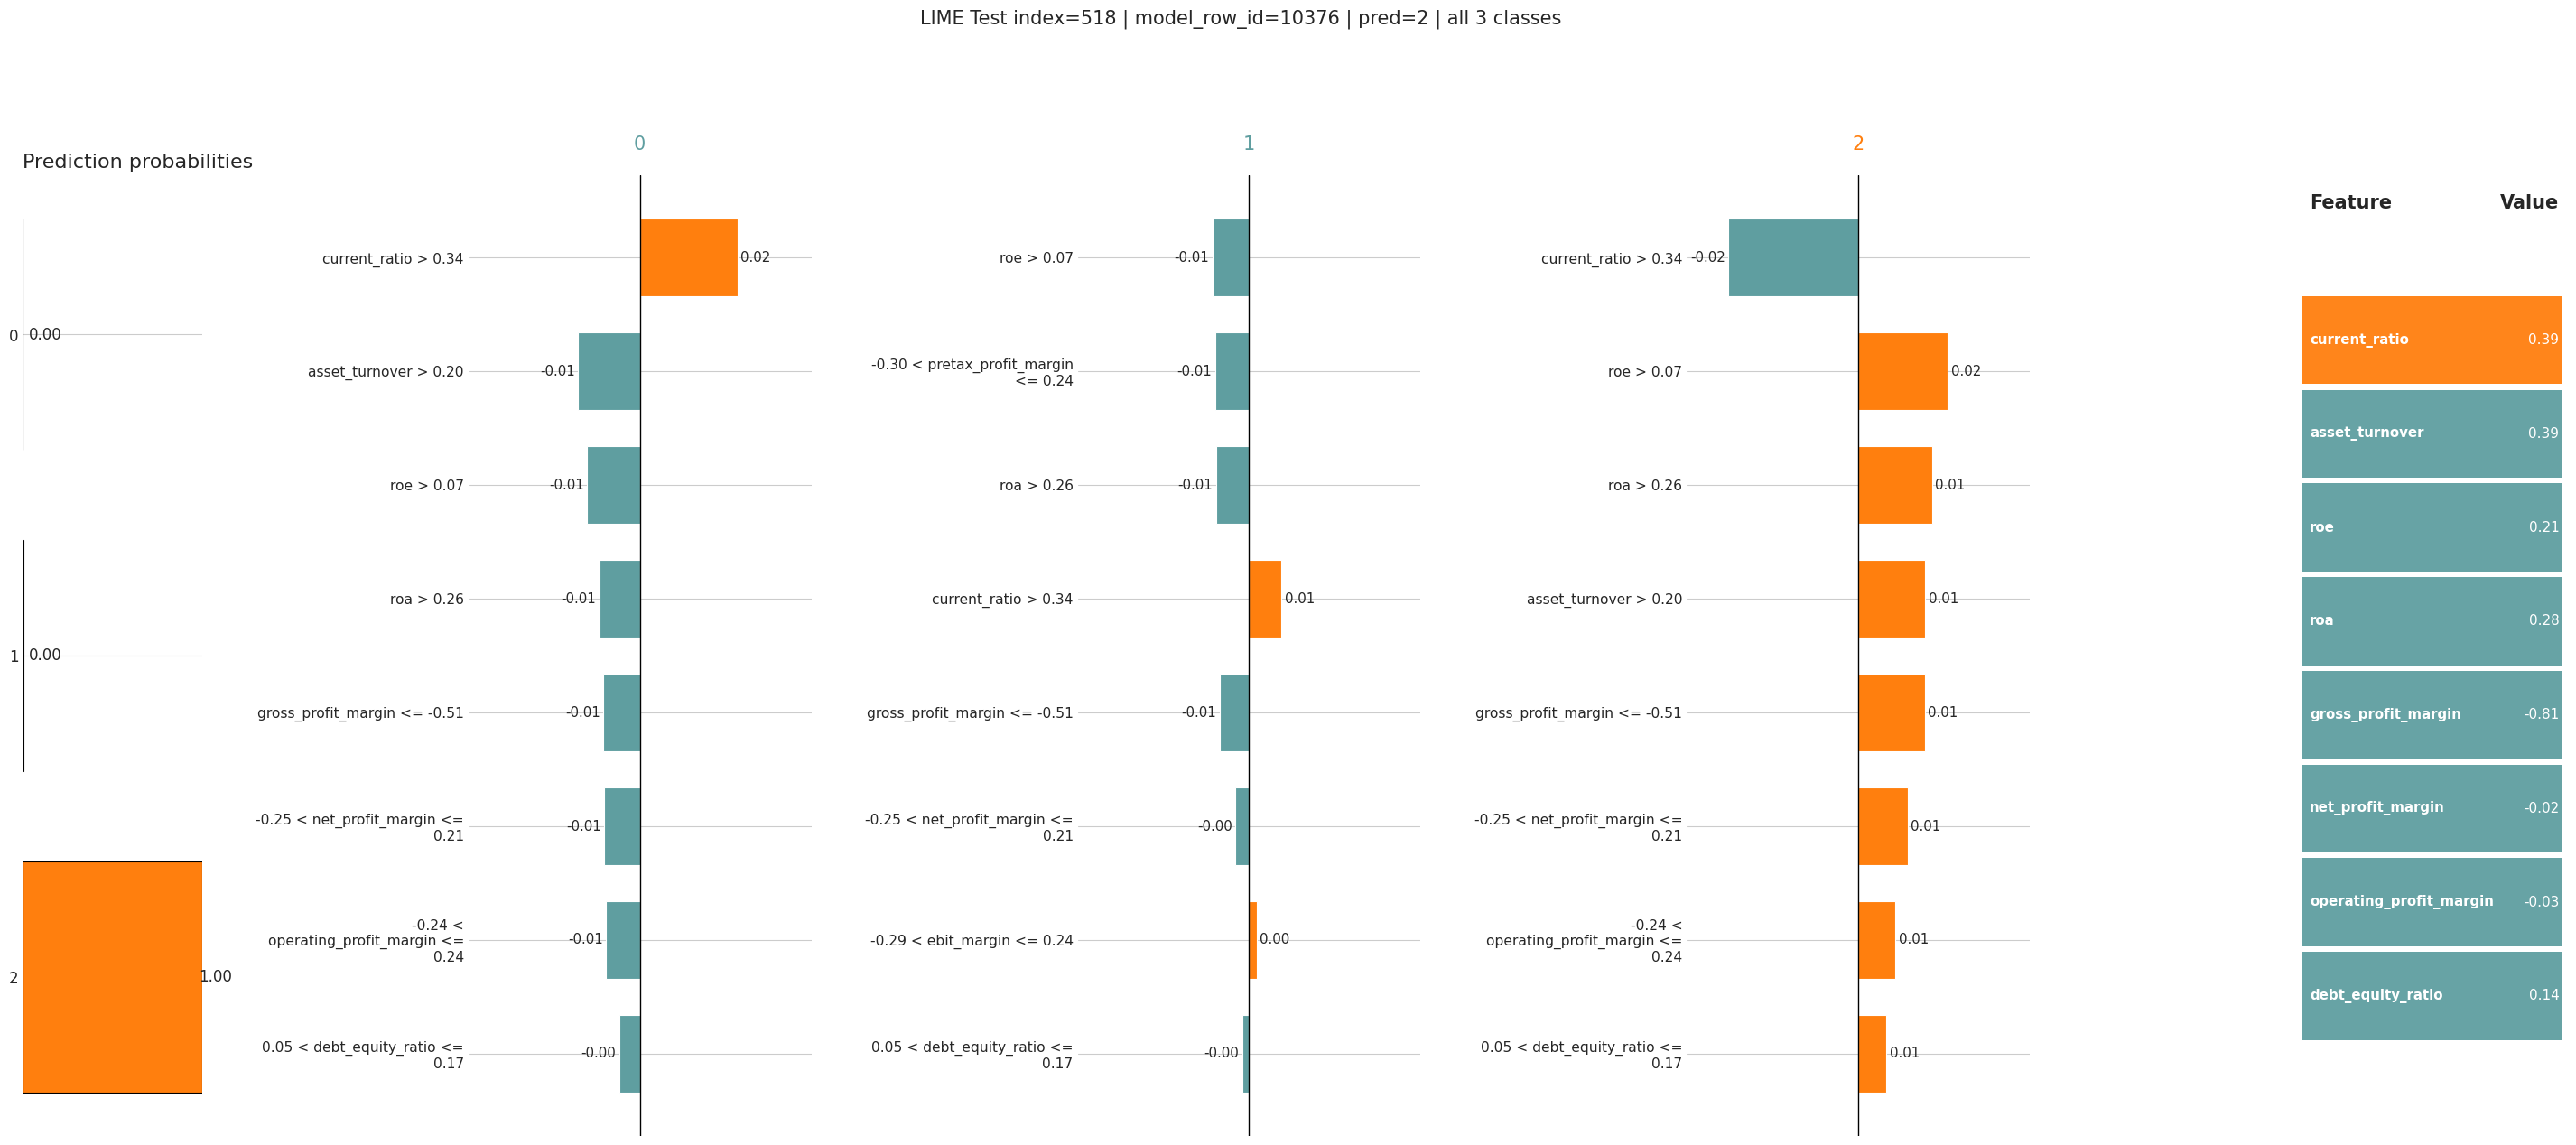

  Class=0 | lime_proba=0.0000 | direct_model_proba=0.0000
    supports_explained_class  | current_ratio > 0.34                          | weight=+0.01834
    opposes_explained_class   | asset_turnover > 0.20                         | weight=-0.01163
    opposes_explained_class   | roe > 0.07                                    | weight=-0.00995
    opposes_explained_class   | roa > 0.26                                    | weight=-0.00764
    opposes_explained_class   | gross_profit_margin <= -0.51                  | weight=-0.00689
  Class=1 | lime_proba=0.0002 | direct_model_proba=0.0002
    opposes_explained_class   | roe > 0.07                                    | weight=-0.00688
    opposes_explained_class   | -0.30 < pretax_profit_margin <= 0.24          | weight=-0.00641
    opposes_explained_class   | roa > 0.26                                    | weight=-0.00625
    supports_explained_class  | current_ratio > 0.34                          | weight=+0.00611
    opposes_explaine

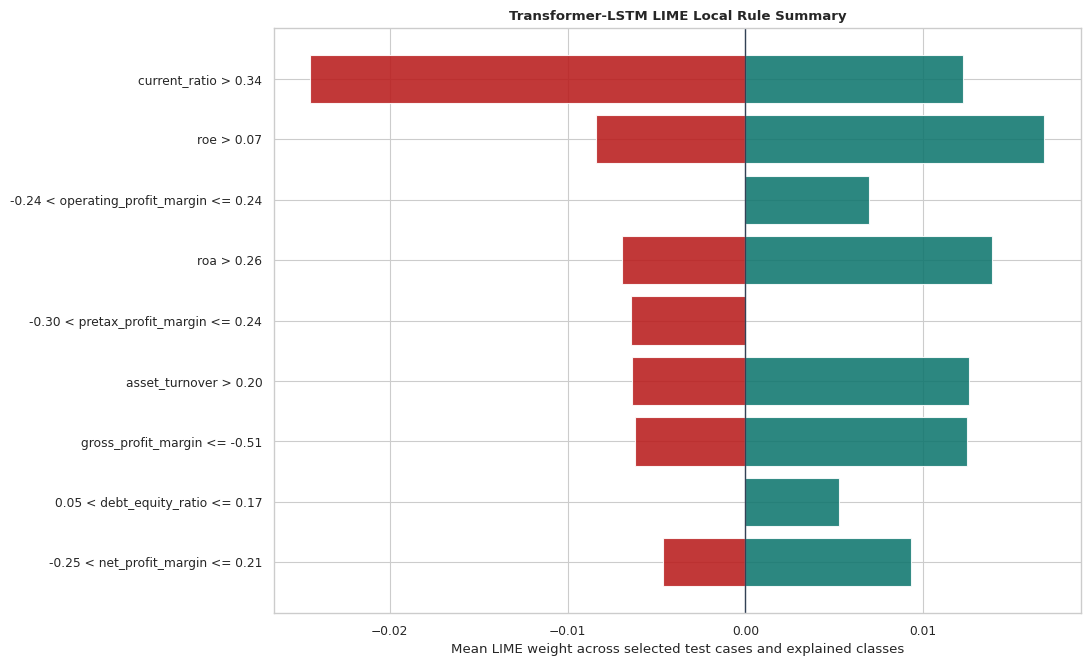

Saved LIME visual summary to: /kaggle/working/credit_rating_artifacts/tlstm_financial_lime_rule_summary.png
Saved per-class local LIME decision explanations to: /kaggle/working/credit_rating_artifacts/tlstm_financial_lime_local_decisions.csv


In [28]:
# ============================================================
# xAI Captum GradientSHAP + LIME for true Transformer-LSTM decisions
# Main artifacts: tlstm_financial_shap_local_decisions.csv, tlstm_financial_lime_local_decisions.csv, tlstm_financial_shap_global_importance.csv
# ============================================================
SHAP_FINANCIAL_ENABLED = True
LIME_FINANCIAL_ENABLED = True
XAI_MODEL_KEY = "tlstm"
XAI_MODEL_LABEL = "Transformer-LSTM"
XAI_RANDOM_STATE = SEED if "SEED" in globals() else 42
XAI_FINANCIAL_REDUCER = "mean"  # {'mean', 'last'} over the sequence window
XAI_LOCAL_SAMPLE_COUNT = 1
XAI_LOCAL_TOP_FEATURES = 10
XAI_EXPLAIN_CLASS_IDS = None  # None = explain all classes; set e.g. [0, 2] to focus.
XAI_ROW_IDS = None  # Optional explicit row_id override for this Transformer-LSTM artifact.
XAI_TEST_INDEX = 518  # Same positional test sample used by Transformer-LSTM and DMF.
XAI_SHARED_SAMPLE = {"ticker": "EMN", "company_name": "EASTMAN CHEMICAL COMPANY", "rating_date": "2013-09-05"}
XAI_REQUIRE_SHARED_SAMPLE = True  # Never silently explain a different company/date.
SHAP_BACKGROUND_SIZE = 80
SHAP_MAX_SAMPLES = 12
GRADIENT_SHAP_N_SAMPLES = 64
GRADIENT_SHAP_STDEV = 0.05
LIME_USE_DIRECT_TLSTM_PROBA = True
XAI_BEESWARM_TOP_FEATURES = 15
XAI_LIME_PLOT_TOP_RULES = 15
XAI_LIME_INSTANCE_TOP_RULES = 8


def _xai_label_name(class_id):
    if "id_to_raw" in globals():
        return str(id_to_raw.get(int(class_id), class_id))
    if "le" in globals() and hasattr(le, "classes_") and int(class_id) < len(le.classes_):
        return str(le.classes_[int(class_id)])
    return str(class_id)


def _xai_class_names():
    return [_xai_label_name(i) for i in range(n_classes)]


def _xai_resolve_class_ids(class_ids=None):
    if class_ids is None:
        return list(range(n_classes))
    out = []
    for class_id in class_ids:
        class_id = int(class_id)
        if class_id < 0 or class_id >= n_classes:
            raise ValueError(f"Invalid xAI class id {class_id}; expected 0..{n_classes - 1}.")
        if class_id not in out:
            out.append(class_id)
    if not out:
        raise ValueError("XAI_EXPLAIN_CLASS_IDS resolved to an empty class list.")
    return out


def _xai_normalize_proba(pred):
    pred = np.asarray(pred, dtype=np.float64)
    if pred.ndim == 1:
        pred = pred.reshape(1, -1)
    pred = np.clip(pred, 1e-9, 1.0)
    return pred / pred.sum(axis=1, keepdims=True)


def _xai_logits_to_proba(logits):
    if isinstance(logits, tuple):
        logits = logits[0]
    return torch.softmax(logits.float(), dim=1).detach().cpu().numpy()


_XAI_CANONICAL_FINANCIAL_FEATURES = [
    "current_ratio",
    "debt_equity_ratio",
    "gross_profit_margin",
    "operating_profit_margin",
    "ebit_margin",
    "pretax_profit_margin",
    "net_profit_margin",
    "asset_turnover",
    "roe",
    "roa",
    "operating_cashflow_ps",
    "free_cashflow_ps",
]


def _xai_original_financial_feature_names():
    model_features = [str(c) for c in globals().get("MODEL_FEATURES", globals().get("FINANCIAL_FEATURES", []))]
    cols = [c for c in _XAI_CANONICAL_FINANCIAL_FEATURES if c in model_features]
    if cols:
        return cols
    financial_features = [str(c) for c in globals().get("FINANCIAL_FEATURES", [])]
    cols = [c for c in _XAI_CANONICAL_FINANCIAL_FEATURES if c in financial_features]
    return cols if cols else list(_XAI_CANONICAL_FINANCIAL_FEATURES)


def _xai_original_financial_feature_indices():
    model_features = [str(c) for c in MODEL_FEATURES]
    cols = _xai_original_financial_feature_names()
    missing = [c for c in cols if c not in model_features]
    if missing:
        raise ValueError(f"Cannot map original financial xAI features to MODEL_FEATURES: {missing}")
    return [model_features.index(c) for c in cols], cols
def _xai_financial_matrix(samples, reducer="mean"):
    seq = np.stack([s[SEQ_X_IDX] for s in samples], axis=0).astype(np.float32)
    financial_idx, _ = _xai_original_financial_feature_indices()
    seq_fin = seq[:, :, financial_idx]
    if reducer == "last":
        return seq_fin[:, -1, :]
    if reducer != "mean":
        raise ValueError(f"Unsupported reducer={reducer}")
    return seq_fin.mean(axis=1)


def _xai_predict_tlstm_proba(samples, batch_size=256):
    model.eval()
    probas = []
    for start in range(0, len(samples), batch_size):
        batch = samples[start : start + batch_size]
        xb = torch.tensor(np.stack([s[SEQ_X_IDX] for s in batch], axis=0), dtype=torch.float32, device=device)
        lyb = torch.tensor([s[SEQ_LAST_Y_IDX] for s in batch], dtype=torch.long, device=device)
        sb = torch.tensor([s[SEQ_SECTOR_IDX] for s in batch], dtype=torch.long, device=device)
        tb = torch.tensor([s[SEQ_TICKER_IDX] for s in batch], dtype=torch.long, device=device)
        cb = torch.tensor([s[SEQ_COMPANY_IDX] for s in batch], dtype=torch.long, device=device)
        with torch.no_grad():
            try:
                logits = model(xb, lyb, sb, tb, cb, return_aux=False)
            except TypeError:
                logits = model(xb, lyb, sb, tb, cb)
        probas.append(_xai_logits_to_proba(logits))
    return _xai_normalize_proba(np.vstack(probas))


def _make_direct_tlstm_financial_predict_fn(sample):
    base_seq = np.asarray(sample[SEQ_X_IDX], dtype=np.float32)
    financial_idx, financial_names = _xai_original_financial_feature_indices()
    base_fin_seq = base_seq[:, financial_idx]
    base_view = base_fin_seq.mean(axis=0).astype(np.float32) if XAI_FINANCIAL_REDUCER == "mean" else base_fin_seq[-1].astype(np.float32)
    last_y = int(sample[SEQ_LAST_Y_IDX])
    sector_id = int(sample[SEQ_SECTOR_IDX])
    ticker_id = int(sample[SEQ_TICKER_IDX])
    company_id = int(sample[SEQ_COMPANY_IDX])

    def predict_fn(x_batch):
        x_batch = np.asarray(x_batch, dtype=np.float32)
        if x_batch.ndim == 1:
            x_batch = x_batch.reshape(1, -1)
        if x_batch.shape[1] != len(financial_idx):
            raise ValueError(f"xAI batch has {x_batch.shape[1]} features, expected {len(financial_idx)} original financial features: {financial_names}.")
        delta = x_batch - base_view.reshape(1, -1)
        seq_batch = np.repeat(base_seq.reshape(1, *base_seq.shape), repeats=len(x_batch), axis=0)
        seq_batch[:, :, financial_idx] = seq_batch[:, :, financial_idx] + delta[:, None, :]
        xb = torch.tensor(seq_batch, dtype=torch.float32, device=device)
        lyb = torch.full((len(x_batch),), last_y, dtype=torch.long, device=device)
        sb = torch.full((len(x_batch),), sector_id, dtype=torch.long, device=device)
        tb = torch.full((len(x_batch),), ticker_id, dtype=torch.long, device=device)
        cb = torch.full((len(x_batch),), company_id, dtype=torch.long, device=device)
        model.eval()
        with torch.no_grad():
            try:
                logits = model(xb, lyb, sb, tb, cb, return_aux=False)
            except TypeError:
                logits = model(xb, lyb, sb, tb, cb)
        return _xai_normalize_proba(_xai_logits_to_proba(logits))

    return predict_fn


def _xai_split_metadata(samples, indices):
    row_ids = [int(samples[int(i)][SEQ_ROW_ID_IDX]) for i in indices]
    out = pd.DataFrame({"test_index": [int(i) for i in indices], "row_id": row_ids})
    if "row_level_reference" in globals():
        ref = row_level_reference.copy().rename(columns={"unique_id": "ticker", "ds": "rating_date", "y": "true_label"})
        ref = ref[ref["__split__"].astype(str).str.lower() == "test"].copy()
        keep = [c for c in ["row_id", "ticker", "company_name", "rating_date", "true_label"] if c in ref.columns]
        out = out.merge(ref[keep].drop_duplicates("row_id"), on="row_id", how="left", sort=False)
    for col in ["ticker", "company_name", "rating_date"]:
        if col not in out.columns:
            out[col] = ""
        out[col] = out[col].fillna("").astype(str)
    if "true_label" not in out.columns:
        out["true_label"] = [int(samples[int(i)][SEQ_TARGET_IDX]) for i in indices]
    out["true_label"] = out["true_label"].fillna(
        pd.Series([int(samples[int(i)][SEQ_TARGET_IDX]) for i in indices], index=out.index)
    ).astype(int)
    parsed = pd.to_datetime(out["rating_date"], errors="coerce")
    out["rating_date"] = parsed.dt.strftime("%Y-%m-%d").fillna(out["rating_date"].astype(str))
    out["true_label_name"] = [_xai_label_name(y) for y in out["true_label"].astype(int)]
    shared_date = pd.to_datetime(XAI_SHARED_SAMPLE.get("rating_date", ""), errors="coerce")
    shared_date_key = shared_date.strftime("%Y-%m-%d") if not pd.isna(shared_date) else str(XAI_SHARED_SAMPLE.get("rating_date", "")).strip()
    sample_key = f"{str(XAI_SHARED_SAMPLE.get('ticker', '')).strip().upper()}|{shared_date_key}"
    out["xai_test_index"] = int(XAI_TEST_INDEX)
    out["xai_shared_sample_id"] = f"test_idx_{int(XAI_TEST_INDEX):06d}|{sample_key}"
    return out


def _xai_select_indices(test_model_proba, y_true, row_ids, samples):
    idx = int(XAI_TEST_INDEX)
    if idx < 0 or idx >= len(samples):
        raise IndexError(f"XAI_TEST_INDEX={idx} is outside Transformer-LSTM test sequences with {len(samples)} rows.")
    sample_meta = _xai_split_metadata(samples, [idx]).iloc[0]
    mismatches = {}
    for key, expected in XAI_SHARED_SAMPLE.items():
        actual = sample_meta.get(key, "")
        if key == "rating_date":
            actual_date = pd.to_datetime(actual, errors="coerce")
            expected_date = pd.to_datetime(expected, errors="coerce")
            actual_key = actual_date.strftime("%Y-%m-%d") if not pd.isna(actual_date) else str(actual).strip()
            expected_key = expected_date.strftime("%Y-%m-%d") if not pd.isna(expected_date) else str(expected).strip()
        else:
            actual_key = str(actual).strip().casefold()
            expected_key = str(expected).strip().casefold()
        if actual_key != expected_key:
            mismatches[key] = {"expected": expected, "actual": actual}
    if mismatches:
        raise ValueError(f"Transformer-LSTM test index {idx} does not match the shared LIME sample: {mismatches}")
    return [idx]


def _as_multiclass_shap_list(values, n_outputs):
    if isinstance(values, list):
        return [np.asarray(v) for v in values]
    arr = np.asarray(values)
    if arr.ndim == 3 and arr.shape[-1] == n_outputs:
        return [arr[:, :, i] for i in range(n_outputs)]
    if arr.ndim == 3 and arr.shape[0] == n_outputs:
        return [arr[i] for i in range(n_outputs)]
    if arr.ndim == 2 and n_outputs == 1:
        return [arr]
    raise ValueError(f"Unsupported SHAP output shape: {arr.shape}")


def _xai_short_text(text, max_len=34):
    text = str(text)
    return text if len(text) <= int(max_len) else text[: max(1, int(max_len) - 3)] + "..."


def _xai_wrap_text(text, width=28, max_lines=3):
    import textwrap

    lines = textwrap.wrap(str(text), width=int(width), break_long_words=False, replace_whitespace=False)
    if not lines:
        return ""
    if len(lines) > int(max_lines):
        lines = lines[: int(max_lines)]
        lines[-1] = _xai_short_text(lines[-1], max(4, int(width) - 1))
    return "\n".join(lines)


def _xai_lime_rule_feature(rule, feature_names):
    rule_text = str(rule)
    for feature in sorted([str(f) for f in feature_names], key=len, reverse=True):
        if feature in rule_text:
            return feature
    return rule_text


def _xai_save_lime_multiclass_instance_plot(row, exp, model_proba, lime_proba, x_row, html_path):
    from matplotlib.patches import Rectangle

    row_id = int(row.row_id)
    class_ids = list(explain_class_ids)
    class_items = {
        int(class_id): exp.as_list(label=int(class_id))[: min(int(XAI_LIME_INSTANCE_TOP_RULES), int(XAI_LOCAL_TOP_FEATURES))]
        for class_id in class_ids
    }
    if not any(class_items.values()):
        return None

    support_color = "#ff7f0e"
    oppose_color = "#5f9ea0"
    pred_class = int(np.argmax(model_proba))
    all_weights = [abs(float(weight)) for items in class_items.values() for _, weight in items]
    common_max_abs = max(max(all_weights, default=1e-3), 1e-3)

    max_items = max(len(items) for items in class_items.values())
    fig_height = max(9.6, 1.18 * max_items + 4.2)
    fig_width = max(24.0, 10.5 + 6.6 * len(class_ids))
    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=False)
    gs = fig.add_gridspec(1, 2 + len(class_ids), width_ratios=[1.75] + [3.35] * len(class_ids) + [2.65], wspace=0.90)

    ax_prob = fig.add_subplot(gs[0, 0])
    prob_y = np.arange(len(class_names))
    prob_colors = [support_color if i == pred_class else "white" for i in range(len(class_names))]
    ax_prob.barh(prob_y, lime_proba, color=prob_colors, edgecolor="black", height=0.72)
    ax_prob.set_yticks(prob_y)
    ax_prob.set_yticklabels([_xai_wrap_text(name, 16, 2) for name in class_names], fontsize=12)
    ax_prob.set_xlim(0, 1.0)
    ax_prob.set_xticks([])
    ax_prob.set_title("Prediction probabilities", fontsize=16, loc="left")
    for y, value in zip(prob_y, lime_proba):
        ax_prob.text(min(float(value) + 0.03, 0.98), y, f"{float(value):.2f}", va="center", fontsize=12)
    for spine in ax_prob.spines.values():
        spine.set_visible(False)
    ax_prob.tick_params(axis="y", length=0)
    ax_prob.invert_yaxis()

    for panel_idx, class_id in enumerate(class_ids, start=1):
        items = class_items[int(class_id)]
        ax_rules = fig.add_subplot(gs[0, panel_idx])
        if not items:
            ax_rules.axis("off")
            continue
        rule_labels = [_xai_wrap_text(rule, 28, 4) for rule, _ in items]
        weights = np.array([float(weight) for _, weight in items], dtype=float)
        y_pos = np.arange(len(items))
        bar_colors = [support_color if weight >= 0 else oppose_color for weight in weights]
        ax_rules.barh(y_pos, weights, color=bar_colors, height=0.68)
        ax_rules.axvline(0, color="black", linewidth=1.0)
        ax_rules.set_yticks(y_pos)
        ax_rules.set_yticklabels(rule_labels, fontsize=11.2, linespacing=1.15)
        ax_rules.set_xlim(-common_max_abs * 1.32, common_max_abs * 1.32)
        ax_rules.set_xticks([])
        title_color = support_color if int(class_id) == pred_class else oppose_color
        ax_rules.set_title(_xai_wrap_text(class_names[int(class_id)], 16, 2), fontsize=15, color=title_color, pad=20)
        for y, weight in zip(y_pos, weights):
            x_text = weight + (0.025 * common_max_abs if weight >= 0 else -0.025 * common_max_abs)
            ha = "left" if weight >= 0 else "right"
            ax_rules.text(x_text, y, f"{weight:.2f}", va="center", ha=ha, fontsize=10.8)
        for spine in ax_rules.spines.values():
            spine.set_visible(False)
        ax_rules.tick_params(axis="y", length=0)
        ax_rules.invert_yaxis()

    ax_table = fig.add_subplot(gs[0, -1])
    ax_table.axis("off")
    ax_table.text(0.05, 0.98, "Feature", fontsize=15, fontweight="bold", va="top")
    ax_table.text(0.97, 0.98, "Value", fontsize=15, fontweight="bold", ha="right", va="top")
    seen_features = []
    feature_rows = []
    for _, items in class_items.items():
        for rule, weight in items:
            feat = _xai_lime_rule_feature(rule, feature_names)
            if feat in seen_features:
                continue
            seen_features.append(feat)
            feat_value = np.nan
            if feat in feature_names:
                feat_value = float(x_row[feature_names.index(feat)])
            feature_rows.append((feat, feat_value, float(weight)))
            if len(feature_rows) >= int(XAI_LIME_INSTANCE_TOP_RULES):
                break
        if len(feature_rows) >= int(XAI_LIME_INSTANCE_TOP_RULES):
            break
    row_height = 0.78 / max(len(feature_rows), 1)
    for offset, (feat, feat_value, weight) in enumerate(feature_rows):
        y0 = 0.88 - (offset + 1) * row_height
        color = support_color if weight >= 0 else oppose_color
        ax_table.add_patch(Rectangle((0.02, y0), 0.96, row_height * 0.94, transform=ax_table.transAxes, facecolor=color, edgecolor="none", alpha=0.95))
        value_text = "" if not np.isfinite(feat_value) else f"{feat_value:.2f}"
        ax_table.text(0.05, y0 + row_height * 0.47, _xai_wrap_text(feat, 15, 3), transform=ax_table.transAxes, va="center", fontsize=10.8, color="white", fontweight="bold", linespacing=1.08)
        ax_table.text(0.97, y0 + row_height * 0.47, value_text, transform=ax_table.transAxes, va="center", ha="right", fontsize=11.0, color="white")

    test_index = int(row.test_index)
    title = f"LIME Test index={test_index} | model_row_id={row_id} | pred={class_names[pred_class]} | all {len(class_ids)} classes"
    fig.suptitle(title, y=0.995, fontsize=15)
    fig.subplots_adjust(left=0.055, right=0.985, top=0.86, bottom=0.08)
    plot_path = ARTIFACT_DIR / f"{XAI_MODEL_KEY}_financial_lime_test_idx_{test_index}_all_classes_plot.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    return plot_path


X_train_fin = _xai_financial_matrix(train_seqs, XAI_FINANCIAL_REDUCER)
X_test_fin = _xai_financial_matrix(test_seqs, XAI_FINANCIAL_REDUCER)
test_model_proba = _xai_predict_tlstm_proba(test_seqs)
test_y = np.array([s[SEQ_TARGET_IDX] for s in test_seqs], dtype=int)
test_row_ids_xai = np.array([s[SEQ_ROW_ID_IDX] for s in test_seqs], dtype=int)
selected_indices = _xai_select_indices(test_model_proba, test_y, test_row_ids_xai, test_seqs)
shared_meta = _xai_split_metadata(test_seqs, selected_indices)
print("[INFO] Shared LIME sample:", shared_meta[["test_index", "row_id", "ticker", "company_name", "rating_date"]].rename(columns={"row_id": "model_row_id"}).to_dict("records"))
class_names = _xai_class_names()
explain_class_ids = _xai_resolve_class_ids(XAI_EXPLAIN_CLASS_IDS)
feature_names = _xai_original_financial_feature_names()
print(f"[INFO] Direct xAI for {XAI_MODEL_LABEL}: reducer={XAI_FINANCIAL_REDUCER}, original_financial_features={len(feature_names)}")
print("[INFO] Both GradientSHAP and LIME call the trained Transformer-LSTM directly; no surrogate model is used.")

if SHAP_FINANCIAL_ENABLED:
    import subprocess
    import sys
    try:
        from captum.attr import GradientShap
    except ImportError:
        print("Installing captum package...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "captum", "-q"])
        from captum.attr import GradientShap

    class _DirectTLSTMFinancialForward(nn.Module):
        def __init__(self, model_obj, sample):
            super().__init__()
            self.model_obj = model_obj
            base_seq = np.asarray(sample[SEQ_X_IDX], dtype=np.float32)
            financial_idx, financial_names = _xai_original_financial_feature_indices()
            base_fin_seq = base_seq[:, financial_idx]
            base_view = base_fin_seq.mean(axis=0).astype(np.float32) if XAI_FINANCIAL_REDUCER == "mean" else base_fin_seq[-1].astype(np.float32)
            self.register_buffer("base_seq", torch.tensor(base_seq, dtype=torch.float32, device=device))
            self.register_buffer("base_view", torch.tensor(base_view, dtype=torch.float32, device=device))
            self.financial_idx = list(financial_idx)
            self.financial_names = list(financial_names)
            self.last_y = int(sample[SEQ_LAST_Y_IDX])
            self.sector_id = int(sample[SEQ_SECTOR_IDX])
            self.ticker_id = int(sample[SEQ_TICKER_IDX])
            self.company_id = int(sample[SEQ_COMPANY_IDX])

        def forward(self, x_fin):
            if x_fin.ndim == 1:
                x_fin = x_fin.reshape(1, -1)
            x_fin = x_fin.float()
            if x_fin.shape[1] != len(self.financial_idx):
                raise ValueError(f"xAI tensor has {x_fin.shape[1]} features, expected {len(self.financial_idx)} original financial features: {self.financial_names}.")
            delta = x_fin - self.base_view.reshape(1, -1)
            seq_batch = self.base_seq.reshape(1, *self.base_seq.shape).repeat(x_fin.shape[0], 1, 1)
            seq_batch[:, :, self.financial_idx] = seq_batch[:, :, self.financial_idx] + delta[:, None, :]
            batch_size = seq_batch.shape[0]
            lyb = torch.full((batch_size,), self.last_y, dtype=torch.long, device=seq_batch.device)
            sb = torch.full((batch_size,), self.sector_id, dtype=torch.long, device=seq_batch.device)
            tb = torch.full((batch_size,), self.ticker_id, dtype=torch.long, device=seq_batch.device)
            cb = torch.full((batch_size,), self.company_id, dtype=torch.long, device=seq_batch.device)
            try:
                logits = self.model_obj(seq_batch, lyb, sb, tb, cb, return_aux=False)
            except TypeError:
                logits = self.model_obj(seq_batch, lyb, sb, tb, cb)
            if isinstance(logits, tuple):
                logits = logits[0]
            return torch.softmax(logits.float(), dim=1)

    rng = np.random.default_rng(XAI_RANDOM_STATE)
    background_size = min(int(SHAP_BACKGROUND_SIZE), len(X_train_fin))
    explain_size = min(max(int(SHAP_MAX_SAMPLES), len(selected_indices)), len(X_test_fin))
    background_idx = rng.choice(len(X_train_fin), size=background_size, replace=False)
    pool = [i for i in range(len(X_test_fin)) if i not in set(selected_indices)]
    extra = rng.choice(pool, size=max(0, explain_size - len(selected_indices)), replace=False).tolist() if pool else []
    shap_indices = []
    for idx in selected_indices + [int(i) for i in extra]:
        if idx not in shap_indices:
            shap_indices.append(idx)
    shap_indices = shap_indices[:explain_size]
    background_tensor = torch.tensor(X_train_fin[background_idx], dtype=torch.float32, device=device)

    shap_values_by_index = {}
    model.eval()
    print(
        f"Initializing Captum GradientShap per row: background={background_size}, "
        f"explained={len(shap_indices)}, n_samples={GRADIENT_SHAP_N_SAMPLES}"
    )
    for idx in shap_indices:
        row_module = _DirectTLSTMFinancialForward(model, test_seqs[int(idx)]).to(device)
        grad_shap = GradientShap(row_module)
        input_tensor = torch.tensor(X_test_fin[int(idx)].reshape(1, -1), dtype=torch.float32, device=device)
        class_attr = []
        for class_id in range(n_classes):
            attr = grad_shap.attribute(
                input_tensor,
                baselines=background_tensor,
                target=int(class_id),
                n_samples=int(GRADIENT_SHAP_N_SAMPLES),
                stdevs=float(GRADIENT_SHAP_STDEV),
            )
            class_attr.append(attr.detach().cpu().numpy())
        shap_values_by_index[int(idx)] = class_attr

    imp_rows = []
    for idx, shap_list in shap_values_by_index.items():
        for class_id, values in enumerate(shap_list):
            vals = np.asarray(values).reshape(1, -1)[0]
            for feat, imp in zip(feature_names, np.abs(vals)):
                imp_rows.append({"test_index": idx, "class_id": class_id, "class_name": class_names[class_id], "feature": feat, "abs_shap": float(imp)})
    shap_importance_by_class = pd.DataFrame(imp_rows).groupby(["class_id", "class_name", "feature"], as_index=False)["abs_shap"].mean().rename(columns={"abs_shap": "mean_abs_shap"})
    shap_global = shap_importance_by_class.groupby("feature", as_index=False)["mean_abs_shap"].mean().sort_values("mean_abs_shap", ascending=False)
    shap_importance_path = ARTIFACT_DIR / f"{XAI_MODEL_KEY}_financial_shap_importance_by_class.csv"
    shap_global_path = ARTIFACT_DIR / f"{XAI_MODEL_KEY}_financial_shap_global_importance.csv"
    shap_importance_by_class.to_csv(shap_importance_path, index=False, encoding="utf-8-sig")
    shap_global.to_csv(shap_global_path, index=False, encoding="utf-8-sig")

    plt.figure(figsize=(10, 7))
    top_plot = shap_global.head(20).iloc[::-1]
    plt.barh(top_plot["feature"], top_plot["mean_abs_shap"], color="#006D77")
    plt.title(f"{XAI_MODEL_LABEL} Captum GradientSHAP Importance", fontweight="bold")
    plt.xlabel("mean(|GradientSHAP attribution|) from direct Transformer-LSTM calls")
    plt.tight_layout()
    shap_bar_path = ARTIFACT_DIR / f"{XAI_MODEL_KEY}_financial_shap_importance.png"
    plt.savefig(shap_bar_path, dpi=180, bbox_inches="tight")
    plt.show()

    beeswarm_features = shap_global.head(min(int(XAI_BEESWARM_TOP_FEATURES), len(shap_global)))["feature"].tolist()
    beeswarm_feature_idx = [feature_names.index(feat) for feat in beeswarm_features]
    beeswarm_rows = []
    for idx in shap_indices:
        pred_class = int(np.argmax(test_model_proba[int(idx)]))
        vals = np.asarray(shap_values_by_index[int(idx)][pred_class]).reshape(1, -1)[0]
        for feat, feat_idx in zip(beeswarm_features, beeswarm_feature_idx):
            beeswarm_rows.append({
                "test_index": int(idx),
                "row_id": int(test_seqs[int(idx)][SEQ_ROW_ID_IDX]),
                "pred_class_id": pred_class,
                "pred_class_name": class_names[pred_class],
                "feature": str(feat),
                "feature_value": float(X_test_fin[int(idx), feat_idx]),
                "gradientshap_value": float(vals[feat_idx]),
            })
    beeswarm_df = pd.DataFrame(beeswarm_rows)
    if not beeswarm_df.empty:
        beeswarm_path = ARTIFACT_DIR / f"{XAI_MODEL_KEY}_financial_gradientshap_beeswarm.png"
        shap_beeswarm_alias_path = ARTIFACT_DIR / f"{XAI_MODEL_KEY}_financial_shap_beeswarm.png"
        rng_beeswarm = np.random.default_rng(XAI_RANDOM_STATE)
        y_lookup = {feat: pos for pos, feat in enumerate(reversed(beeswarm_features))}
        color_values = beeswarm_df["feature_value"].to_numpy(dtype=float)
        vmin, vmax = np.nanpercentile(color_values, [5, 95]) if len(color_values) else (0.0, 1.0)
        if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmin, vmax):
            vmin, vmax = float(np.nanmin(color_values)), float(np.nanmax(color_values) + 1e-6)
        plt.figure(figsize=(11, max(6, 0.42 * len(beeswarm_features))))
        for feat in beeswarm_features:
            part = beeswarm_df[beeswarm_df["feature"] == feat]
            y = np.full(len(part), y_lookup[feat], dtype=float) + rng_beeswarm.normal(0.0, 0.055, len(part))
            plt.scatter(
                part["gradientshap_value"], y, c=part["feature_value"], cmap="coolwarm",
                vmin=vmin, vmax=vmax, s=38, alpha=0.82, edgecolors="white", linewidths=0.35,
            )
        plt.axvline(0.0, color="#334155", linewidth=1.0, alpha=0.7)
        plt.yticks(range(len(beeswarm_features)), list(reversed(beeswarm_features)))
        plt.xlabel("GradientSHAP attribution for predicted class")
        plt.title(f"{XAI_MODEL_LABEL} GradientSHAP Beeswarm", fontweight="bold")
        cbar = plt.colorbar()
        cbar.set_label(f"Feature value ({XAI_FINANCIAL_REDUCER} sequence view)")
        plt.tight_layout()
        plt.savefig(beeswarm_path, dpi=180, bbox_inches="tight")
        plt.savefig(shap_beeswarm_alias_path, dpi=180, bbox_inches="tight")
        plt.show()

    local_meta = _xai_split_metadata(test_seqs, selected_indices)
    local_rows = []
    top_k = min(int(XAI_LOCAL_TOP_FEATURES), len(feature_names))
    print("\n=== Captum GradientSHAP: Why this class? ===")
    for row in local_meta.itertuples(index=False):
        idx = int(row.test_index)
        model_proba = test_model_proba[idx]
        pred_class = int(np.argmax(model_proba))
        print(f"\nWhy this class? row_id={int(row.row_id)} | ticker={row.ticker} | true={_xai_label_name(int(row.true_label))} | pred={_xai_label_name(pred_class)} | p={model_proba[pred_class]:.4f}")
        for class_id in explain_class_ids:
            vals = np.asarray(shap_values_by_index[idx][class_id]).reshape(1, -1)[0]
            order = np.argsort(-np.abs(vals))[:top_k]
            print(f"  Class={class_names[class_id]} | direct_model_proba={model_proba[class_id]:.4f}")
            for rank, feat_idx in enumerate(order, start=1):
                shap_value = float(vals[feat_idx])
                direction = "supports_explained_class" if shap_value > 0 else "opposes_explained_class"
                if rank <= 5:
                    print(f"    {direction:<25} | {feature_names[feat_idx]:<35} | attribution={shap_value:+.5f}")
                local_rows.append({
                    "split": "test", "row_id": int(row.row_id), "test_index": idx,
                    "xai_shared_sample_id": str(row.xai_shared_sample_id),
                    "ticker": str(row.ticker), "company_name": str(row.company_name), "rating_date": str(row.rating_date),
                    "true_label": int(row.true_label), "true_label_name": _xai_label_name(int(row.true_label)),
                    "pred_label": pred_class, "pred_label_name": _xai_label_name(pred_class),
                    "confidence": float(model_proba[pred_class]), "last_y_context": int(test_seqs[idx][SEQ_LAST_Y_IDX]),
                    "explained_class_id": int(class_id), "explained_class_name": class_names[class_id],
                    "explained_class_model_probability": float(model_proba[class_id]),
                    "feature": str(feature_names[feat_idx]), "feature_value": float(X_test_fin[idx, feat_idx]),
                    "shap_value": shap_value, "abs_shap_value": abs(shap_value), "direction": direction, "rank": rank,
                    "xai_method": "captum_gradient_shap",
                    "xai_probability_source": "direct Transformer-LSTM",
                })
    shap_local_path = ARTIFACT_DIR / f"{XAI_MODEL_KEY}_financial_shap_local_decisions.csv"
    pd.DataFrame(local_rows).to_csv(shap_local_path, index=False, encoding="utf-8-sig")
    print("\nTop Captum GradientSHAP features:")
    print(shap_global.head(12).to_string(index=False))
    print(f"Saved: {shap_bar_path}")
    if 'beeswarm_path' in locals():
        print(f"Saved: {beeswarm_path}")
    print(f"Saved: {shap_importance_path}")
    print(f"Saved: {shap_global_path}")
    print(f"Saved: {shap_local_path}")
else:
    print("Financial SHAP is disabled. Set SHAP_FINANCIAL_ENABLED=True to run explanations.")

if LIME_FINANCIAL_ENABLED:
    import subprocess
    import sys
    try:
        import lime
        import lime.lime_tabular
    except ImportError:
        print("Installing lime package...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "lime", "-q"])
        import lime
        import lime.lime_tabular

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_fin, feature_names=feature_names, class_names=class_names,
        mode="classification", discretize_continuous=True, random_state=XAI_RANDOM_STATE,
    )
    selected_meta = _xai_split_metadata(test_seqs, selected_indices)
    top_k = min(int(XAI_LOCAL_TOP_FEATURES), len(feature_names))
    lime_rows = []
    print("\n=== Direct LIME using notebook probability outputs ===")
    for row in selected_meta.itertuples(index=False):
        idx = int(row.test_index)
        model_proba = test_model_proba[idx]
        model_pred = int(np.argmax(model_proba))
        lime_predict = _make_direct_tlstm_financial_predict_fn(test_seqs[idx])
        lime_proba = _xai_normalize_proba(lime_predict(X_test_fin[idx].reshape(1, -1)))[0]
        exp = lime_explainer.explain_instance(
            data_row=X_test_fin[idx], predict_fn=lime_predict, num_features=top_k, labels=explain_class_ids,
        )
        html_path = ARTIFACT_DIR / f"{XAI_MODEL_KEY}_financial_lime_test_idx_{idx}.html"
        exp.save_to_file(str(html_path))
        print(f"\n--- Test index {idx} | {XAI_MODEL_LABEL} predicted class={class_names[model_pred]} | model_row_id={int(row.row_id)} | model_proba={model_proba[model_pred]:.4f} | lime_proba={lime_proba[model_pred]:.4f} ---")
        lime_instance_plot_path = _xai_save_lime_multiclass_instance_plot(
            row=row,
            exp=exp,
            model_proba=model_proba,
            lime_proba=lime_proba,
            x_row=X_test_fin[idx],
            html_path=html_path,
        )
        for class_id in explain_class_ids:
            print(f"  Class={class_names[class_id]} | lime_proba={lime_proba[class_id]:.4f} | direct_model_proba={model_proba[class_id]:.4f}")
            for rank, (rule, weight) in enumerate(exp.as_list(label=class_id), start=1):
                direction = "supports_explained_class" if weight > 0 else "opposes_explained_class"
                if rank <= 5:
                    print(f"    {direction:<25} | {rule:<45} | weight={weight:+.5f}")
                lime_rows.append({
                    "split": "test", "row_id": int(row.row_id), "model_row_id": int(row.row_id), "test_index": idx,
                    "xai_test_index": int(XAI_TEST_INDEX),
                    "xai_shared_sample_id": str(row.xai_shared_sample_id),
                    "ticker": str(row.ticker), "company_name": str(row.company_name), "rating_date": str(row.rating_date),
                    "true_label": int(row.true_label), "true_label_name": _xai_label_name(int(row.true_label)),
                    "pred_label": model_pred, "pred_label_name": class_names[model_pred],
                    "confidence": float(model_proba[model_pred]), "last_y_context": int(test_seqs[idx][SEQ_LAST_Y_IDX]),
                    "explained_class_id": int(class_id), "explained_class_name": class_names[class_id],
                    "explained_class_model_probability": float(model_proba[class_id]),
                    "explained_class_lime_prediction_probability": float(lime_proba[class_id]),
                    "lime_probability_source": "direct Transformer-LSTM", "lime_rule": str(rule),
                    "lime_weight_for_explained_class": float(weight), "direction": direction,
                    "rank": rank, "html_path": str(html_path),
                    "lime_instance_plot_path": str(lime_instance_plot_path) if lime_instance_plot_path is not None else "",
                })
    lime_local_path = ARTIFACT_DIR / f"{XAI_MODEL_KEY}_financial_lime_local_decisions.csv"
    lime_local_df = pd.DataFrame(lime_rows)
    lime_local_df.to_csv(lime_local_path, index=False, encoding="utf-8-sig")
    if not lime_local_df.empty:
        lime_plot_df = lime_local_df.copy()
        lime_plot_df["abs_weight"] = lime_plot_df["lime_weight_for_explained_class"].abs()
        lime_summary = (
            lime_plot_df.groupby(["lime_rule", "direction"], as_index=False)
            .agg(mean_abs_weight=("abs_weight", "mean"), mean_signed_weight=("lime_weight_for_explained_class", "mean"), count=("lime_rule", "size"))
            .sort_values("mean_abs_weight", ascending=False)
            .head(int(XAI_LIME_PLOT_TOP_RULES))
            .iloc[::-1]
        )
        colors = ["#0F766E" if w > 0 else "#B91C1C" for w in lime_summary["mean_signed_weight"]]
        labels = [str(rule) if len(str(rule)) <= 58 else str(rule)[:55] + "..." for rule in lime_summary["lime_rule"]]
        plt.figure(figsize=(11, max(6, 0.45 * len(lime_summary))))
        plt.barh(labels, lime_summary["mean_signed_weight"], color=colors, alpha=0.88)
        plt.axvline(0.0, color="#334155", linewidth=1.0)
        plt.title(f"{XAI_MODEL_LABEL} LIME Local Rule Summary", fontweight="bold")
        plt.xlabel("Mean LIME weight across selected test cases and explained classes")
        plt.tight_layout()
        lime_plot_path = ARTIFACT_DIR / f"{XAI_MODEL_KEY}_financial_lime_rule_summary.png"
        plt.savefig(lime_plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print(f"Saved LIME visual summary to: {lime_plot_path}")
    print(f"Saved per-class local LIME decision explanations to: {lime_local_path}")
else:
    print("Financial LIME is disabled. Set LIME_FINANCIAL_ENABLED=True to run explanations.")


## Summary

**Model:** Pure Transformer-LSTM Classifier.

**Architecture contract:**
- Giu row-level sequence context, `row_id`, `ticker_id`, `company_id`, `sector_id`, va `last_y` de khong pha contract voi cac notebook fusion/DMF.
- Kien truc chi gom Transformer temporal block, LSTM mot chieu, entity embeddings va classification head.
- Khong dung class weights trong loss khi `WeightedSampler` da bat, tranh double-correction lam class `0` bi over-predict.
- Bat validation calibration de suppress low-confidence class `0` predictions, muc tieu la tang accuracy va weighted-F1 tren `test.csv`.
- PriMO chi tim hyperparameter cho Transformer-LSTM thuan, khong search bien the kien truc phu.


In [29]:
# ============================================================
# Final Pipeline Sanity Check
# ============================================================
import numpy as np

print("=" * 60)
print("FINAL PIPELINE SANITY CHECK")
print("=" * 60)

train_mask_check = panel_df_filtered["__split__"] == "train"
mean_abs = panel_df_filtered.loc[train_mask_check, MODEL_FEATURES].mean().abs().max()
assert mean_abs < 2.0, f"FAIL: double scaling suspected - max|mean|={mean_abs:.3f}"
print(f"[OK] Scaling: max|mean|={mean_abs:.4f}")

assert INPUT_SIZE >= 1, f"FAIL: INPUT_SIZE={INPUT_SIZE} too small"
assert len(train_seqs) > 0, "FAIL: train_seqs is empty"
assert len(val_seqs) > 0, "FAIL: val_seqs is empty"
assert len(test_seqs) > 0, "FAIL: test_seqs is empty"
print(f"[OK] Sequences: train={len(train_seqs)}, val={len(val_seqs)}, test={len(test_seqs)}")

assert len(test_seqs) == len(test_df), f"FAIL: row-level test mismatch {len(test_seqs)} vs {len(test_df)}"
assert len(test_seq_row_ids) == len(test_seqs), "FAIL: test row_id coverage mismatch"
print(f"[OK] Row-level test coverage: {len(test_seqs)} == {len(test_df)}")

assert n_sectors >= len(sector_encoder.classes_), "FAIL: n_sectors missing unknown slot"
assert n_tickers >= len(ticker_encoder.classes_), "FAIL: n_tickers missing unknown slot"
assert n_companies >= len(company_encoder.classes_), "FAIL: n_companies missing unknown slot"
print(f"[OK] Entity vocab sizes: sectors={n_sectors}, tickers={n_tickers}, companies={n_companies}")

labels_check = np.array([s[SEQ_TARGET_IDX] for s in train_seqs], dtype=int)
counts_check = np.bincount(labels_check, minlength=n_classes)
positive_counts = counts_check[counts_check > 0]
imbalance_ratio = counts_check.max() / max(positive_counts.min(), 1)
print(f"[OK] Class dist: {counts_check.tolist()}, imbalance={imbalance_ratio:.2f}x")

sample_x, sample_last_y, sample_sector_id, sample_ticker_id, sample_company_id, sample_y, sample_row_id = train_ds[0]
assert sample_x.shape == (INPUT_SIZE, n_channels), f"FAIL: sample shape {sample_x.shape}"
print(f"[OK] Sample X shape: {tuple(sample_x.shape)} = (INPUT_SIZE, n_channels)")

assert isinstance(model, TransformerLSTMClassifier), "FAIL: model is not TransformerLSTMClassifier"
assert getattr(model, "lstm_out_dim", None) == LSTM_HIDDEN, (
    "FAIL: LSTM output dim must equal hidden size for single-direction LSTM"
)
print(f"[OK] Architecture: pure Transformer-LSTM, transformer_layers={TRANSFORMER_LAYERS}, lstm_hidden={LSTM_HIDDEN}")
print(f"[OK] Loss class weights enabled: {bool(globals().get('USE_CLASS_WEIGHTS', False))}")
print("=" * 60)
print("ALL CHECKS PASSED - Pipeline ready for Kaggle retraining")
print("=" * 60)

FINAL PIPELINE SANITY CHECK
[OK] Scaling: max|mean|=0.1859
[OK] Sequences: train=8742, val=862, test=1723
[OK] Row-level test coverage: 1723 == 1723
[OK] Entity vocab sizes: sectors=13, tickers=1144, companies=1516
[OK] Class dist: [1811, 3066, 3865], imbalance=2.13x
[OK] Sample X shape: (8, 26) = (INPUT_SIZE, n_channels)
[OK] Architecture: pure Transformer-LSTM, transformer_layers=1, lstm_hidden=48
[OK] Loss class weights enabled: False
ALL CHECKS PASSED - Pipeline ready for Kaggle retraining


## Export OOF Probabilities

Luu xac suat du doan (val + test) de dung trong cac notebook fusion downstream (KB7/KB8/KB9) theo contract row-level.


In [30]:
# [AUTO] EXPORT OOF PROBABILITIES + DMF/DCS CSV CONTRACT
# Main CSV artifacts: tlstm_val_predictions.csv, tlstm_test_predictions.csv
# Luu xac suat val/test va CSV row-level de dua vao dynamic-model-fusion.ipynb.
# Chay cell nay SAU KHI notebook da huan luyen xong.

import numpy as np
import pandas as pd
import torch

_NPY_MODEL_KEY = "transformer_lstm"
_DMF_MODEL_KEY = "tlstm"


def _as_numpy_1d(values, dtype=None):
    if isinstance(values, torch.Tensor):
        arr = values.detach().cpu().numpy()
    else:
        arr = np.asarray(values)
    arr = arr.reshape(-1)
    return arr.astype(dtype) if dtype is not None else arr


def _extract_and_predict(model_obj, loader_obj, device_obj):
    model_obj.eval()
    all_y, all_prob, all_row_ids, all_last_y = [], [], [], []

    def _move_optional(value):
        return value.to(device_obj) if isinstance(value, torch.Tensor) else value

    with torch.no_grad():
        for batch in loader_obj:
            if len(batch) >= 7:
                xb, lyb, sb, tb, cb, yb, row_id_batch = batch[:7]
            elif len(batch) == 4:
                xb, lyb, sb, yb = batch
                tb, cb = None, None
                row_id_batch = np.arange(len(yb))
            elif len(batch) == 2:
                xb, yb = batch
                lyb, sb, tb, cb = None, None, None, None
                row_id_batch = np.arange(len(yb))
            else:
                xb, yb = batch[0], batch[-1]
                lyb = batch[1] if len(batch) > 2 else None
                sb = batch[2] if len(batch) > 3 else None
                tb = batch[3] if len(batch) > 4 else None
                cb = batch[4] if len(batch) > 5 else None
                row_id_batch = np.arange(len(yb))

            xb = xb.to(device_obj)
            lyb = _move_optional(lyb)
            sb = _move_optional(sb)
            tb = _move_optional(tb)
            cb = _move_optional(cb)

            if lyb is not None and sb is not None and tb is not None and cb is not None:
                try:
                    logits = model_obj(xb, lyb, sb, tb, cb, return_aux=False)
                except TypeError:
                    logits = model_obj(xb, lyb, sb, tb, cb)
            elif lyb is not None and sb is not None:
                logits = model_obj(xb, lyb, sb)
            else:
                logits = model_obj(xb)
            if isinstance(logits, tuple):
                logits = logits[0]
            prob = torch.softmax(logits.float(), dim=1).detach().cpu().numpy()

            all_prob.append(prob)
            all_y.append(_as_numpy_1d(yb, dtype=int))
            all_row_ids.extend(_as_numpy_1d(row_id_batch, dtype=int).tolist())
            all_last_y.extend(_as_numpy_1d(lyb, dtype=int).tolist() if lyb is not None else [np.nan] * len(_as_numpy_1d(yb)))

    return np.concatenate(all_prob), np.concatenate(all_y).astype(int), np.asarray(all_row_ids, dtype=int), np.asarray(all_last_y)


def _label_map(n_outputs):
    if "id_to_raw" in globals():
        return {int(i): str(id_to_raw.get(int(i), i)) for i in range(n_outputs)}
    if "le" in globals() and hasattr(le, "classes_"):
        return {int(i): str(le.classes_[int(i)]) if int(i) < len(le.classes_) else str(i) for i in range(n_outputs)}
    return {int(i): str(i) for i in range(n_outputs)}


def _metadata_from_row_ids(split_name, row_ids, y_true):
    meta = pd.DataFrame({"row_id": np.asarray(row_ids, dtype=int)})
    if "row_level_reference" in globals():
        ref = row_level_reference.copy().rename(columns={"unique_id": "ticker", "ds": "rating_date", "y": "true_label"})
        ref = ref[ref["__split__"].astype(str).str.lower() == str(split_name).lower()].copy()
        keep = [c for c in ["row_id", "ticker", "company_name", "rating_date", "true_label"] if c in ref.columns]
        meta = meta.merge(ref[keep].drop_duplicates("row_id"), on="row_id", how="left", sort=False)
    for col in ["ticker", "company_name", "rating_date"]:
        if col not in meta.columns:
            meta[col] = ""
        meta[col] = meta[col].fillna("").astype(str)
    if "true_label" not in meta.columns:
        meta["true_label"] = y_true.astype(int)
    meta["true_label"] = meta["true_label"].fillna(pd.Series(y_true.astype(int), index=meta.index)).astype(int)
    parsed = pd.to_datetime(meta["rating_date"], errors="coerce")
    meta["rating_date"] = parsed.dt.strftime("%Y-%m-%d").fillna(meta["rating_date"].astype(str))
    return meta


def _apply_export_prediction_rule(proba):
    proba = np.asarray(proba, dtype=np.float32)
    if globals().get("USE_CALIBRATED_CLASS_THRESHOLD", False) and "apply_class_threshold" in globals():
        return apply_class_threshold(
            proba,
            globals().get("TARGET_CLASS_FOR_THRESHOLD", 0),
            globals().get("BEST_CLASS_THRESHOLD", 0.0),
            globals().get("BEST_CLASS_THRESHOLD_MARGIN", 0.0),
        ).astype(int)
    return proba.argmax(axis=1).astype(int)


def _prediction_frame(split_name, row_ids, y_true, proba, last_y_context):
    proba = np.asarray(proba, dtype=np.float32)
    y_true = np.asarray(y_true, dtype=int)
    pred = _apply_export_prediction_rule(proba)
    raw_pred = proba.argmax(axis=1).astype(int)
    labels = _label_map(proba.shape[1])
    frame = _metadata_from_row_ids(split_name, row_ids, y_true).reset_index(drop=True)
    frame.insert(0, "split", split_name)
    frame["true_label"] = y_true.astype(int)
    frame["true_label_name"] = [labels.get(int(y), str(y)) for y in y_true]
    frame["pred_label"] = pred.astype(int)
    frame["pred_label_name"] = [labels.get(int(y), str(y)) for y in pred]
    frame["raw_pred_label"] = raw_pred.astype(int)
    frame["raw_pred_label_name"] = [labels.get(int(y), str(y)) for y in raw_pred]
    frame["class0_threshold"] = float(globals().get("BEST_CLASS_THRESHOLD", 0.0))
    frame["class0_threshold_margin"] = float(globals().get("BEST_CLASS_THRESHOLD_MARGIN", 0.0))
    frame["threshold_accepted"] = bool(globals().get("BEST_CLASS_THRESHOLD_ACCEPTED", False))
    frame["confidence"] = proba[np.arange(len(pred)), pred].astype(float)
    frame["raw_confidence"] = np.max(proba, axis=1).astype(float)
    if len(last_y_context) == len(frame):
        frame["last_y_context"] = last_y_context
    for cls_idx in range(proba.shape[1]):
        frame[f"prob_{cls_idx}"] = proba[:, cls_idx].astype(float)
    if frame["row_id"].duplicated().any():
        dupes = frame.loc[frame["row_id"].duplicated(), "row_id"].head(10).tolist()
        raise ValueError(f"Duplicate {split_name} row_id values found: {dupes}")
    return frame


_device = device if "device" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[AUTO] Trich xuat du lieu tren thiet bi: {_device}...")
if "model" not in globals() or "val_loader" not in globals() or "test_loader" not in globals():
    raise RuntimeError("Khong tim thay model, val_loader hoac test_loader trong globals.")

val_proba, y_val, val_row_ids, val_last_y = _extract_and_predict(model, val_loader, _device)
test_proba, y_test, test_row_ids_export, test_last_y_export = _extract_and_predict(model, test_loader, _device)
print("[AUTO] Trich xuat thanh cong val/test proba, y va row_id!")

if "ARTIFACT_DIR" not in globals():
    raise RuntimeError("ARTIFACT_DIR chua duoc dinh nghia. Hay chay cac cell setup truoc.")
if "DMF_ARTIFACT_DIR" not in globals():
    DMF_ARTIFACT_DIR = ARTIFACT_DIR / "dmf_gat_lstm"

val_proba = np.asarray(val_proba, dtype=np.float32)
test_proba = np.asarray(test_proba, dtype=np.float32)
y_val = np.asarray(y_val, dtype=int)
y_test = np.asarray(y_test, dtype=int)
assert val_proba.shape[0] == len(y_val), f"Shape mismatch: val_proba {val_proba.shape} vs y_val {len(y_val)}"
assert test_proba.shape[0] == len(y_test), f"Shape mismatch: test_proba {test_proba.shape} vs y_test {len(y_test)}"
assert len(val_row_ids) == len(y_val), f"Row_id mismatch: val_row_ids {len(val_row_ids)} vs y_val {len(y_val)}"
assert len(test_row_ids_export) == len(y_test), f"Row_id mismatch: test_row_ids {len(test_row_ids_export)} vs y_test {len(y_test)}"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DMF_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
_save_val = ARTIFACT_DIR / f"{_NPY_MODEL_KEY}_val_proba.npy"
_save_test = ARTIFACT_DIR / f"{_NPY_MODEL_KEY}_test_proba.npy"
_save_y_val = ARTIFACT_DIR / f"{_NPY_MODEL_KEY}_y_val.npy"
_save_y_test = ARTIFACT_DIR / f"{_NPY_MODEL_KEY}_y_test.npy"
np.save(_save_val, val_proba)
np.save(_save_test, test_proba)
np.save(_save_y_val, y_val)
np.save(_save_y_test, y_test)

tlstm_val_predictions = _prediction_frame("val", val_row_ids, y_val, val_proba, val_last_y)
tlstm_test_predictions = _prediction_frame("test", test_row_ids_export, y_test, test_proba, test_last_y_export)
val_csv = DMF_ARTIFACT_DIR / f"{_DMF_MODEL_KEY}_val_predictions.csv"
test_csv = DMF_ARTIFACT_DIR / f"{_DMF_MODEL_KEY}_test_predictions.csv"
tlstm_val_predictions.to_csv(val_csv, index=False, encoding="utf-8-sig")
tlstm_test_predictions.to_csv(test_csv, index=False, encoding="utf-8-sig")

labels = _label_map(val_proba.shape[1])
label_contract = pd.DataFrame({"label_id": list(range(val_proba.shape[1])), "label_name": [labels[i] for i in range(val_proba.shape[1])]})
label_map_path = DMF_ARTIFACT_DIR / "label_mapping.csv"
label_contract.to_csv(label_map_path, index=False, encoding="utf-8-sig")

print(f"[OK] Saved val_proba        -> {_save_val}")
print(f"[OK] Saved test_proba       -> {_save_test}")
print(f"[OK] Saved y_val            -> {_save_y_val}")
print(f"[OK] Saved y_test           -> {_save_y_test}")
print(f"[OK] Saved TLSTM val CSV    -> {val_csv}")
print(f"[OK] Saved TLSTM test CSV   -> {test_csv}")
print(f"[OK] Saved label mapping    -> {label_map_path}")
print(tlstm_test_predictions.head())


# Two-tier probability calibration: OOF validation, full-validation test temperature.
_temperature_result = cross_fit_temperature_scaling(
    val_proba,
    y_val,
    test_proba,
    max_splits=5,
    seed=42,
)
calibrated_validation_probabilities = _temperature_result.validation_probabilities.astype(np.float32)
calibrated_test_probabilities = _temperature_result.test_probabilities.astype(np.float32)
np.save(ARTIFACT_DIR / "transformer_lstm_cal_val_proba.npy", calibrated_validation_probabilities)
np.save(ARTIFACT_DIR / "transformer_lstm_cal_test_proba.npy", calibrated_test_probabilities)
calibration_report = pd.DataFrame([
    {"Split": "Val", "Calibration": "raw", **probability_report(y_val, val_proba, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
    {"Split": "Val", "Calibration": "temperature_oof", **probability_report(y_val, calibrated_validation_probabilities, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
    {"Split": "Test", "Calibration": "raw", **probability_report(y_test, test_proba, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
    {"Split": "Test", "Calibration": "temperature", **probability_report(y_test, calibrated_test_probabilities, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
])
calibration_report["Temperature"] = float(_temperature_result.temperature)
calibration_report.to_csv(ARTIFACT_DIR / "transformer_lstm_two_tier_metrics.csv", index=False)
print(
    f"[OK] Temperature={_temperature_result.temperature:.6f} | "
    f"folds={_temperature_result.n_splits} | protocol={LOSS_PROTOCOL}"
)


# Preserve raw prob_* columns and add calibrated columns for downstream fusion.
for _class_id in range(calibrated_validation_probabilities.shape[1]):
    tlstm_val_predictions[f"cal_prob_{_class_id}"] = calibrated_validation_probabilities[:, _class_id].astype(float)
    tlstm_test_predictions[f"cal_prob_{_class_id}"] = calibrated_test_probabilities[:, _class_id].astype(float)
tlstm_val_predictions.to_csv(val_csv, index=False, encoding="utf-8-sig")
tlstm_test_predictions.to_csv(test_csv, index=False, encoding="utf-8-sig")
print("[OK] Added calibrated probability columns to:", val_csv, test_csv)


[AUTO] Trich xuat du lieu tren thiet bi: cpu...
[AUTO] Trich xuat thanh cong val/test proba, y va row_id!
[OK] Saved val_proba        -> /kaggle/working/credit_rating_artifacts/transformer_lstm_val_proba.npy
[OK] Saved test_proba       -> /kaggle/working/credit_rating_artifacts/transformer_lstm_test_proba.npy
[OK] Saved y_val            -> /kaggle/working/credit_rating_artifacts/transformer_lstm_y_val.npy
[OK] Saved y_test           -> /kaggle/working/credit_rating_artifacts/transformer_lstm_y_test.npy
[OK] Saved TLSTM val CSV    -> /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/tlstm_val_predictions.csv
[OK] Saved TLSTM test CSV   -> /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/tlstm_test_predictions.csv
[OK] Saved label mapping    -> /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/label_mapping.csv
  split  row_id ticker                   company_name rating_date  true_label  \
0  test    9644    AAL  American Airlines Group, Inc.  2013-11-12           1   
1  test